# Historical CMPI & FPI Extension: Argentina 1853–2025
### A unified macroeconomic and fiscal ranking of all 41 Argentine administrations

**Javier Hernan Nogueira** — Independent researcher · ORCID: [0009-0006-1945-7870](https://orcid.org/0009-0006-1945-7870)

**Abstract.** We rank all 41 Argentine national administrations that governed between 1853 and
2025 by the two indices of della Paolera, Irigoin & Bózzoli (2003) — the **Classical
Macroeconomic Performance Index (CMPI)** and the **Fiscal Pressure Index (FPI)** — and by their
combined **Overall Index**. A single percentile pool of 173 annual observations (1853–2025) is
used, placing every administration — from mid-nineteenth-century Buenos Aires province to the
Milei stabilization — on a common scale.

**Two data regimes** are combined:
- **1852–1963 (historical):** actual annual observations from the paper authors' Excel dataset
  (`data_a_2018.xlsx`) for inflation (log-diff), devaluation (log-diff), per-capita growth, and
  the four fiscal ratios (debt/GDP, debt/exports, primary result/revenues, primary
  result/debt-service). Interest rates use published term averages (Table 3.1) since the Excel
  has no annual interest data. The 1852 baseline is derived from Table 3.2.
- **1964–2025 (modern):** actual annual values from the World Bank WDI, official INDEC sources,
  the Secretaría de Finanzas (total public debt), and datos.gob.ar (fiscal execution). The two
  FPI debt-stock components additionally carry a **cepo exchange-rate correction** and a
  **consolidation of the central bank's quasi-fiscal ("unconvertible") debt** for 2003–2025
  (§6.0); other corrections are documented in §3 and data/argentina/README.md.

**Headline results.** The CMPI places Menem (1990–95) first, Milei (2024–25) second, and
Obligado (1854–56) third. The FPI — which reproduces the paper's Table 3.4 fiscal ranking almost exactly
(Spearman ρ = 0.997 on the restricted 1853–1999 pool) — is led by Obligado (1854–56), **Milei
(2024–25)**, and Roca II (1899–04). Once the central bank's hidden debt is consolidated into
public debt and the cepo exchange-rate distortion removed, Milei's record primary surplus and
debt cleanup lift him from mid-table to **second** (third under the conservative 50%-FX-share
lower bound of the cepo correction; Table 6a also reports a measured-FX-share variant), while the administrations that *grew* the
BCRA's quasi-fiscal debt (Alberto Fernández, Cristina Kirchner II) fall to the bottom. The
Overall Index keeps Menem first, Obligado second and Milei third, confirming the central
*passing-the-buck* dynamic: several administrations bought macroeconomic calm with debt — on the
Treasury or hidden in the central bank — that they passed to their successors.

**Devaluation** uses December quotations for the *entire* 1853–2025 span: the paper authors'
series to 1999, then December BCRA TCNPM (free years) and December free-market CCL/blue averages
(cepo years) from 2000 — eliminating the wrong-sign innovation artefact caused by annual averages
blending pre- and post-devaluation months (§3.2). A catalogue of every known statistical
manipulation and accounting practice, with its treatment here, is in §3.0; data reliability by
year and variable is mapped in Figure 0. The Milei term is partial (2024–25; 2025 provisional).


**Rank uncertainty.** Headline positions carry sampling and specification uncertainty, quantified in §9: across 300 bootstrap resamples of the pool years the CMPI medians are Menem #1 (10–90% band 1–1), Milei (band 2–9; top-5 in 70% of resamples; #5 without the interest dimension) and Obligado (band 2–4). The full sensitivity suite — cepo FX share (measured composition and 50% lower bound), default integrity and 2024–25 capitalizing interest, structural revenue, arrears/BOPREAL, contingent liabilities (YPF judgment, Paris Club), the 1977–90 quasi-fiscal stock, and the 1946–59 parallel-premium overlay — is in §6.0 and §9.

**Keywords:** Argentina; economic history; macroeconomic performance; fiscal policy; inflation; public debt; statistical manipulation.

**JEL classification:** C43 (Index Numbers and Aggregation); E31 (Price Level; Inflation; Deflation); E62 (Fiscal Policy); H63 (National Debt; Debt Management; Sovereign Debt); N16 (Economic History: Latin America and the Caribbean); O54 (Economic Development: Latin America and the Caribbean).

## 1. Introduction

The original della Paolera, Irigoin & Bózzoli (2003) paper ranks 33 administrations over
1853–1999 using two indices — the CMPI and the FPI — combined into an Overall Index. The
prior modern-period implementation covered the **CMPI** for 16 administrations (1964–2025).
This notebook integrates and completes both: it runs the full
two-index framework over the complete 1853–2025 span, producing CMPI, FPI and Overall rankings
of all 41 terms on a single percentile scale (25 historical + 8 shared 1964-1999 + 8 modern
2000-2025).

**What this notebook adds:**
1. `year_values(year)` reads from *unified* series (Excel annual data for 1853–1963, modern
   WDI/INDEC for 1964–2025) instead of WDI alone.
2. Devaluation uses the paper authors' December-quotation series for the **full 1853–1999
   span** (Excel annual data to 1963, the same series' 1960–1999 values thereafter).
3. `presidency_terms` extends back to 1853 (41 terms instead of 16), with boundaries that follow
   the paper's Tables 3.1–3.4 exactly (see §4.0).
4. The percentile pool covers 173 years rather than 62.
5. The **FPI** (§6) and **Overall Index** (§7) — the fiscal half of the paper's framework, with
   modern fiscal data (2019–2025) sourced from the Secretaría de Finanzas and datos.gob.ar.

**What does not change:** the CMPI formula, the innovation/legacy methodology, the modern
data corrections (INDEC 2007–2015, cepo FX), and the robustness checks.

## 2. The Classical Macroeconomic Performance Index

The CMPI aggregates four classic variables:

- **Inflation** — linked to the government's high-powered money policy and seigniorage.
- **Devaluation** — willingness to defend the external value of the currency.
- **Real interest rate on hard currency** — proxy for country risk and external credit tightness.
- **Per-capita growth** — the administration's influence on the pace of real economic activity.

### How the index is built

For each variable and year we compute the **innovation**: the value in that year minus the value
in the **last year of the previous administration** (the inherited, or "legacy", condition). Each
annual innovation is converted to a **percentile rank** across all `O` years in the pool, using
the paper's Appendix A formula `R = (O − o) / O`, where `o` is the innovation's position in the
ranking (best = 1): the best innovation in the pool scores `(O − 1)/O ≈ 0.994` and the worst
scores 0. Exact ties — rare in continuous data — keep their sort order. An administration's CMPI
is the **average of its four percentile scores over its term**; higher is better. Inflation and devaluation enter as continuously-compounded
rates `ln(1 + x)`, which prevents extreme episodes from dominating the index.

To be concrete: a year in which inflation fell from 40% (inherited) to 10% produces an innovation
of roughly −0.36 log-points. This scores near the top of the percentile distribution, contributing
to a high CMPI — *regardless of whether 10% is "low" in absolute terms*. This comparative design
is what makes the index informative about governance quality rather than inherited luck.

### How to read this ranking (three structural caveats)

The CMPI/FPI method has three properties that every reader should hold in mind. They are
features of the paper's design, applied uniformly to all 41 administrations — not data
corrections, and not fixable without changing what the index measures.

> **1. Improvement ≠ end state.** The index scores each year against the situation
> *inherited*, averaged over the term — not the state in which an administration leaves the
> country. A term that inherits a catastrophe and stabilizes it scores high even if absolute
> conditions remain poor; a term that inherits calm and ends in crisis scores low even if its
> average year was comfortable. The clearest modern case is the Fernández (2020–23) vs Macri
> (2016–19) inversion discussed in §10: Macri had lower absolute inflation, devaluation and
> country risk (Table 1), yet ranks below Fernández, who was scored against the 2019 crisis
> he inherited.
>
> **2. Term averages favour short corrective shocks.** Stabilizations front-load their best
> macro years, so a 2-year term can outscore 4-to-6-year terms that include later decay.
> Table 10 (§9) re-scores every administration on its first two years only, putting partial
> terms (Milei 2024–25) on an equal footing.
>
> **3. Single-year inherited baselines amplify V-shaped shocks.** Because every year of a
> term is measured against the predecessor's *last* year, a collapse-and-rebound pair inside
> one term (COVID: −10.3% per-capita in 2020, +10.2% in 2021) is lightly penalized on the way
> down and fully rewarded on the way back. §9 includes a no-COVID variant that drops 2020–21
> from the percentile pool.


## 3. Data and sources

### CMPI variables

| Variable | Series / source | Coverage | Key adjustment |
|---|---|---|---|
| Inflation (1853–1963) | `data_a_2018.xlsx` col D — actual annual log-diff | 1853–1963 | Actual annual data from paper authors |
| Devaluation (1853–1999) | `data_a_2018.xlsx` col E — actual annual log-diff | 1853–1999 | **Full December-quotation series** (Ruíz 1990 for 1960-1989; DATAFIEL for 1990-1999) |
| Devaluation (2000–2025) | WB PA.NUS.ATLS + cepo override | 2000–2025 | Cepo override (2012–15, 2019–25) |
| Growth (1853–1963) | `data_a_2018.xlsx` col F — actual annual fraction | 1853–1963 | Actual annual data from paper authors |
| Interest (1852–1957) | Table 3.1 term averages | 1852–1957 | Flat within term |
| Interest (1958–1997) | Table 3.1 term averages (from wb-ids-arg.csv) | 1958–1997 | Flat within term |
| Interest (1998–2025) | EMBIG riesgo país (BCRP, annual avg) | 1998–2025 | 1998-1999 = actual EMBIG replacing flat 9.75% |
| Inflation (1964–2025) | INDEC CPI + GDP deflator; INDEC IPIM | 1964–2025 | 2007–2015 INDEC intervention → alternative indices |
| Growth (1964–2025) | WB NY.GDP.PCAP.KD.ZG | 1964–2025 | 2025 = INDEC PIB bridge |

### FPI variables (§6)

| Variable | Series / source | Coverage | Key adjustment |
|---|---|---|---|
| Debt/GDP, Debt/Exports (1853–2018) | `data_a_2018.xlsx` cols G–H | 1853–2018 | Actual data from paper authors |
| Debt/GDP, Debt/Exports (2019–2025) | Sec. Finanzas total SPN debt ÷ WB GDP / exports | 2019–2025 | Total Sector Público Nacional gross debt |
| Debt/GDP, Debt/Exports — corrections | cepo FX (free-market GDP) + BCRA quasi-fiscal consolidation | 2003–2025 | **§6.0**: control-year FX re-valuation and central-bank "unconvertible" debt added (`bcra-quasi-fiscal-2001-2025.csv`) |
| Result/Revenue, Result/DebtSv (1853–2018) | `data_a_2018.xlsx` cols I–J | 1853–2018 | 1861–63 missing in the source; raw ratios linearly interpolated here (the paper instead interpolated the relative indices — Appendix A, fn. 33) |
| Result/Revenue, Result/DebtSv (2019–2025) | datos.gob.ar budget execution | 2019–2025 | Primary balance ÷ revenues / interest payments |
| (1+r)/(1+g) | computed from interest & **per-capita** growth series | 1853–2025 | Paper defines g as *total* activity growth — deviation disclosed in §6/§11; Table 6a bounds the effect |

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML

# Core scoring (extracted for reuse + testing)
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from scripts.cmpi_core import (
    cmpi_scores_from_innovations,
    fpi_scores_from_innovations,
    make_cmpi_year_value_fn,
    make_fpi_year_value_fn,
    compute_innovations,
    render_president_img,
    render_minister_img,
    # Back-compat aliases so existing formatters= dicts in result cells continue to work
    president_img,
    minister_img,
)
from scripts.presidency_portraits import localize_presidency_terms

HIST_START_YEAR    = 1852   # baseline year (inherited by first Alsina term, 1853)
MODERN_START_YEAR  = 1964   # first year scored from modern (WDI/INDEC) sources; 1853-1963 use the paper authors' annual data
REQUESTED_END_YEAR = 2025
COUNTRY_NAME       = "Argentina"

# --- Local data paths (see data/README.md for download/generate lineage) ---
WDI_DATA_PATH        = "data/provided/Indicators.csv.gz"
INTEREST_DATA_PATH   = "data/processed/interest/converted_interest_wb-ids-arg_1958-01_2025-12.csv"
INFLATION_DATA_PATH  = "data/provided/alt-cpi-2007-2015.csv"
EXCHANGE_RATE_DATA_PATH = "data/processed/exchange/converted_exchange_parallel-cepo_2012-01_2025-12.csv"
HIST_CMPI_PATH       = "data/processed/historical/converted_historical_historical-cmpi_1852-01_1963-12.csv"
PAPER_DEVAL_PATH     = "data/processed/exchange/converted_exchange_paper-devaluation_1853-01_1999-12.csv"
FPI_DATA_PATH        = "data/processed/fiscal/converted_fiscal_fpi-fiscal_1853-01_2025-12.csv"
HIST_EXCEL_ANNUAL_PATH = "data/processed/historical/converted_historical_data-a-2018-excel_1853-01_1963-12.csv"
QUALITY_FLAGS_PATH   = "data/provided/data-quality-flags.csv"
DEC_DEC_MODERN_PATH  = "data/processed/exchange/converted_exchange_dec-dec_1999-01_2025-12.csv"
GDP_REVISION_PATH    = "data/provided/official-vs-revised-gdp-2005-2015.csv"
BCRA_QF_PATH         = "data/processed/fiscal/converted_fiscal_bcra-quasi-fiscal_2001-01_2025-12.csv"

# World Development Indicators, filtered to Argentina and cleaned to numeric (Year, Value).
df = pd.read_csv(WDI_DATA_PATH, compression="gzip")
arg_data = df[df["CountryName"] == COUNTRY_NAME].copy()
arg_data["Year"] = pd.to_numeric(arg_data["Year"], errors="coerce")
arg_data["Value"] = pd.to_numeric(arg_data["Value"], errors="coerce")
arg_data = arg_data.dropna(subset=["Year", "Value"])
arg_data["Year"] = arg_data["Year"].astype(int)


def indicator(code: str, name: str) -> pd.DataFrame:
    '''A World Bank indicator for Argentina as a year-indexed, single-column frame.'''
    return (
        arg_data[arg_data["IndicatorCode"] == code][["Year", "Value"]]
        .set_index("Year")
        .rename(columns={"Value": name})
    )

### 3.0 Statistical integrity: known manipulations and accounting practices, and how this notebook treats them

An honest comparison of Argentine administrations must confront a hard fact: several governments
distorted the statistics themselves, or used fiscal/monetary accounting that flatters the headline
numbers while shifting costs off the books. This section catalogues every such practice known to
materially affect the nine variables behind the CMPI and FPI, states the **direction of the bias**,
and says exactly what this notebook does about it.

**Treatment legend.** **Corrected** — the baseline series is fixed and the official series is kept
as an audit column (`_official`) with a comparison chart beside the correction.
**Sensitivity** — the distortion requires judgment-heavy estimates, so it enters as a documented
memo column plus a re-ranked sensitivity variant (Tables 6a–6c), never a silent baseline change.
**Documented** — explained here (and in §11) because it is either outside the nine index variables
or not confidently quantifiable; readers should weigh it when interpreting the rankings.

| # | Practice | Period | Terms affected | Indicator biased (direction) | Treatment | Key sources |
|---|---|---|---|---|---|---|
| 1 | **INDEC CPI intervention** — official CPI understated inflation roughly 3–4× | 2007–2015 | N. Kirchner (2007), CFK I, CFK II | Inflation ↓ | **Corrected** — §3.1 replaces 2007–2015 with alternative indices (IPC Congreso, San Luis, CABA, Santa Fe) | IMF declaration of censure (Press Release 13/33, Feb-2013; lifted Nov-2016); criminal conviction of Commerce Secretary G. Moreno for abuse of authority over the IPC (upheld on appeal); Cavallo (2013) |
| 2 | **GDP volume overstatement** in the base-1993 national accounts (e.g., 2008 official +6.8% vs revised +3.1%; 2009 +0.9% vs −5.9%) | 2007–2015 | N. Kirchner, CFK I, CFK II | Growth ↑ | **Corrected** — the World Bank series used here embed INDEC's 2016 revision (cumulative 2008–15 ≈ +16%, matching ARKLEMS ≈ +15.8%, not the manipulated +30.2%) | Coremberg (2017), *International Productivity Monitor* 33; INDEC 2016 revision |
| 3 | **GDP-warrant (cupón PBI) payouts triggered by overstated growth**; conversely, the 2014 rebasing put 2013 growth below the trigger, avoiding a payment | 2009–2014 | CFK I, CFK II | Fiscal flows (both directions) | **Documented** | GDP-warrant prospectus (2005/2010 exchanges); national-accounts rebasing 2014 |
| 4 | **Exchange controls (cepo)** — official rate administratively pinned, *brecha* up to ~+100% | 2012–2015, 2019–2025 | CFK II, A. Fernández, Milei (2024) | Devaluation ↓; Debt/GDP ↓ (USD-GDP inflated) | **Corrected** — CCL/blue override for devaluation (§3.2) and the cepo Debt/GDP factor (§6.0 A) | argentinadatos CCL/blue; BCRA A3500 |
| 5 | **Historical exchange controls and parallel premia** — note the paper's 1960–89 quotations are already the *free* dollar (Ruíz 1990, *Dólar libre*), so the asymmetry vs the modern cepo correction concentrates in 1931–59 | 1931–59 (esp. 1946–55) | Perón I/II and neighbours | Devaluation ↓ in control years | **Sensitivity** — Table 9b re-ranks the CMPI with an ESTIMATE-flagged parallel-premium overlay for 1946–59 (`parallel-fx-historical.csv`); 1931–45 remains documented-only (no curatable December premium yet) | Rapoport (2000); Gerchunoff & Llach (1998); Ruíz (1990); Ferreres, *Dos siglos de economía argentina* |
| 6 | **Fiscal "surplus" while in default** — unpaid interest on the defaulted stock shrinks measured debt service | 2002–2005 (also 2014 selective default; 2019–20 reprofiling/restructuring) | Duhalde, N. Kirchner | Result/DebtServ ↑ | **Sensitivity** — accrual-interest variant, §6.0 C and Table 6b | 2005 exchange documentation (76% acceptance, ~65–75% NPV haircut); IMF Art. IV 2003–2006 |
| 7 | **Holdout debt excluded from the official stock** ("deuda no presentada al canje", ~USD 11.5bn principal + past-due interest), recognized and settled only in 2016 (~USD 9.3bn cash) | 2005–2015 | N. Kirchner, CFK I, CFK II (and Macri 2016, whose debt jump partly reflects recognition) | Debt/GDP ↓ (Kirchner era), Debt/GDP ↑ (Macri 2016) | **Sensitivity** — holdout add-back memo column, Table 6b | Secretaría de Finanzas debt bulletins; *NML Capital v. Argentina* |
| 8 | **CER under-indexation** — the fake CPI under-indexed inflation-linked debt: a stealth haircut on bondholders (independent estimates ~USD 2.5–10bn) | 2007–2015 | N. Kirchner, CFK I, CFK II | Debt ↓ and interest ↓ | **Documented** (order of 1–2% of GDP cumulatively; below the resolution of the annual ratios) | Cavallo & Rigobon (2016); contemporary market estimates |
| 9 | **AFJP pension nationalization** — one-off transfer of ~9% of GDP in assets (2008); thereafter ANSES contribution flows and FGS "rentas de la propiedad" counted as ordinary revenue (~1–2% of GDP/yr); the moratorias created unbooked implicit pension liabilities | 2008–2015 | CFK I, CFK II | Result/Revenue ↑ | **Sensitivity** — structural-balance variant (one-offs removed), §6.0 D and Table 6c | Law 26.425 (Nov-2008); ANSES/FGS reports |
| 10 | **BCRA reserve hollowing and paper profits** — hard reserves swapped for non-transferable Treasury letters (from the 2006 IMF repayment; Fondo del Bicentenario/Desendeudamiento 2010), while devaluation-driven accounting "profits" were transferred to the Treasury as revenue | 2006–2015, 2021–2023 | N. Kirchner, CFK I, CFK II, A. Fernández | Result/Revenue ↑; reserve quality ↓ (not an index input) | **Sensitivity** (profit transfers enter the one-offs file) + **Documented** (reserve quality) | BCRA balance sheets; Decrees 2010/2009 and 298/2010 |
| 11 | **Hidden central-bank debt (stock)** — remunerated liabilities Lebac/Nobac → Leliq → Pases used to sterilize emission, peaking ~10–13% of GDP | 2002–2024 | N. Kirchner → Milei | Debt ↓ (hidden off-Treasury) | **Corrected** — §6.0 B consolidates the stock into public debt | BCRA statistical API (measured December year-end stocks); documented anchors as cross-checks |
| 12 | **Hidden central-bank deficit (flow)** — interest on those liabilities (a quasi-fiscal deficit reaching several % of GDP nominal in 2018–2023) never enters the Treasury's primary result | 2004–2024 | esp. Macri, A. Fernández | Result/Revenue ↑, Result/DebtServ ↑ | **Sensitivity** — consolidated debt-service variant (§6.0 D) | BCRA; Oficina de Presupuesto del Congreso (OPC) |
| 13 | **1980s Cuenta de Regulación Monetaria** — remunerated reserve requirements produced a quasi-fiscal deficit of several % of GDP, economically identical to row 12 | 1984–1989 | Alfonsín | Debt ↓ and Result ↑ (uncorrected) | **Sensitivity** — Table 6f consolidates an ESTIMATE-flagged 1977–90 remunerated-liability stock (`bcra-quasi-fiscal-historical.csv`), bounding the asymmetry that otherwise *flatters* Alfonsín and the junta relative to the 2003+ terms | Almansi & Rodríguez (1989); World Bank Argentina reports (1990) |
| 14 | **One-off revenues booked above the line** — SDR allocations (2009; 2021 ≈ 0.9% of GDP, used to hit the deficit target), tax amnesties/blanqueos (2009, 2013, 2016–17 ≈ 1% of GDP, 2024), dólar-soja schemes advancing export duties (2022–23) | various | CFK I, Macri, A. Fernández, Milei | Result/Revenue ↑ in the landing year (and ↓ for the successor whose revenue base was advanced) | **Sensitivity** — structural-balance variant, Table 6c | IMF SDR allocation records; AFIP amnesty results; OPC |
| 15 | **Importer arrears ↔ BOPREAL** — end-2023 commercial import arrears far above the historical norm were invisible liabilities; their 2024 conversion into BCRA BOPREAL bonds (~USD 10bn issued) made them visible | 2022–2025 | A. Fernández (arrears invisible), Milei (bonds visible) | Debt ↓ for 2023, Debt ↑ for 2024 if added one-sidedly | **Sensitivity** — paired add-back on both sides (excluded on both sides in the baseline) | BCRA import-debt survey (2023); BOPREAL issuance reports (2024) |
| 16 | **Cash-basis surplus excluding capitalizing interest** — LECAP/BONCAP interest capitalizes instead of being paid in cash, so the celebrated 2024–25 cash results overstate the accrual-basis result | 2024–2025 | Milei | Result/DebtServ ↑, financial result ↑ | **Sensitivity** — Table 6b variant (g) rescales the 2024–25 debt-service ratio by interest *due* incl. capitalization (`fiscal-default-adjustments.csv`, ESTIMATE rows) | OPC accrual-basis monthly reports |
| 17 | **CPI basket vintage** — the national CPI used 2004–05 expenditure weights through Dec-2025 (ENGHo 2017–18 basket announced from Jan-2026); services are under-weighted, so measured inflation understates the 2024–25 relative-price normalization (IPCBA with newer weights: 2024 ≈ 137% vs INDEC ≈ 118%) | 2017–2025, esp. 2024–25 | Macri → Milei | Inflation ↓ (slightly) | **Documented + Sensitivity** — CABA-index variant for 2024–25 (§3.1) | INDEC IPC methodology; CABA DGEyC (IPCBA) |
| 18 | **Price controls and tariff freezes → repressed inflation handed to the successor** — frozen utilities/transport (subsidies ≈ 5% of GDP by 2014; again 2020–23) suppress measured CPI during the freeze; the normalization shows up as the *successor's* inflation | 1946–55, 1973–75, 2002–15, 2020–23 | several | Incumbent Inflation ↓, successor Inflation ↑ | **Documented** — the innovation method scores normalization against the successor; read §5 with this caveat | ASAP/IAE subsidy estimates; tariff-normalization literature |
| 19 | **Statistics blackouts and labour-data masking** — poverty publication suspended 2013–16; national CPI gap Dec-2015–Apr-2016 ("statistical emergency"); Plan Jefes recipients counted as employed in 2002–03 (unemployment understated ~5pp) | as listed | CFK II, Duhalde | Not CMPI/FPI inputs | **Documented** (context for any reader extending the indicator set) | INDEC statistical emergency (2016); EPH methodology notes |
| 20 | **Crisis-era balance-sheet transfers** — 1982 socialization of private external debt (*seguro de cambio*); 1989 BONEX forced conversion of deposits (a domestic default); 2002 asymmetric pesification compensated with BODEN issuance | 1982, 1989, 2002 | military junta, Alfonsín/Menem, Duhalde | Debt ↑ (real transfers, correctly counted as deterioration) | **Documented** — already inside the paper's/extension's debt data; listed so the debt jumps are read as transfers, not only new spending | della Paolera & Taylor (2001); BCRA Memorias |
| 21 | **Contingent and litigated liabilities outside every debt stock** — the YPF expropriation judgment (USD 16.1bn, SDNY Sept-2023, for the 2012 expropriation; unpaid, under appeal) and Paris Club arrears accruing beyond the recognized stock until the May-2014 settlement (~USD 9.7bn incl. ~USD 3.6bn punitive) | 2002–2025 | N. Kirchner → Milei (creation CFK II; crystallization Fernández) | Debt ↓ (invisible liabilities) | **Sensitivity** — Table 6e adds them to Debt/GDP (`contingent-liabilities.csv`, ESTIMATE rows) | *Petersen/Eton Park v. Argentina* (SDNY 2023); Sec. Finanzas; Paris Club settlement (May-2014) |

**Why the corrected rows are trusted.** Each **Corrected** row replaces the official series with
an independent, reproducible source (alternative price indices, free-market exchange quotations,
revised national accounts, central-bank balance data), keeps the official values as audit columns,
and shows an **official-vs-corrected chart** beside the correction so the size of the distortion is
visible, not just asserted. Each **Sensitivity** row re-ranks the full index under the alternative
assumption and reports the result whichever administration it favours. No adjustment is applied
silently, and none relies on the say-so of any government — including the current one.

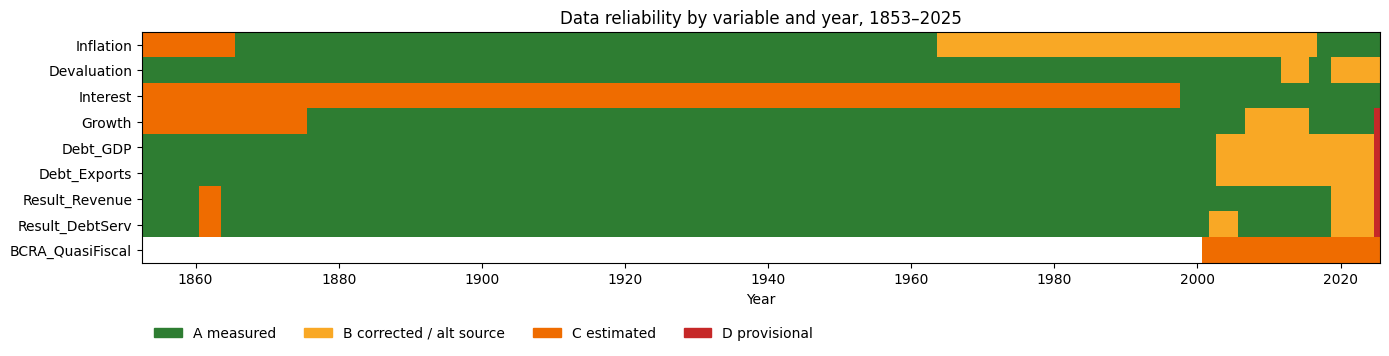

Data vintage — converted_fiscal_fpi-fiscal_1853-01_2025-12.csv: 2026-06-12; converted_exchange_dec-dec_1999-01_2025-12.csv: 2026-06-12


In [2]:
# Data-reliability map: which grade backs each variable in each year (legend in section 3.0).
#   A = measured / credible official source     B = alternative-source correction or concept seam
#   C = estimate / interpolation                D = provisional (pending official publication)
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.patches as mpatches

flags = pd.read_csv(QUALITY_FLAGS_PATH)
flag_variables = ["Inflation", "Devaluation", "Interest", "Growth", "Debt_GDP",
                  "Debt_Exports", "Result_Revenue", "Result_DebtServ", "BCRA_QuasiFiscal"]
grade_num = {"A": 0, "B": 1, "C": 2, "D": 3}
flag_years = np.arange(1853, REQUESTED_END_YEAR + 1)
grade_grid = np.full((len(flag_variables), len(flag_years)), np.nan)
for _, r in flags.iterrows():
    vi = flag_variables.index(r["Variable"])
    y0 = max(int(r["YearStart"]), 1853) - 1853
    y1 = min(int(r["YearEnd"]), REQUESTED_END_YEAR) - 1853
    grade_grid[vi, y0:y1 + 1] = grade_num[r["Grade"]]

grade_cmap = ListedColormap(["#2e7d32", "#f9a825", "#ef6c00", "#c62828"])
grade_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], grade_cmap.N)
fig, ax = plt.subplots(figsize=(14, 3.8))
ax.imshow(grade_grid, aspect="auto", cmap=grade_cmap, norm=grade_norm,
          extent=[flag_years[0] - 0.5, flag_years[-1] + 0.5, len(flag_variables) - 0.5, -0.5])
ax.set_yticks(range(len(flag_variables)))
ax.set_yticklabels(flag_variables)
ax.set_xlabel("Year")
ax.set_title("Data reliability by variable and year, 1853\u20132025")
ax.legend(handles=[mpatches.Patch(color=c, label=l) for c, l in zip(
              grade_cmap.colors,
              ["A measured", "B corrected / alt source", "C estimated", "D provisional"])],
          loc="upper left", bbox_to_anchor=(0.0, -0.22), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

# Data-vintage stamp: generation timestamps of the key generated inputs (.meta.json sidecars).
import json as _json
from pathlib import Path as _Path
_vintages = []
for _p in [FPI_DATA_PATH, DEC_DEC_MODERN_PATH, EXCHANGE_RATE_DATA_PATH, INTEREST_DATA_PATH]:
    _m = _Path(str(_p) + ".meta.json")
    if _m.exists():
        _vintages.append(f"{_Path(_p).name}: {_json.loads(_m.read_text()).get('generated_at', '?')[:10]}")
print("Data vintage — " + ("; ".join(_vintages) if _vintages else "no .meta.json sidecars found"))


*Figure 0. Data reliability map. Green years are measured by a credible official or primary source; yellow years carry a documented correction or an alternative source (e.g. the 2007–2015 alternative CPIs, the cepo free-market FX); orange years are estimates or interpolations (flat historical interest term averages, BCRA quasi-fiscal anchors); red years are provisional pending official publication (2025). Blank = variable not applicable. The grades live in `data/provided/data-quality-flags.csv` and are audited by `scripts/validate_cmpi_inputs.py`. The printed data-vintage stamp gives the generation date of each key generated input, from its `.meta.json` sidecar.*

### 3.1 Inflation (modern, 1964–2025)

As established for the modern period (see data/argentina/README.md). GDP deflator proxies CPI pre-2017;
genuine INDEC IPC from 2017; 2007–2015 INDEC manipulation corrected with alternative indices.

In [3]:
# Consumer-price inflation: genuine INDEC CPI where it exists (2017+), GDP-deflator proxy before.
arg_cpi_levels = indicator("FP.CPI.TOTL", "CPIPL")
arg_cpi_levels["CPI"] = arg_cpi_levels["CPIPL"].pct_change() * 100
arg_cpi = indicator("NY.GDP.DEFL.KD.ZG", "CPIFallback").join(
    arg_cpi_levels[["CPIPL", "CPI"]], how="outer"
)
arg_cpi["CPI"] = arg_cpi["CPI"].fillna(arg_cpi["CPIFallback"])

# Wholesale-price inflation (INDEC IPIM).
arg_wpi = indicator("FP.WPI.TOTL", "WPIPL")
arg_wpi["WPI"] = arg_wpi["WPIPL"].pct_change() * 100

# Blended inflation = NaN-robust mean of CPI and WPI (2001 has no IPIM, so it uses CPI alone).
arg_inflation = arg_cpi.join(arg_wpi["WPI"], how="outer")
arg_inflation["InflationAvg"] = arg_inflation[["CPI", "WPI"]].mean(axis=1)

# 2007-2015 INDEC-intervention correction.
alt_cpi = pd.read_csv(INFLATION_DATA_PATH).set_index("Year")
arg_inflation.loc[alt_cpi.index, "InflationAvg"] = alt_cpi["AltAvg"]

# Continuously-compounded inflation, as in the paper.
arg_inflation["InflationLog"] = np.log(1 + arg_inflation["InflationAvg"] / 100)

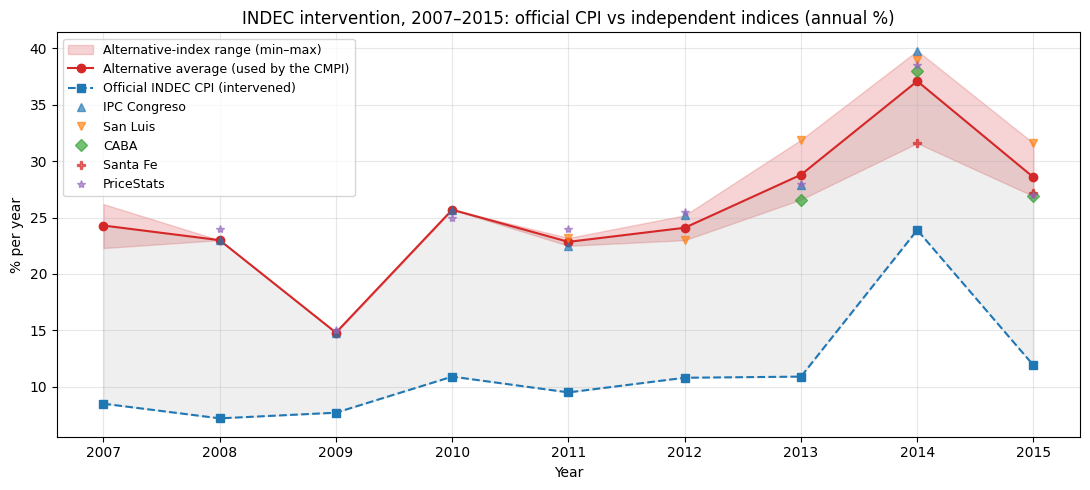

,Official,IPC_Congreso,San_Luis,CABA,Santa_Fe,PriceStats,AltAvg,AltMin,AltMax
Year,,,,,,,,,
2007,8.5,NaN,NaN,NaN,NaN,NaN,24.3,22.3,26.2
2008,7.2,23.0,NaN,NaN,NaN,24.0,23.0,23.0,23.0
2009,7.7,14.8,NaN,NaN,NaN,15.0,14.8,14.8,14.8
2010,10.9,25.7,NaN,NaN,NaN,25.0,25.7,25.7,25.7
2011,9.5,22.5,23.2,NaN,NaN,24.0,22.8,22.5,23.2
2012,10.8,25.2,23.0,NaN,NaN,25.5,24.1,23.0,25.2
2013,10.9,27.9,31.9,26.6,NaN,28.0,28.8,26.6,31.9
2014,23.9,39.8,39.0,38.0,31.6,38.5,37.1,31.6,39.8
2015,11.9,NaN,31.6,26.9,27.2,27.0,28.6,26.9,31.6


In [4]:
# The 2007-2015 INDEC-intervention correction at a glance: the official (manipulated) INDEC
# CPI vs the independent indices actually used, with the min-max range across sources.
alt_detail = pd.read_csv(INFLATION_DATA_PATH).set_index("Year")

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(alt_detail.index, alt_detail["AltMin"], alt_detail["AltMax"],
                alpha=0.20, color="tab:red", label="Alternative-index range (min\u2013max)")
ax.plot(alt_detail.index, alt_detail["AltAvg"], "o-", color="tab:red",
        label="Alternative average (used by the CMPI)")
ax.plot(alt_detail.index, alt_detail["Official"], "s--", color="tab:blue",
        label="Official INDEC CPI (intervened)")
for src, marker in [("IPC_Congreso", "^"), ("San_Luis", "v"), ("CABA", "D"), ("Santa_Fe", "P"),
                    ("PriceStats", "*")]:
    if alt_detail[src].notna().any():
        ax.plot(alt_detail.index, alt_detail[src], marker, ms=6, ls="none", alpha=0.65,
                label=src.replace("_", " "))
ax.fill_between(alt_detail.index, alt_detail["Official"], alt_detail["AltAvg"],
                color="gray", alpha=0.12)
ax.set_title("INDEC intervention, 2007\u20132015: official CPI vs independent indices (annual %)")
ax.set_ylabel("% per year")
ax.set_xlabel("Year")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

alt_detail[["Official", "IPC_Congreso", "San_Luis", "CABA", "Santa_Fe", "PriceStats",
            "AltAvg", "AltMin", "AltMax"]].round(1)

*Diagnostic. During the 2007–2015 INDEC intervention the official CPI understated inflation roughly threefold (the IMF censured Argentina in 2013; the Commerce Secretary who ran the intervention was criminally convicted — §3.0 row 1). The shaded gray area is the gap between the official series and the alternative average the CMPI uses; the red band is the spread across the independent indices (IPC Congreso, San Luis, CABA, Santa Fe; for 2007, the dismissed INDEC technicians' own 22.3–26.2% range, midpoint 24.3%). Without this correction the Kirchner-era CMPI scores would be artificially inflated. The PriceStats column (Cavallo & Rigobon 2016 online-price index, approximate annual averages) is an independent *methodological* corroboration — online prices rather than surveyed baskets — shown display-only: it does not enter the alternative average. Rank sensitivity to the band is in §9.*

**CPI-basket vintage caveat (2017–2025, especially 2024–25).** The post-reform national IPC
is credible but was still computed with **2004–05 expenditure weights** through December 2025
(INDEC announced the re-weighted index, based on the 2017–18 household survey, starting with the
January-2026 data). An outdated basket under-weights services — exactly the prices that led the
2024–25 relative-price normalization after the tariff freezes — so measured national inflation
slightly *understates* the 2024–25 price level adjustment. The signal is visible in the Buenos
Aires City index (newer weights, more services): **IPCBA 2024 ≈ 136.7% vs INDEC national 117.8%**.
This works *in favour of* the current administration's measured disinflation, so symmetry with the
2007–2015 correction requires flagging it: §9 includes a variant scoring 2024 inflation at the
CABA value. (§3.0 row 17.)

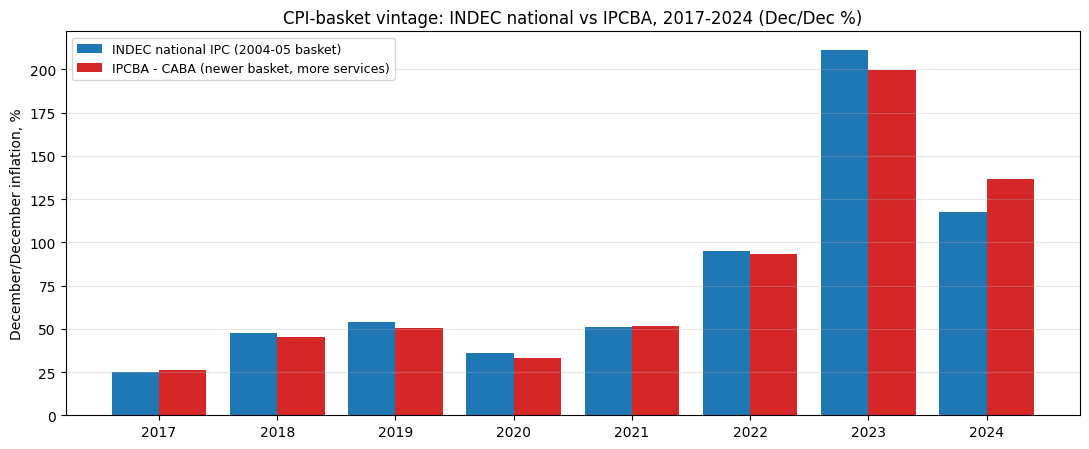

Year,2017,2018,2019,2020,2021,2022,2023,2024
INDEC_DecDec,24.8,47.6,53.8,36.1,50.9,94.8,211.4,117.8
IPCBA_DecDec,26.1,45.5,50.6,32.9,51.8,93.1,199.8,136.7


In [5]:
# The CPI-basket vintage gap at a glance: INDEC national IPC (2004-05 expenditure weights
# through Dec-2025) vs Buenos Aires City IPCBA (newer, services-heavier weights),
# December/December annual rates. Official-vs-alternative comparison for section 3.0 row 17.
ipcba = pd.read_csv("data/provided/ipcba-vs-indec.csv").set_index("Year")
fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(ipcba.index))
ax.bar(x - 0.2, ipcba["INDEC_DecDec"], 0.4, color="tab:blue",
       label="INDEC national IPC (2004-05 basket)")
ax.bar(x + 0.2, ipcba["IPCBA_DecDec"], 0.4, color="tab:red",
       label="IPCBA - CABA (newer basket, more services)")
ax.set_xticks(x)
ax.set_xticklabels(ipcba.index)
ax.set_ylabel("December/December inflation, %")
ax.set_title("CPI-basket vintage: INDEC national vs IPCBA, 2017-2024 (Dec/Dec %)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

ipcba[["INDEC_DecDec", "IPCBA_DecDec"]].T


*Diagnostic. The two indices track each other closely through 2023; in 2024 the services-led
relative-price normalization opened a ≈19 pp gap (IPCBA 136.7% vs INDEC national 117.8%) —
the under-weighting of services in the 2004–05 national basket (§3.0 row 17). This caveat
works in the current administration's favour and is flagged symmetrically with the
2007–2015 correction: the §9 CABA variant re-ranks the CMPI scoring 2024 inflation at the
IPCBA value. 2021–23 IPCBA values are rounded from DGEyC releases (flagged in
`ipcba-vs-indec.csv`); 2025 is omitted pending the January-2026 re-weighted national index.*


### 3.2 Devaluation (modern, 2000–2025) + December-quotation series (1853–1999)

Two adjustments shape the devaluation dimension:

**December-quotation series (1853–1999):** The paper measures devaluation from "average of
December quotations" (Ruíz 1990 for 1960–1989; DATAFIEL for 1990–1999). The WDI annual average
blends pre- and post-devaluation months when large devaluations occur mid-year, causing
wrong-sign inherited baselines. The unified series therefore uses the paper authors' own
devaluation log-diffs throughout 1853–1999: the Excel annual data govern 1853–1963 (§3.5–3.6)
and the same series overrides the WDI frame for 1960–1999 below. This supersedes the earlier
BCRA Dec–Dec override for 1990–1995.

**Cepo correction (2012–2015, 2019–2025):** follows the same free-market override documented for
the modern series (see data/argentina/README.md and the diagnostic table below).

In [6]:
arg_deval = indicator("PA.NUS.ATLS", "USDARS")
official_rate = arg_deval["USDARS"].copy()

# Cepo override: replace suppressed official rate with the free-market rate on control years.
# During 2012-2015 and 2019-2025 the official rate was administratively pinned while the economy
# transacted at the free-market rate. Scoring on the official rate penalises the administration
# that unifies the rates (a one-off catch-up); using CCL/blue avoids that distortion.
arg_parallel = pd.read_csv(EXCHANGE_RATE_DATA_PATH).set_index("Year")
arg_deval.loc[arg_parallel.index, "USDARS"] = arg_parallel["ParallelARS"]

arg_deval["Devaluation"] = arg_deval["USDARS"].pct_change() * 100
arg_deval["DevaluationLog"] = np.log(1 + arg_deval["Devaluation"] / 100)

# December-quotation devaluation override for 1960-1999 (Ruíz 1990 / DATAFIEL), from the paper
# authors' own series. Together with the Excel annual data that govern 1853-1963 in the unified
# series (§3.6), the devaluation dimension is December-quotation data continuously from 1853
# through 1999; WDI annual averages (with the cepo correction) are used only from 2000.
# Does NOT conflict with the cepo correction: cepo years are 2012-2015 and 2019-2025.
#
paper_deval = pd.read_csv(PAPER_DEVAL_PATH).set_index("Year")

wdi_deval_log = arg_deval["DevaluationLog"].copy()  # kept for comparison table below
for year in range(1960, 2000):
    if year in paper_deval.index:
        dlog = float(paper_deval.loc[year, "DevaluationLog"])
        arg_deval.loc[year, "DevaluationLog"] = dlog
        arg_deval.loc[year, "Devaluation"]    = (np.exp(dlog) - 1) * 100

# December-quotation override for 2000-2025, extending the paper's convention past 1999
# (scripts/generate_exchange_dec-dec-modern.py: December TCNPM from BCRA com3500 on free
# years, December CCL/blue average on cepo years, Convertibility 1:1 for 1999-2001). The
# annual-average series (with its cepo override) is kept as `annualavg_deval_log` for the
# section 3.2 comparison and the section 9 robustness variant.
annualavg_deval_log = arg_deval["DevaluationLog"].copy()
dec_dec_modern = pd.read_csv(DEC_DEC_MODERN_PATH).set_index("Year")
for year in range(2000, REQUESTED_END_YEAR + 1):
    if year in dec_dec_modern.index and pd.notna(dec_dec_modern.loc[year, "DevaluationLog"]):
        dlog = float(dec_dec_modern.loc[year, "DevaluationLog"])
        arg_deval.loc[year, "DevaluationLog"] = dlog
        arg_deval.loc[year, "Devaluation"]    = (np.exp(dlog) - 1) * 100

In [7]:
# December-quotation correction impact: WDI annual average vs the paper's December-quotation
# series, for the four administrations most affected by mid-year devaluations. Term boundaries
# and inherited years follow the paper (Tables 3.1-3.2), so the "Paper" column is directly
# comparable with the published Table 3.2 innovations — and, since the unified series uses the
# December-quotation data throughout 1853-1999, it is also exactly what the CMPI scores.
correction_cases = {
    "Illia (1964-66, inherited 1963)":     (1963, [1964, 1965, 1966]),
    "Ongania (1967-69, inherited 1966)":   (1966, [1967, 1968, 1969]),
    "Peron III (1973-75, inherited 1972)": (1972, [1973, 1974, 1975]),
    "Videla/... (1976-83, inh. 1975)":     (1975, list(range(1976, 1984))),
}
rows = []
for label, (inh_year, term_years) in correction_cases.items():
    inh_wdi   = wdi_deval_log.get(inh_year, float("nan"))
    inh_paper = float(paper_deval.loc[inh_year, "DevaluationLog"]) if inh_year in paper_deval.index else inh_wdi
    yr_wdi    = sum(wdi_deval_log.get(y, 0) for y in term_years) / len(term_years)
    yr_paper  = arg_deval["DevaluationLog"].loc[term_years].mean()
    rows.append({
        "Term (inherited year)":    label,
        "Inh. WDI":   f"{inh_wdi:.3f}",
        "Inh. Paper": f"{inh_paper:.3f}",
        "Avg innov WDI %":   f"{(yr_wdi  - inh_wdi)  * 100:+.1f}",
        "Avg innov Paper %": f"{(yr_paper - inh_paper) * 100:+.1f}",
        "Paper Table 3.2": {
            "Illia (1964-66, inherited 1963)":     "+27.1",
            "Ongania (1967-69, inherited 1966)":   "-9.0",
            "Peron III (1973-75, inherited 1972)": "+60.4",
            "Videla/... (1976-83, inh. 1975)":     "−81.4",
        }.get(label, "—"),
    })
comparison_deval = pd.DataFrame(rows).set_index("Term (inherited year)")
comparison_deval

,Inh. WDI,Inh. Paper,Avg innov WDI %,Avg innov Paper %,Paper Table 3.2
Term (inherited year),,,,,
"Illia (1964-66, inherited 1963)",0.177,-0.046,-3.9,+27.1,+27.1
"Ongania (1967-69, inherited 1966)",0.211,0.182,-4.1,-9.0,-9.0
"Peron III (1973-75, inherited 1972)",0.470,0.193,+4.0,+60.4,+60.4
"Videla/... (1976-83, inh. 1975)",1.414,1.759,-41.9,-81.3,−81.4


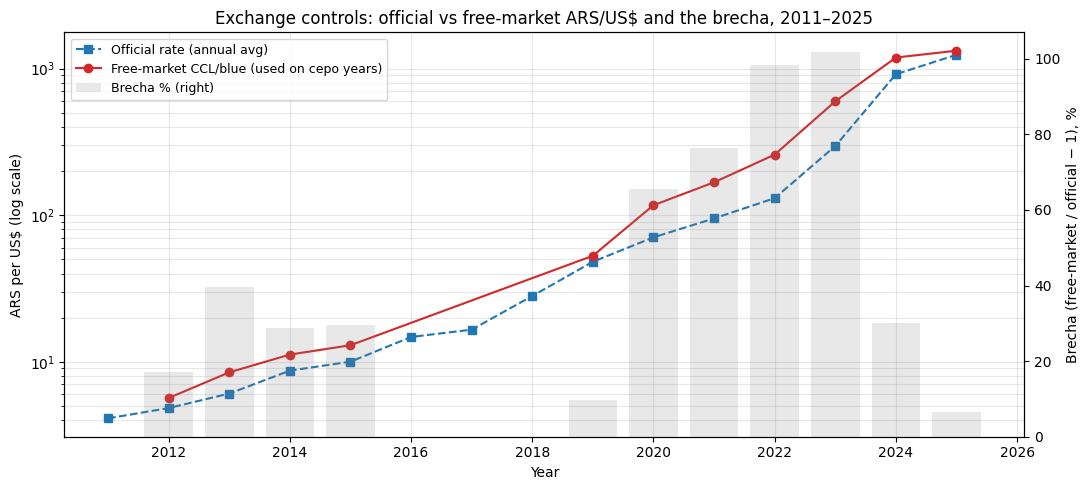

,Official ARS/US$,Free-market ARS/US$,Rate used,Brecha %
Year,,,,
2012,4.8,5.7,blue,17.2
2013,6.1,8.5,CCL,39.6
2014,8.7,11.2,CCL,28.7
2015,10.0,13.0,CCL,29.5
2019,48.1,52.9,CCL,9.8
2020,70.6,117.0,CCL,65.7
2021,95.1,167.7,CCL,76.4
2022,130.7,259.2,CCL,98.3
2023,296.5,598.6,CCL,101.9


In [8]:
# The cepo gap we correct for: official vs free-market ARS/US$ on the override years.
cepo = pd.DataFrame({
    "Official ARS/US$":    official_rate.loc[arg_parallel.index],
    "Free-market ARS/US$": arg_parallel["ParallelARS"],
    "Rate used":           arg_parallel["Rate"],
})
cepo["Brecha %"] = (cepo["Free-market ARS/US$"] / cepo["Official ARS/US$"] - 1) * 100

fig, ax = plt.subplots(figsize=(11, 5))
yrs = official_rate.loc[2011:].index
ax.plot(yrs, official_rate.loc[2011:], "s--", color="tab:blue",
        label="Official rate (annual avg)")
ax.plot(cepo.index, cepo["Free-market ARS/US$"], "o-", color="tab:red",
        label="Free-market CCL/blue (used on cepo years)")
ax.set_yscale("log")
ax.set_ylabel("ARS per US$ (log scale)")
ax.set_xlabel("Year")
ax2 = ax.twinx()
ax2.bar(cepo.index, cepo["Brecha %"], alpha=0.18, color="gray", label="Brecha % (right)")
ax2.set_ylabel("Brecha (free-market / official \u2212 1), %")
ax.set_title("Exchange controls: official vs free-market ARS/US$ and the brecha, 2011\u20132025")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

cepo.round(1)

*Diagnostic. On the exchange-control ("cepo") years the official rate was administratively pinned while the economy transacted at the free-market (CCL/blue) rate — a gap (*brecha*) reaching ~+100% in 2022–23. Scoring devaluation on the official rate would penalise the administration that later unifies the rates, so the notebook substitutes the free-market rate. This same free-market rate also drives the FPI cepo correction in §6.0.*

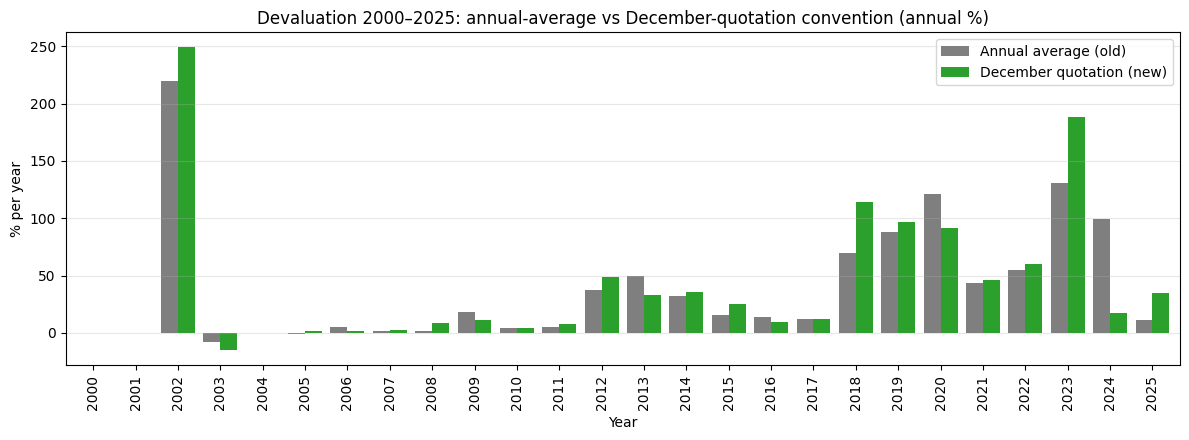

Year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Annual average (old),0.0,0.0,219.9,-7.9,-0.0,-0.5,5.0,1.3,1.9,17.9,...,13.8,12.2,69.6,88.2,121.3,43.4,54.5,131.0,99.0,11.3
December quotation (new),0.0,0.0,249.0,-15.2,0.3,1.5,1.5,2.6,9.0,11.2,...,9.3,11.8,114.0,96.6,91.3,46.2,60.5,188.1,17.2,34.8


In [9]:
# Annual-average vs December-quotation devaluation, 2000-2025. The December convention
# (the paper's) books each devaluation into the year it happened; annual averages smear it
# into the following year (e.g. the Jan-2002 collapse leaked a spurious +84% into Duhalde's
# 2003, which was actually an appreciation year under the Lavagna stabilization).
deval_cmp = pd.DataFrame({
    "Annual average (old)": (np.exp(annualavg_deval_log.loc[2000:REQUESTED_END_YEAR]) - 1) * 100,
    "December quotation (new)": (np.exp(arg_deval.loc[2000:REQUESTED_END_YEAR, "DevaluationLog"]) - 1) * 100,
}).dropna()

fig, ax = plt.subplots(figsize=(12, 4.5))
deval_cmp.plot.bar(ax=ax, color=["tab:gray", "tab:green"], width=0.8)
ax.set_title("Devaluation 2000\u20132025: annual-average vs December-quotation convention (annual %)")
ax.set_ylabel("% per year")
ax.set_xlabel("Year")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

deval_cmp.round(1).T

*Diagnostic. From this revision the 2000–2025 devaluation uses December quotations (BCRA TCNPM on free years; December CCL/blue on cepo years), the same convention the paper uses for 1853–1999 — making the whole 173-year devaluation dimension methodologically uniform. The fix matters where regime changes fell mid-year: the 2002 collapse now lands fully in 2002 and 2003 correctly shows the Lavagna-era appreciation; the Dec-2015 and Dec-2023 exchange-rate unifications are measured against the free-market rate, so they no longer appear as giant devaluations by the incoming administration. The old annual-average variant is kept in §9.*

### 3.3 Interest rate (modern, 1958–2025)

Stitched annual series: paper term averages through 1999, EMBIG riesgo país from 2000.
Covers 1958–2025; historical interest for 1852–1957 comes from the historical CSV (§3.5).

In [10]:
arg_interest = pd.read_csv(INTEREST_DATA_PATH)
arg_interest = arg_interest[arg_interest["CountryName"] == COUNTRY_NAME].copy()
arg_interest["Year"] = pd.to_numeric(arg_interest["Year"], errors="coerce").astype(int)
arg_interest["Interest"] = pd.to_numeric(arg_interest["Interest"], errors="coerce")
arg_interest = arg_interest[["Year", "Interest"]].set_index("Year")

In [11]:
# Interest rate at the 1997/1998 transition: the paper's flat term average (9.75%) gives way to
# the actual annual EMBIG country-risk spread (BCRP), continuous with the 2000+ legacy values.
arg_interest.loc[1996:2001, "Interest"].rename("Interest %").to_frame().round(2)


,Interest %
Year,
1996,9.75
1997,9.75
1998,5.98
1999,7.20
2000,6.68
2001,15.57


*Diagnostic. From 1998 the interest dimension switches from the paper's flat per-term real-rate averages to the actual EMBIG Argentina country-risk spread (BCRP). The 1998–1999 values (≈6.0%, ≈7.2%) replace the previous flat Menem-II term average of 9.75% and join continuously with the 2000+ series (e.g. 2002 ≈ 58%).*

### 3.4 Per-capita growth (modern, 1964–2025)

In [12]:
arg_growth = indicator("NY.GDP.PCAP.KD.ZG", "Growth")

DATA_END_YEAR = min(
    REQUESTED_END_YEAR,
    int(arg_inflation["InflationLog"].dropna().index.max()),
    int(arg_deval["DevaluationLog"].dropna().index.max()),
    int(arg_interest.index.max()),
    int(arg_growth.index.max()),
)
print(f"Latest complete CMPI year available: {DATA_END_YEAR}")

Latest complete CMPI year available: 2025


In [13]:
# 2025 per-capita growth uses an INDEC bridge for years the World Bank API has not yet published.
# Source: INDEC "Informe de avance del nivel de actividad", 4o trimestre de 2025 (publ. 2026-03-20):
# real PIB +4.4% -> per-capita +4.21% via INDEC 2022-census mid-year population.
if 2025 in arg_growth.index and pd.notna(arg_growth.loc[2025, "Growth"]):
    print(f"2025 per-capita growth (INDEC bridge): {arg_growth.loc[2025, 'Growth']:.2f}%")


2025 per-capita growth (INDEC bridge): 4.21%


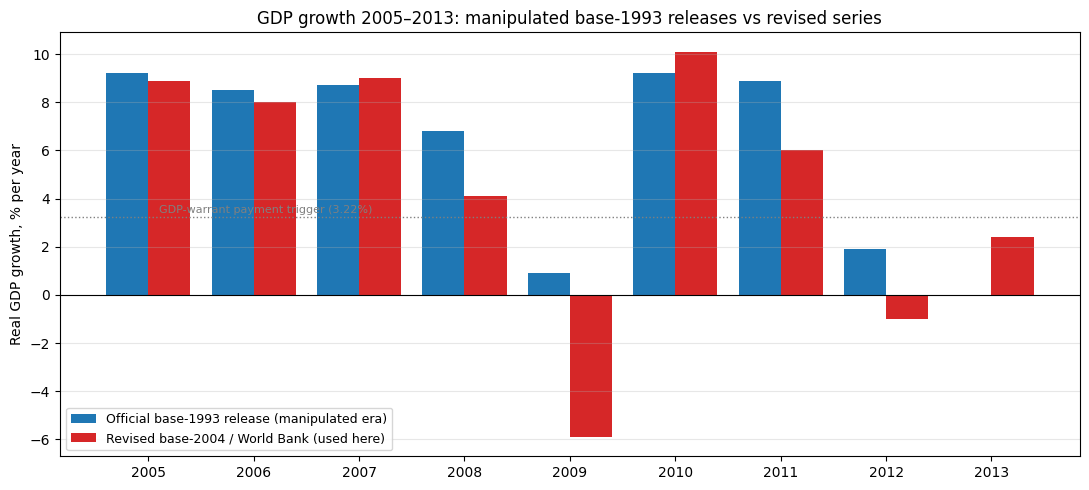

,OfficialGrowth_1993base,RevisedGrowth
Year,,
2005,9.2,8.9
2006,8.5,8.0
2007,8.7,9.0
2008,6.8,4.1
2009,0.9,-5.9
2010,9.2,10.1
2011,8.9,6.0
2012,1.9,-1.0
2013,NaN,2.4


In [14]:
# The Kirchner-era GDP overstatement this notebook avoids: old INDEC base-1993 releases vs
# the revised (2016-revision / World Bank) series the notebook actually uses (§3.0 row 2).
gdp_rev = pd.read_csv(GDP_REVISION_PATH).set_index("Year")

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(gdp_rev.index))
ax.bar(x - 0.2, gdp_rev["OfficialGrowth_1993base"], 0.4, color="tab:blue",
       label="Official base-1993 release (manipulated era)")
ax.bar(x + 0.2, gdp_rev["RevisedGrowth"], 0.4, color="tab:red",
       label="Revised base-2004 / World Bank (used here)")
ax.set_xticks(x)
ax.set_xticklabels(gdp_rev.index)
ax.axhline(0, color="k", lw=0.8)
ax.axhline(3.22, color="gray", ls=":", lw=1)
ax.annotate("GDP-warrant payment trigger (3.22%)", (0.1, 3.4), fontsize=8, color="gray")
ax.set_ylabel("Real GDP growth, % per year")
ax.set_title("GDP growth 2005\u20132013: manipulated base-1993 releases vs revised series")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

gdp_rev[["OfficialGrowth_1993base", "RevisedGrowth"]]

*Diagnostic. The growth series used by this notebook (World Bank, which embeds INDEC's 2016 revision) already excludes the base-1993 volume manipulation: 2008–2012 official releases overstated growth by up to 6.8 pp in a single year (2009: +0.9% official vs −5.9% revised), keeping the GDP-warrant (cupón PBI) trigger satisfied — while the early-2014 rebasing put 2013 just *below* the trigger, avoiding a ~USD 3bn payment (§3.0 rows 2–3; Coremberg 2017). No growth override is needed for 2007–2015 precisely because the revised series is used; this chart documents what was avoided.*

### 3.5 Historical data (1852–1963)

Two sources cover the pre-WDI era:

1. **`historical-cmpi-1853-1963.csv`** (local): used only for (a) the **1852 baseline row**
   (derived from Table 3.2 of the paper as `baseline = actual_1853 − innovation_1853`; the
   inflation and devaluation baselines are continuously-compounded rates in percent — the
   convention of Tables 3.1/3.2, paper fn. 13 — and enter directly as log-rates) and
   (b) **interest rates for 1852–1957** (the Excel file has no annual interest data).

2. **`data_a_2018.xlsx`** (paper authors' dataset): actual **annual** observations for
   1853–2018 — inflation (log-diff, col D), devaluation (log-diff, col E), and GDP per-capita
   growth (fraction, col F). Each historical year 1853–1963 carries its own observed value,
   exactly as in the paper.

**Proxy caveats (graded C in Figure 0).** Two limitations of the paper's own sources
(Appendix B) deserve flags rather than silence: **pre-1866 "inflation" *is* the
devaluation series** ("1853–65: annual devaluation rates"), so for those years two of the
four CMPI components are the same gold-premium series — double-weighting the exchange rate
for exactly the administrations at the top of the early rankings (Obligado, Alsina); and
**1853–75 "growth" is a trade-flow proxy** (exports + imports in gold pesos, assuming a
constant trade/GDP ratio). The §9 no-inflation variant bounds the double-weighting; both
windows are graded C in `data-quality-flags.csv`.


In [15]:
# hist_cmpi: used for (1) 1852 baseline row (all variables) and (2) interest 1852-1957.
hist_cmpi = pd.read_csv(HIST_CMPI_PATH).set_index("Year")
print(f"hist_cmpi: {hist_cmpi.index.min()}–{hist_cmpi.index.max()}, {len(hist_cmpi)} rows")

hist_cmpi: 1852–1963, 112 rows


In [16]:
# Pre-WDI annual inflation/devaluation/growth from provided data_a_2018.xlsx
# (via generate_historical_data-a-2018-excel.py → processed CSV).
excel_hist = pd.read_csv(HIST_EXCEL_ANNUAL_PATH).set_index("Year")
print(f"excel_hist: {excel_hist.index.min()}–{excel_hist.index.max()}, "
      f"{len(excel_hist)} rows, NaN count: {excel_hist.isna().sum().sum()}")
excel_hist.head(3)

excel_hist: 1853–1963, 111 rows, NaN count: 0


,InflationLog,DevaluationLog,Growth
Year,,,
1853,0.141093,0.141093,-0.175298
1854,0.018676,0.018676,0.199529
1855,0.055589,0.055589,-0.062221


### 3.6 Build unified series (1852–2025)

Four splice functions join historical and modern data into single `pd.Series`:

| Variable | 1852 | 1853–1963 | 1964–2025 |
|---|---|---|---|
| Inflation | hist_cmpi CSV baseline | **Excel annual log-diff** | WDI/INDEC |
| Devaluation | hist_cmpi CSV baseline | **Excel annual log-diff** (December quotations) | paper December series to 1999; WDI + cepo from 2000 |
| Growth | hist_cmpi CSV baseline | **Excel annual fraction** | WDI (2025 = INDEC bridge) |
| Interest | hist_cmpi CSV | hist_cmpi CSV (term avgs, to 1957) | wb-ids-arg 1958–97; EMBIG 1998+ |

The `_splice()` priority rule: the historical (paper-authors') value wins wherever it exists —
through 1963 — and the modern series fills 1964 onwards, so each year has a single,
well-defined data regime. Interest has its own seam at 1957/58 because no annual historical
interest series exists (term averages before, wb-ids/EMBIG after).

In [17]:
def _splice(hist_part: pd.Series, modern_part: pd.Series) -> pd.Series:
    """Splice historical and modern series.

    Priority rule: the historical (paper-authors') value is used wherever it exists
    (non-NaN) — i.e. through 1963 — and the modern series fills all later years.
    Each year therefore has a single, well-defined data regime: the same annual
    sources the paper used for 1853-1963, WDI/INDEC from 1964.
    """
    result = modern_part.copy()
    result = result.reindex(result.index.union(hist_part.index))
    hist_valid = hist_part.dropna()
    result[hist_valid.index] = hist_valid
    return result.sort_index()


def build_unified_inflation() -> pd.Series:
    """1852 baseline from hist_cmpi; 1853-1963 from Excel annual log-diff; 1964+ from WDI/INDEC."""
    # Tables 3.1/3.2 print continuously-compounded rates in percent (paper fn. 13), so the
    # 1852 baseline is already a log-rate: divide by 100, do not re-apply log(1 + x).
    baseline_1852 = pd.Series({1852: hist_cmpi.loc[1852, "Inflation"] / 100})
    hist_annual   = excel_hist["InflationLog"]              # already ln(P_t/P_{t-1})
    hist = pd.concat([baseline_1852, hist_annual])
    return _splice(hist, arg_inflation["InflationLog"])


def build_unified_devaluation() -> pd.Series:
    """1852 baseline from hist_cmpi; 1853-1963 from Excel annual log-diff; 1964+ paper/WDI/cepo."""
    baseline_1852 = pd.Series({1852: hist_cmpi.loc[1852, "Devaluation"] / 100})  # log-rate, as above
    hist_annual   = excel_hist["DevaluationLog"]            # already log-diff
    hist = pd.concat([baseline_1852, hist_annual])
    return _splice(hist, arg_deval["DevaluationLog"])


def build_unified_interest() -> pd.Series:
    """1852-1957 from hist_cmpi term averages (no interest in Excel); 1958+ from wb-ids-arg."""
    hist   = hist_cmpi["Interest"] / 100
    hist.name = "Interest_frac"
    modern = arg_interest["Interest"] / 100
    return pd.concat([hist[hist.index < arg_interest.index.min()], modern]).sort_index()


def build_unified_growth() -> pd.Series:
    """1852 baseline from hist_cmpi; 1853-1963 from Excel annual fraction; 1964+ from WDI."""
    baseline_1852 = pd.Series({1852: hist_cmpi.loc[1852, "Growth"] / 100})  # simple rate
    hist_annual   = excel_hist["Growth"]                    # already a fraction
    hist = pd.concat([baseline_1852, hist_annual])
    return _splice(hist, arg_growth["Growth"] / 100)


unified_inflation   = build_unified_inflation()
unified_devaluation = build_unified_devaluation()
unified_interest    = build_unified_interest()
unified_growth      = build_unified_growth()

print(f"Unified inflation:   {unified_inflation.index.min()}–{unified_inflation.dropna().index.max()}")
print(f"Unified devaluation: {unified_devaluation.index.min()}–{unified_devaluation.dropna().index.max()}")
print(f"Unified interest:    {unified_interest.index.min()}–{unified_interest.dropna().index.max()}")
print(f"Unified growth:      {unified_growth.index.min()}–{unified_growth.dropna().index.max()}")

Unified inflation:   1852–2025
Unified devaluation: 1852–2025
Unified interest:    1852–2025
Unified growth:      1852–2025


In [18]:
# Splice-seam check: the paper authors' annual data govern 1853-1963; modern sources from 1964.
assert unified_inflation[1963] == excel_hist.loc[1963, "InflationLog"], \
    "Splice error: 1963 inflation should come from the Excel annual data"
assert unified_inflation[MODERN_START_YEAR] == arg_inflation["InflationLog"][MODERN_START_YEAR], \
    "Splice error: 1964 inflation should come from the modern series"
assert unified_devaluation[1963] == excel_hist.loc[1963, "DevaluationLog"], \
    "Splice error: 1963 devaluation should come from the Excel annual data"
assert unified_devaluation[1964] == float(paper_deval.loc[1964, "DevaluationLog"]), \
    "Splice error: 1964 devaluation should come from the December-quotation series"
assert unified_growth[1963] == excel_hist.loc[1963, "Growth"], \
    "Splice error: 1963 growth should come from the Excel annual data"
assert unified_growth[MODERN_START_YEAR] == arg_growth["Growth"][MODERN_START_YEAR] / 100, \
    "Splice error: 1964 growth should come from the modern series"
print("Splice seams verified ✓ — historical data through 1963, modern from 1964; "
      "December-quotation devaluation continuous 1853-1999")

Splice seams verified ✓ — historical data through 1963, modern from 1964; December-quotation devaluation continuous 1853-1999


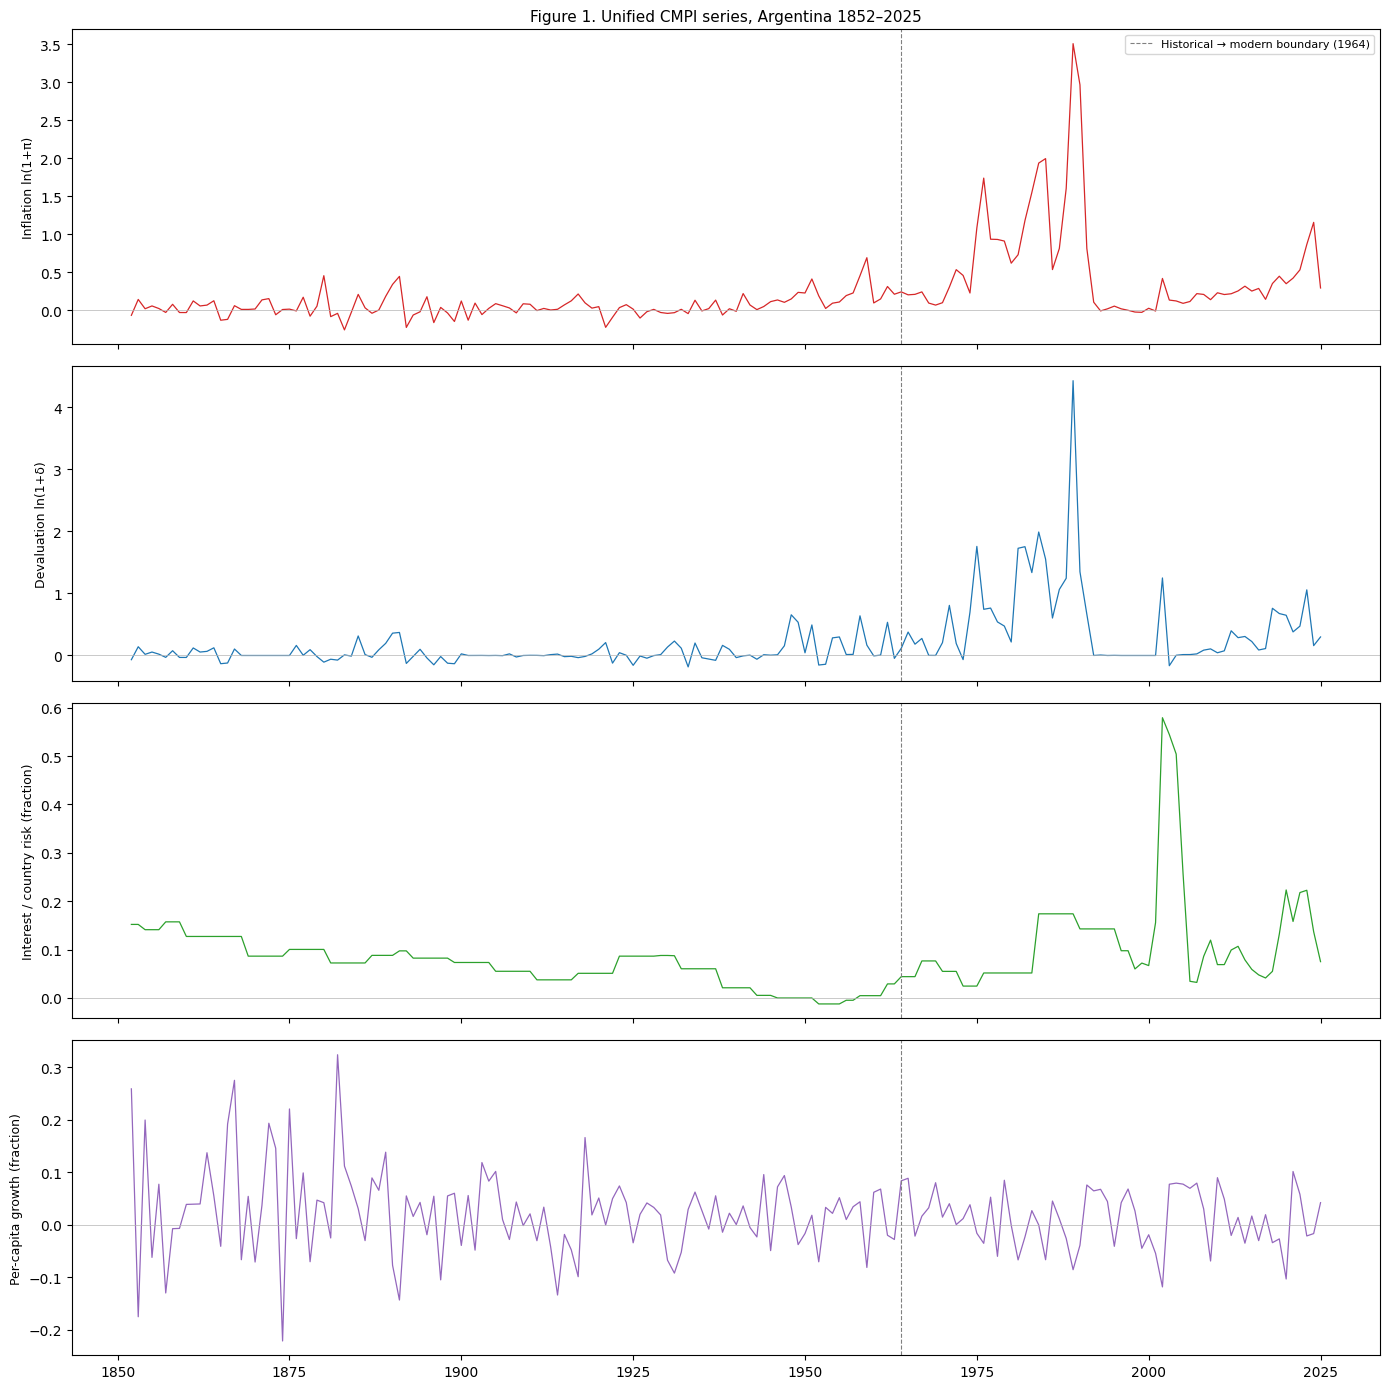

In [19]:
# Overview plot: the four unified series from 1852 to 2025.
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
series_specs = [
    (unified_inflation,   "Inflation ln(1+π)",   "C3"),
    (unified_devaluation, "Devaluation ln(1+δ)", "C0"),
    (unified_interest,    "Interest / country risk (fraction)", "C2"),
    (unified_growth,      "Per-capita growth (fraction)",       "C4"),
]
for ax, (series, label, color) in zip(axes, series_specs):
    ax.plot(series.dropna(), color=color, lw=0.9)
    ax.set_ylabel(label, fontsize=9)
    ax.axvline(MODERN_START_YEAR, color="0.5", lw=0.8, ls="--", label="Historical → modern boundary (1964)")
    ax.axhline(0, color="0.7", lw=0.5)
axes[0].legend(fontsize=8)
axes[0].set_title("Figure 1. Unified CMPI series, Argentina 1852–2025", fontsize=11)
plt.tight_layout()

*Figure 1. Dashed vertical line at 1964 marks the boundary between the paper authors' annual
data (1852–1963, left) and the modern WDI/INDEC series (right). The interest series (green)
shows flat within-term steps through 1957 because the Excel file contains no interest data and
Table 3.1 term averages are used for 1852–1957.*

## 4. Administration terms (41 total, 1853–2025)

### 4.0 Administration boundaries (note on attribution)

The 41 terms follow the paper's intervals exactly where the two studies overlap (Tables 3.1–3.4,
33 terms, 1853–1999), including the paper's rule of assigning each year to whoever ruled the
larger part of it — hence Onganía 1967–69, Levingston/Lanusse 1970–72, and Perón III 1973–75
(the Peronist presidencies resumed on 25 May 1973). Conventions carried over from the paper:

- Single-year or very short caretaker/interim terms are kept separate when conventionally
  distinguished (Alsina 1853, Uriburu JF 1931, Guido 1962–63).
- Military juntas are presented as one long term ("Videla/Viola/Galtieri/Bignone" 1976–83).
- Civilian transition periods with rapid turnover are combined ("Ortiz/Castillo",
  "Ramírez/Farrell", "Levingston/Lanusse").

For 2000–2025 (beyond the paper's span):

- 2001–03 is split as De la Rúa (to 2001) / Duhalde (2002–03) to separate the crisis trough from
  the stabilization. This is the single deliberate exception to the majority-of-year rule:
  Néstor Kirchner took office on 25 May 2003 and ruled the larger part of 2003, but assigning
  2003 to Duhalde keeps the post-default stabilization (the Lavagna program) in one piece.
- Milei (2024–DATA_END_YEAR) is partial by construction; see the year-by-year decomposition
  in §8.4.

An offline sensitivity experiment (merging the shortest one-year terms into their neighbours)
moved only bottom CMPI ranks and left the top-10 and all FPI/Overall top-5 unchanged; it is not
reproduced in this notebook. Fuller merge/split experiments are future work.

In [20]:
presidency_terms = [
    # ---- HISTORICAL TERMS (1853–1963) ---- data_a_2018.xlsx (annual) + Table 3.1 (interest)
    # (name, first_year, last_year, president_photo_url, economy_minister: "Name|url" or "Name" or legacy url)
# Boundaries follow the paper's Tables 3.1-3.4 (years assigned by the majority-of-year rule);
# the single deliberate exception is 2002-03 = Duhalde — see the note in §4.0.
    # Names from Wikipedia "List of ministers of Economy of Argentina". Photos: PD Commons (Vélez, Alsogaray, Krieger);
    # most historical are name-only (text box). Modern names prepended to existing photo URLs. | for multi-minister.
    ("Alsina", 1853, 1853, "https://upload.wikimedia.org/wikipedia/commons/a/a1/Valentin_alsina_retrato.jpg", "Valentín Alsina"),
    ("Obligado", 1854, 1856, "https://upload.wikimedia.org/wikipedia/commons/3/36/Pastor_Obligado.jpg", "Valentín Alsina"),
    ("Alsina II", 1857, 1859, "https://upload.wikimedia.org/wikipedia/commons/a/a1/Valentin_alsina_retrato.jpg", "Valentín Alsina"),
    ("Mitre", 1860, 1868, "https://upload.wikimedia.org/wikipedia/commons/1/1c/Bartolom%C3%A9_Mitre_01.jpg", "Dalmacio Vélez Sarsfield|https://upload.wikimedia.org/wikipedia/commons/6/60/Dr._Dalmacio_V%C3%A9lez_Sarsfield.jpg"),
    ("Sarmiento", 1869, 1874, "https://upload.wikimedia.org/wikipedia/commons/9/9d/Sarmiento.jpg", "José Benjamín Gorostiaga"),
    ("Avellaneda", 1875, 1880, "https://upload.wikimedia.org/wikipedia/commons/c/cc/Nicol%C3%A1s_Avellaneda_-_1910.JPG", "Vicente Fidel López"),
    ("Roca", 1881, 1886, "https://upload.wikimedia.org/wikipedia/commons/f/f7/RetratoROcaMuseo.jpg", "Juan José Romero"),
    ("Juárez Celman", 1887, 1890, "https://upload.wikimedia.org/wikipedia/commons/0/0e/Juarez_celman_president.jpg", "Wenceslao Pacheco"),
    ("Pellegrini", 1891, 1892, "https://upload.wikimedia.org/wikipedia/commons/a/ab/Retrato_de_Carlos_Pellegrini.jpg", "Vicente Fidel López"),
    ("Sáenz Peña L./Uriburu JE", 1893, 1898, "https://upload.wikimedia.org/wikipedia/commons/8/8f/Luis_Saenz_Pena.jpg", "José María Rosa"),
    ("Roca II", 1899, 1904, "https://upload.wikimedia.org/wikipedia/commons/f/f7/RetratoROcaMuseo.jpg", "Enrique Berisso"),
    ("Quintana/Figueroa", 1905, 1910, "https://upload.wikimedia.org/wikipedia/commons/b/b6/Manuel_Quintana_presidente.png", "Norberto Piñero"),
    ("Sáenz Peña R./de la Plaza", 1911, 1916, "https://upload.wikimedia.org/wikipedia/commons/6/6c/Roque_Saenz_Pena.jpg", "Enrique del Valle Iberlucea"),
    ("Yrigoyen", 1917, 1922, "https://upload.wikimedia.org/wikipedia/commons/3/30/Hipolito_Yrigoyen_-_NAC.jpg", "Domingo Salaberry"),
    ("De Alvear", 1923, 1928, "https://upload.wikimedia.org/wikipedia/commons/7/7f/Marcelo_T._de_Alvear%2C_ca._1915.jpg", "Rafael Herrera Vegas"),
    ("Yrigoyen II", 1929, 1930, "https://upload.wikimedia.org/wikipedia/commons/3/30/Hipolito_Yrigoyen_-_NAC.jpg", "Enrique Pérez Colman"),
    ("Uriburu JF", 1931, 1931, "https://upload.wikimedia.org/wikipedia/commons/0/08/Jose_Uriburu.png", "Enrique Pérez Colman"),
    ("Justo", 1932, 1937, "https://upload.wikimedia.org/wikipedia/commons/1/1a/Presidente_Agust%C3%ADn_Pedro_Justo.png", "Federico Pinedo"),
    ("Ortiz/Castillo", 1938, 1942, "https://upload.wikimedia.org/wikipedia/commons/3/36/Roberto_Ortiz_President.jpg", "Federico Pinedo"),
    ("Ramírez/Farrell", 1943, 1945, "https://upload.wikimedia.org/wikipedia/commons/1/1d/Pedro-p-ramirez.jpg", "Jorge Santamarina"),
    ("Perón I", 1946, 1951, "https://upload.wikimedia.org/wikipedia/commons/b/bc/Juan_Domingo_Per%C3%B3n_1973.jpg", "Ramón Cereijo"),
    ("Perón II", 1952, 1955, "https://upload.wikimedia.org/wikipedia/commons/b/bc/Juan_Domingo_Per%C3%B3n_1973.jpg", "Ramón Cereijo"),
    ("Aramburu", 1956, 1957, "https://upload.wikimedia.org/wikipedia/commons/e/e4/Pedro_Eugenio_Aramburu.jpg", "Adalbert Krieger Vasena|https://upload.wikimedia.org/wikipedia/commons/e/ee/Adalbert_Krieger_Vasena.jpg"),
    ("Frondizi", 1958, 1961, "https://upload.wikimedia.org/wikipedia/commons/1/1d/Arturo_Frondizi.jpg", "Álvaro Alsogaray|https://upload.wikimedia.org/wikipedia/commons/e/e4/%C3%81lvaro_Alsogaray_d%C3%A9cada_de_1960.png"),
    ("Guido", 1962, 1963, "https://upload.wikimedia.org/wikipedia/commons/9/9c/Jos%C3%A9_Mar%C3%ADa_Guido_3_%28cropped%29_2.jpg", "Álvaro Alsogaray|https://upload.wikimedia.org/wikipedia/commons/e/e4/%C3%81lvaro_Alsogaray_d%C3%A9cada_de_1960.png"),
    ("Illia", 1964, 1966, "https://upload.wikimedia.org/wikipedia/commons/2/2b/Illia_banda_presidencial.jpg", "Juan Carlos Pugliese|https://cdi.mecon.gob.ar/img/pugliese.jpg"),
    ("Ongania", 1967, 1969, "https://upload.wikimedia.org/wikipedia/commons/0/00/Juan_Carlos_Ongan%C3%ADa.JPG", "Adalbert Krieger Vasena|https://cdi.mecon.gob.ar/img/krieguer.jpg"),
    ("Levingston/Lanusse", 1970, 1972, "https://upload.wikimedia.org/wikipedia/commons/7/7e/Alejandro_Agust%C3%ADn_Lanusse.jpg", "Jorge Wehbe|https://cdi.mecon.gob.ar/img/Wehbe.jpg"),
    ("Peron III", 1973, 1975, "https://upload.wikimedia.org/wikipedia/commons/b/bc/Juan_Domingo_Per%C3%B3n_1973.jpg", "José Ber Gelbard|Celestino Rodrigo|https://cdi.mecon.gob.ar/img/rodrigo.jpg"),
    ("Videla/Viola/Galtieri/Bignone", 1976, 1983, "https://upload.wikimedia.org/wikipedia/commons/e/e5/Retrato_Oficial_Jorge_Rafael_Videla_1976.jpg", "José Alfredo Martínez de Hoz|https://cdi.mecon.gob.ar/img/martinez.jpg"),
    ("Alfonsin", 1984, 1989, "https://upload.wikimedia.org/wikipedia/commons/e/e4/Ra%C3%BAl_Alfons%C3%ADn_con_banda_presidencial.jpg", "Juan Sourrouille|https://cdi.mecon.gob.ar/img/sorrou.jpg"),
    ("Menem", 1990, 1995, "https://upload.wikimedia.org/wikipedia/commons/1/14/Menem_con_banda_presidencial.jpg", "Domingo Cavallo|https://cdi.mecon.gob.ar/img/cavallo.jpg"),
    ("Menem II", 1996, 1999, "https://upload.wikimedia.org/wikipedia/commons/1/14/Menem_con_banda_presidencial.jpg", "Roque Fernández|https://cdi.mecon.gob.ar/img/rfernadez.jpg"),
    ("De la Rua", 2000, 2001, "https://upload.wikimedia.org/wikipedia/commons/b/b5/Fernando_de_la_R%C3%BAa_con_bast%C3%B3n_y_banda_de_presidente.jpg", "José Luis Machinea|https://cdi.mecon.gob.ar/img/machinea.jpg"),
    ("Duhalde", 2002, 2003, "https://upload.wikimedia.org/wikipedia/commons/9/91/Eduardo_duhalde_presidente.jpg", "Roberto Lavagna|https://cdi.mecon.gob.ar/img/lavagna.jpg"),
    ("N.Kirchner", 2004, 2007, "https://upload.wikimedia.org/wikipedia/commons/d/db/NestorKirchner.jpeg", "Roberto Lavagna|https://cdi.mecon.gob.ar/img/lavagna.jpg|Felisa Miceli|https://cdi.mecon.gob.ar/img/micelli.jpg"),
    ("C.Kirchner", 2008, 2011, "https://upload.wikimedia.org/wikipedia/commons/9/92/Cristina_Fernandez_de_Kirchner_-_Foto_Oficial_2.jpg", "Amado Boudou|https://upload.wikimedia.org/wikipedia/commons/4/4b/Amado_Boudou.jpg"),
    ("C.Kirchner II", 2012, 2015, "https://upload.wikimedia.org/wikipedia/commons/9/92/Cristina_Fernandez_de_Kirchner_-_Foto_Oficial_2.jpg", "Axel Kicillof|https://upload.wikimedia.org/wikipedia/commons/1/1c/Ak_cong_006.jpg"),
    ("Macri", 2016, 2019, "https://upload.wikimedia.org/wikipedia/commons/4/44/Retrato_oficial_del_Presidente_Mauricio_Macri.jpg", "Nicolás Dujovne|https://upload.wikimedia.org/wikipedia/commons/3/35/NicolasDujovne_%28cropped%29.jpg"),
    ("Fernandez", 2020, 2023, "https://upload.wikimedia.org/wikipedia/commons/2/27/Mensaje_de_fin_de_a%C3%B1o_del_Presidente_Alberto_Fern%C3%A1ndez_%28cropped%29.jpg", "Martín Guzmán|https://upload.wikimedia.org/wikipedia/commons/5/55/Ministro_Mart%C3%ADn_M._Guzm%C3%A1n_%28cropped%29.jpg|Sergio Massa|https://upload.wikimedia.org/wikipedia/commons/f/f5/Sergio_Massa_-_Presentaci%C3%B3n_nueva_l%C3%ADnea_de_financiamiento_para_la_producci%C3%B3n_de_contenidos_audiovisuales_%28cropped2%29.jpg"),
    ("Milei", 2024, DATA_END_YEAR, "https://upload.wikimedia.org/wikipedia/commons/7/76/Javier_Milei_in_pull-aside_meeting_at_the_United_Nations_Headquarters_%283x4_cropped%29.jpg", "Luis Caputo|https://upload.wikimedia.org/wikipedia/commons/0/08/Caputocepo_%28cropped%29.jpg"),
]

# Remote portrait URLs above are resolved to assets/portraits/ for offline display.
presidency_terms = localize_presidency_terms(presidency_terms)


### 4.1 Contemporaneous performance (Table 1)

Term averages of the four CMPI variables — descriptive, not yet legacy-adjusted. Same convention
as the paper's Table 3.1: the arithmetic mean over the term of the annual rates, with inflation
and devaluation continuously compounded (paper fn. 13/14), so values are directly comparable
with the published table.

In [21]:
def term_average(series: pd.Series, first_year: int, last_year: int) -> float:
    """Arithmetic mean of the annual values over the term, in percent — the convention of the
    paper's Table 3.1 (fn. 13/14: inflation and devaluation are continuously-compounded rates,
    so their term averages are means of log-rates)."""
    return float(series.reindex(range(first_year, last_year + 1)).mean()) * 100


terms_rows = {}
for name, first_year, last_year, photo_url, _em in presidency_terms:
    terms_rows[name] = {
        "YearFrom":     first_year,
        "YearTo":       last_year,
        "PhotoUrl":     photo_url,
        "InflationAvg": term_average(unified_inflation, first_year, last_year),
        "Devaluation":  term_average(unified_devaluation, first_year, last_year),
        "Interest":     term_average(unified_interest, first_year, last_year),
        "Growth":       term_average(unified_growth, first_year, last_year),
    }
terms = pd.DataFrame(terms_rows).T
terms.index.name = "Term"
terms[["YearFrom", "YearTo", "InflationAvg", "Devaluation", "Interest", "Growth"]].round(2)

,YearFrom,YearTo,InflationAvg,Devaluation,Interest,Growth
Term,,,,,,
Alsina,1853,1853,14.109285,14.109285,15.19,-17.529797
Obligado,1854,1856,3.193722,3.193722,14.1,7.151053
Alsina II,1857,1859,0.525094,0.525094,15.72,-4.815512
Mitre,1860,1868,1.679355,2.07558,12.7,7.430248
Sarmiento,1869,1874,4.334613,0.0,8.63,2.296786
Avellaneda,1875,1880,10.013411,2.242182,10.02,5.189077
Roca,1881,1886,-2.944778,3.246214,7.22,8.077363
Juárez Celman,1887,1890,12.060654,15.462141,8.79,5.396423
Pellegrini,1891,1892,10.86,12.154908,9.72,-4.425617


*Table 1. Contemporaneous macroeconomic performance, 1853–2025 (term averages, paper Table 3.1
convention). Devaluation reproduces the paper's published averages exactly through 1999 (it is
the paper's own series); inflation and growth differ from Table 3.1 only where the underlying
modern sources differ (WDI/INDEC vs Techint/DATAFIEL blends). Descriptive only — the CMPI below
scores improvements relative to the inherited baseline, not absolute levels.*

### 4.2 Innovations, percentiles, and the CMPI

In [22]:
VARIABLES     = ["Inflation", "Devaluation", "Interest", "Growth"]
SORT_ASCENDING = {"Inflation": False, "Devaluation": False, "Interest": False, "Growth": True}


def year_values(year: int) -> pd.Series:
    """The four CMPI variables for one year, from the unified series."""
    return pd.Series({
        "Inflation":   unified_inflation.get(year, np.nan),
        "Devaluation": unified_devaluation.get(year, np.nan),
        "Interest":    unified_interest.get(year, np.nan),
        "Growth":      unified_growth.get(year, np.nan),
    })


def annual_innovations() -> pd.DataFrame:
    """Each administration-year as an innovation vs the previous administration's last year."""
    records, term_of = {}, {}
    for name, first_year, last_year, *_ in presidency_terms:
        inherited = year_values(first_year - 1)
        for year in range(first_year, last_year + 1):
            records[year] = year_values(year) - inherited
            term_of[year] = name
    innov = pd.DataFrame(records).T
    innov["Term"] = pd.Series(term_of)
    return innov


# Scoring is implemented in scripts/cmpi_core.py (imported at top) and unit-tested in
# tests/test_cmpi_core.py; this cell builds the innovation frame and delegates to it.

innovations = annual_innovations()

# NaN audit — a NaN innovation would otherwise sort last and silently receive the
# best percentile (cmpi_core also hard-fails on NaN as a second line of defence).
_cmpi_nan_years = [y for y in innovations.index if innovations.loc[y, VARIABLES].isna().any()]
assert len(innovations) == 173, f"Expected 173 CMPI pool years, got {len(innovations)}"
assert not _cmpi_nan_years, f"NaN in CMPI innovations for years: {_cmpi_nan_years}"

# Main CMPI ranking + per-year percentile pool (the pool is reused in §8.4)
ranking, pool = cmpi_scores_from_innovations(
    innovations, presidency_terms, pool_end=DATA_END_YEAR, return_pool=True
)

## 5. Results

In [23]:
# `ranking` and `pool` were computed in §4.2.
if "Rank" not in ranking.columns:
    ranking.insert(0, "Rank", list(range(1, len(ranking) + 1)))

# Parity check: notebook pipeline vs the pure core implementation
try:
    year_fn = make_cmpi_year_value_fn(unified_inflation, unified_devaluation, unified_interest, unified_growth)
    core_innov = compute_innovations(presidency_terms, year_fn)
    core_rank = cmpi_scores_from_innovations(core_innov, presidency_terms, pool_end=DATA_END_YEAR)
    # Compare CMPI scores (order may differ only by floating point)
    common = sorted(set(ranking.index) & set(core_rank.index))
    if common:
        diff = (ranking.loc[common, "CMPI"] - core_rank.loc[common, "CMPI"]).abs().max()
        print(f"Core parity: max |CMPI diff| on overlap = {diff:.2e} (should be ~0)")
    else:
        print("Core parity: no common terms for comparison")
except Exception as e:
    print(f"Core parity check skipped/failed: {e}")

meta = {name: (fy, ly, pres, em) for name, fy, ly, pres, em in presidency_terms}
ranking["Term"]    = [f"{meta[name][0]}–{meta[name][1]}" for name in ranking.index]
ranking["Regime"]  = ["Historical" if meta[name][1] <= 1963 else "Modern"
                      for name in ranking.index]
ranking["President"]         = [meta[name][2] for name in ranking.index]
ranking["Economy_Minister"]  = [meta[name][3] for name in ranking.index]

# Per-term data-quality badge: share of term-variable-years graded A or B (measured or
# corrected) across the index inputs, from data-quality-flags.csv (Figure 0), plus the
# worst grade present. Lets readers discount provisional/estimated terms at a glance.
_qflags = pd.read_csv(QUALITY_FLAGS_PATH)


def term_quality_badge(first_year: int, last_year: int, variables) -> str:
    grades = []
    for _, r in _qflags.iterrows():
        if r["Variable"] not in variables:
            continue
        lo, hi = max(int(r["YearStart"]), first_year), min(int(r["YearEnd"]), last_year)
        grades.extend([r["Grade"]] * max(0, hi - lo + 1))
    if not grades:
        return "—"
    ab = sum(g in ("A", "B") for g in grades) / len(grades)
    return f"{ab * 100:.0f}% A/B (worst {max(grades)})"


ranking["Data"] = [term_quality_badge(meta[n][0], meta[n][1], VARIABLES) for n in ranking.index]


display_cols = ["Rank", "Term", "Regime", "Inflation", "Devaluation", "Interest", "Growth",
                "CMPI", "Data", "President", "Economy_Minister"]
HTML(
    ranking[display_cols].round(3).to_html(
        escape=False,
        formatters={"President": president_img, "Economy_Minister": minister_img}
    )
)

Core parity: max |CMPI diff| on overlap = 0.00e+00 (should be ~0)


,Rank,Term,Regime,Inflation,Devaluation,Interest,Growth,CMPI,Data,President,Economy_Minister
Menem,1,1990–1995,Modern,0.975,0.980,0.858,0.812,0.906,75% A/B (worst C),,Domingo Cavalloassets/portraits/c8f455814f2e8b9b.jpg
Milei,2,2024–2025,Modern,0.514,0.928,0.974,0.598,0.754,88% A/B (worst D),,Luis Caputoassets/portraits/7d9eaafd107bcdec.jpg
Obligado,3,1854–1856,Historical,0.784,0.778,0.520,0.915,0.750,25% A/B (worst C),,Valentín Alsina
Menem II,4,1996–1999,Modern,0.676,0.610,0.957,0.676,0.730,88% A/B (worst C),,Roque Fernándezassets/portraits/97253e4e9be27064.jpg
Perón II,5,1952–1955,Historical,0.880,0.871,0.546,0.436,0.684,75% A/B (worst C),,Ramón Cereijo
Justo,6,1932–1937,Historical,0.342,0.831,0.720,0.805,0.675,75% A/B (worst C),,Federico Pinedo
Sarmiento,7,1869–1874,Historical,0.432,0.554,0.928,0.663,0.644,50% A/B (worst C),,José Benjamín Gorostiaga
Roca,8,1881–1886,Historical,0.917,0.310,0.754,0.504,0.621,75% A/B (worst C),,Juan José Romero
Mitre,9,1860–1868,Historical,0.401,0.435,0.798,0.665,0.575,33% A/B (worst C),,Dalmacio Vélez Sarsfieldassets/portraits/e65531b051eafbe6.jpg
Ramírez/Farrell,10,1943–1945,Historical,0.547,0.607,0.601,0.472,0.557,75% A/B (worst C),,Jorge Santamarina


*Table 2. Full 41-administration CMPI ranking, 1853–2025. Each component is the term's average
[0, 1] percentile (1 = best) across the full 173-year pool. The Regime column marks whether
each term uses historical Excel/term-average data or annual WDI data.* **The Milei term is partial (2024–25) and its 2025 inputs are provisional (red cells in Figure 0); see §8.4 and the first-two-years comparison in §9.** *The Data column summarizes Figure 0 for each term: the share of term-variable-years graded A/B (measured, or corrected with an alternative source) and the worst grade present. Bootstrap 10–90% rank bands for key terms are in §9 and the abstract.*

## 6. Fiscal Pressure Index (FPI)

The CMPI captures *contemporaneous* macroeconomic performance, but — as the paper argues — for
a peripheral economy with recurrent debt crises this is insufficient. The **Fiscal Pressure
Index (FPI)** augments it with the fiscal dimension, ranking administrations by their management
of the **intertemporal budget constraint**. High indebtedness or an unbalanced budget is a "hot
potato" passed to successors; the opposite is a positive externality future governments inherit.

The FPI is built on the same first-order difference equation for debt that drives the paper's
"transversality condition":

$$\frac{B_t}{Y_t} = \frac{1+r_t}{1+g_t}\,\frac{B_{t-1}}{Y_{t-1}} + \frac{DEF_t}{Y_t}$$

where $B/Y$ is the debt-to-GDP ratio, $r$ the real interest rate, $g$ the growth rate, and
$DEF$ the primary deficit. The FPI aggregates **five indicators**, each scored — exactly like
the CMPI — as an innovation percentile (value minus the inherited year, ranked across the pool):

1. **Debt / GDP** — the debt burden relative to activity.
2. **Debt / Exports** — the debt burden relative to repayment capacity.
3. **Primary result / Revenues** — net fiscal management, discounting inherited debt service.
4. **Primary result / Debt service** — resources available to service the debt.
5. **(1 + r) / (1 + g)** — the amplifying factor on the debt ratio; > 1 means debt grows
   automatically even with a balanced primary budget. Computed here with **per-capita** growth —
   the only annual activity series in the paper authors' dataset — whereas the paper defines `g`
   as *total* activity growth. The innovation machinery differences out slow-moving population
   growth almost entirely; Table 6a shows every focus rank within one position under WDI total
   GDP growth. Disclosed again in §11.

**Data.** Components 1–4 come from the paper authors' own dataset (`data_a_2018.xlsx`) for
1853–2018 and from official Argentine open data for 2019–2025: total Sector Público Nacional
gross debt (Secretaría de Finanzas) over World Bank GDP and exports, and the primary
result over revenues and interest payments (`datos.gob.ar` budget execution). Component 5 is
computed directly from the interest and growth series already built for the CMPI.

### 6.0 Two corrections to the debt-stock components

So that the innovation machinery measures *fiscal behaviour* rather than measurement artefacts,
the two debt-burden components (Debt/GDP, Debt/Exports) receive two corrections. Both are baked
into the committed dataset by `scripts/generate_fiscal_fpi-fiscal.py` (and re-applied by
`scripts/generate_fiscal_fpi-debt-adjustments.py`); the raw official series are kept for
transparency (see the decomposition table below). The primary-result ratios and (1+r)/(1+g) are
left untouched.

**(A) Cepo (exchange-control) FX correction.** Debt/GDP divides USD-denominated debt by GDP
converted to USD at the *official* rate. During Argentina's exchange-control regimes (2012–2015
and 2019–2025) the official peso was heavily overvalued, inflating USD-GDP and *understating*
the true debt burden. Mirroring the CMPI's devaluation fix, we re-value GDP at the free-market
(CCL/blue) rate for those years (the 2025 factor, ≈ ×1.07, reflects the January–April months
before the April-2025 lifting of the controls):

$$\left(\frac{B}{Y}\right)^{\text{cepo}} = \left.\frac{B}{Y}\right|_{\text{official}}\times
\frac{e_{\text{parallel}}}{e_{\text{official}}}.$$

Debt/Exports needs no FX correction (exports are genuine USD receipts). Without this, an
administration that *removes* an overvaluation (Macri 2016, Milei 2024) would be charged for a
one-off statistical re-rating it did not cause — and, more importantly, the *inherited* baseline
of its successor would be measured at a distorted, artificially low debt ratio.

**(B) BCRA quasi-fiscal ("unconvertible") debt consolidation, 2003–2025.** The central bank
carries large remunerated peso liabilities — Lebac/Nobac → Leliq → Pases — issued to sterilise
monetary expansion. This is *hidden public debt*: it accrues interest, must be rolled over, and
is a "hot potato" identical in spirit to Treasury debt, yet sits off the Treasury balance sheet.
Néstor Kirchner began accumulating it after the 2005 restructuring; it repeatedly exceeded 10% of GDP
under Macri and Alberto Fernández (≈13% at the December-2023 year-end), and was migrated onto the Treasury (and largely liquefied) by
Milei in 2024. We add it to Treasury debt to form a **consolidated public-debt ratio**:

$$\left(\frac{B}{Y}\right)^{\text{adj}} = \left(\frac{B}{Y}\right)^{\text{cepo}} +
\frac{\text{BCRA remunerated liabilities}}{Y}.$$

This captures two things the Treasury-only series misses. First, administrations that *grew* the
central bank's debt are penalised (the increase enters their Debt/GDP innovation). Second, an
administration that merely *reclassifies* that debt onto the Treasury — as Milei did when he
absorbed the Pases in 2024 — is **not** double-charged: the stock was already counted in the
inherited baseline, so only a genuine net reduction is credited. The BCRA series uses
measured December year-end stocks from the BCRA statistical API (series 1258 Lebac/Nobac ARS +
1260 Leliq/Notaliq + 1262 pases pasivos, plus 1259 FX letters through 2017 only — the later
LEDIV/BOPREAL line is handled by the §6.0 E paired sensitivity), with the previously curated
anchors retained as cross-checks (`bcra-quasi-fiscal-2001-2025.csv`); residual conventions are
flagged in §11 (Limitations).


In [24]:
# --- FPI DATA LOADING ---
# Components 1-4 plus the two debt-stock corrections documented in section 6.0:
#   Debt/GDP, Debt/Exports : 1853-2018 paper authors' Excel; 2019-2025 Sec. Finanzas / WB,
#     then (A) cepo FX-corrected and (B) BCRA quasi-fiscal-consolidated in the committed CSV
#     (scripts/generate_fiscal_fpi-fiscal.py). The raw official columns are retained for transparency.
#   Result/Revenue, Result/DebtServ : datos.gob.ar budget execution (2019-2025).
# Component 5 [(1+r)/(1+g)] is computed live from the unified interest and growth series.
fpi_raw = pd.read_csv(FPI_DATA_PATH).set_index("Year")

# Component 5: (1+r)/(1+g) — the factor by which debt/GDP grows with a balanced primary budget.
fpi_rg = (1 + unified_interest) / (1 + unified_growth)
fpi_rg.name = "FPI_rg"

fpi_data = pd.DataFrame(index=fpi_raw.index)
fpi_data["FPI_Debt_GDP"]     = fpi_raw["Debt_GDP"]       # cepo-corrected + BCRA-consolidated
fpi_data["FPI_Debt_Exports"] = fpi_raw["Debt_Exports"]   # + BCRA quasi-fiscal debt (USD)
fpi_data["FPI_Result_Rev"]   = fpi_raw["Result_Revenue"]
fpi_data["FPI_Result_DS"]    = fpi_raw["Result_DebtServ"]
fpi_data["FPI_rg"]           = fpi_rg

# Decomposition columns for the section-6.0 transparency table (NaN under the old schema).
fpi_decomp = fpi_raw.reindex(columns=[
    "Debt_GDP_official", "Debt_Exports_official", "Cepo_Factor", "BCRA_QuasiFiscal_GDP"])

print(f"FPI data: {fpi_data.index.min()}-{fpi_data.index.max()}, {len(fpi_data)} rows")
print(f"NaN audit: {fpi_data.isna().sum().to_dict()}")
fpi_data.loc[[1853, 1990, 2018, 2024]].round(3)


FPI data: 1852-2025, 174 rows
NaN audit: {'FPI_Debt_GDP': 0, 'FPI_Debt_Exports': 0, 'FPI_Result_Rev': 0, 'FPI_Result_DS': 0, 'FPI_rg': 0}


,FPI_Debt_GDP,FPI_Debt_Exports,FPI_Result_Rev,FPI_Result_DS,FPI_rg
Year,,,,,
1853,0.601,1.301,-1.210,-4.067,1.397
1990,0.587,6.386,-0.080,-0.261,1.189
2018,0.909,5.701,-0.130,-0.121,1.092
2024,0.953,4.525,0.104,0.825,1.156


In [25]:
# Decomposition of the two debt-stock corrections for the affected terms (Kirchner -> Milei).
_rows = {}
for name, fy, ly, *_ in presidency_terms:
    if ly < 2003:
        continue
    yrs = [y for y in range(fy, ly + 1) if y in fpi_decomp.index]
    if (not yrs or
        "Debt_GDP_official" not in fpi_decomp.columns or
        fpi_decomp.loc[yrs, "Debt_GDP_official"].isna().all()):
        continue
    d = fpi_decomp.loc[yrs]
    _rows[name] = {
        "Term":          f"{fy}-{ly}",
        "Debt/GDP off.": d["Debt_GDP_official"].mean(),
        "Cepo x":        d["Cepo_Factor"].mean(),
        "BCRA %GDP":     d["BCRA_QuasiFiscal_GDP"].mean() * 100,
        "Debt/GDP adj.": fpi_data.loc[yrs, "FPI_Debt_GDP"].mean(),
    }
decomp_df = pd.DataFrame(_rows).T
for col in ["Debt/GDP off.", "Cepo x", "BCRA %GDP", "Debt/GDP adj."]:
    if col in decomp_df.columns:
        decomp_df[col] = decomp_df[col].astype(float).round(3)
    else:
        decomp_df[col] = float("nan")
if "Term" not in decomp_df.columns:
    decomp_df["Term"] = ""
decomp_df[["Term", "Debt/GDP off.", "Cepo x", "BCRA %GDP", "Debt/GDP adj."]]


,Term,Debt/GDP off.,Cepo x,BCRA %GDP,Debt/GDP adj.
Duhalde,2002-2003,1.630,1.000,1.712,1.647
N.Kirchner,2004-2007,0.843,1.000,5.404,0.897
C.Kirchner,2008-2011,0.454,1.000,4.270,0.497
C.Kirchner II,2012-2015,0.453,1.397,4.563,0.680
Macri,2016-2019,0.670,1.025,7.217,0.760
Fernandez,2020-2023,0.703,1.857,11.387,1.403
Milei,2024-2025,0.703,1.184,0.013,0.836


*Table 4a. Debt-stock corrections by administration, 2003–2025. "Debt/GDP off." is the raw official-rate, Treasury-only term average; "Cepo ×" is the average free-market/official FX ratio applied in control years; "BCRA %GDP" is the average consolidated central-bank remunerated debt; "Debt/GDP adj." is the resulting figure entering the FPI. The Milei term shows the mechanism: a high inherited 2023 baseline (cepo ×2.0 + 10% BCRA debt) against which 2024–25 register a sharp **reduction**, not the spurious increase of the raw series.*

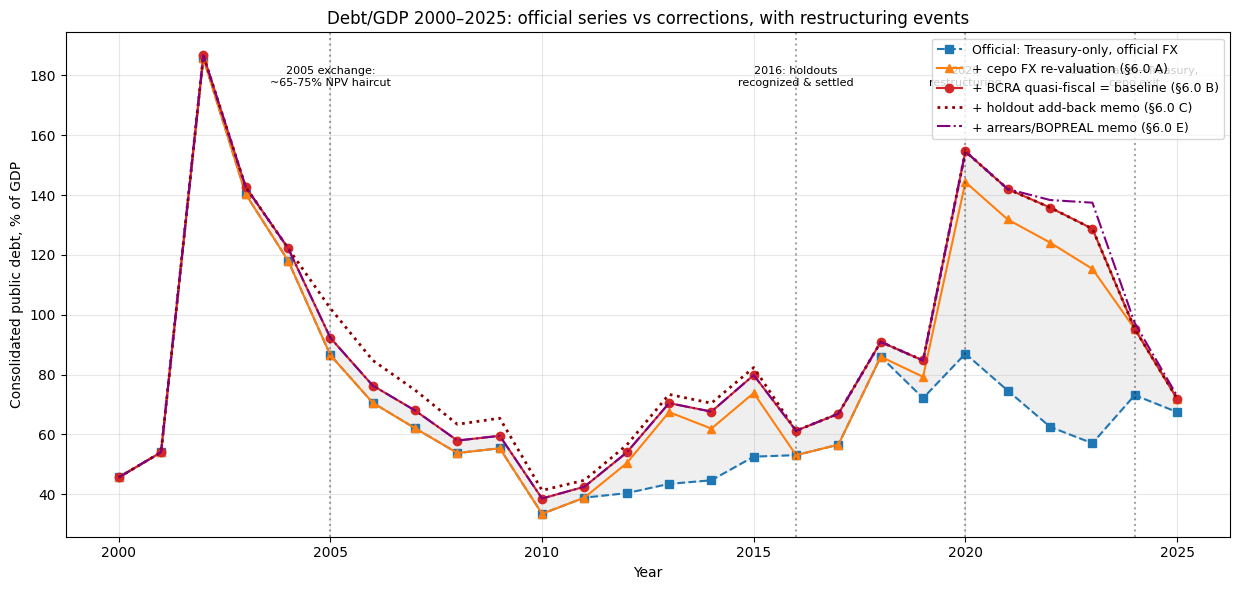

In [26]:
# Debt/GDP 2000-2025: every layer from the raw official series to the corrected baseline and
# the sensitivity memos, with the events that explain the big moves (sections 6.0 A-E).
dbt = fpi_raw.loc[2000:2025]
fig, ax = plt.subplots(figsize=(12.5, 6))
ax.plot(dbt.index, dbt["Debt_GDP_official"] * 100, "s--", color="tab:blue",
        label="Official: Treasury-only, official FX")
ax.plot(dbt.index, dbt["Debt_GDP_official"] * dbt["Cepo_Factor"] * 100, "^-",
        color="tab:orange", label="+ cepo FX re-valuation (\u00a76.0 A)")
ax.plot(dbt.index, dbt["Debt_GDP"] * 100, "o-", color="tab:red",
        label="+ BCRA quasi-fiscal = baseline (\u00a76.0 B)")
ax.plot(dbt.index, dbt["Debt_GDP_holdouts"] * 100, ":", color="darkred", lw=2,
        label="+ holdout add-back memo (\u00a76.0 C)")
ax.plot(dbt.index, dbt["Debt_GDP_arrears"] * 100, "-.", color="purple",
        label="+ arrears/BOPREAL memo (\u00a76.0 E)")
ax.fill_between(dbt.index, dbt["Debt_GDP_official"] * 100, dbt["Debt_GDP"] * 100,
                color="gray", alpha=0.12)
events = [(2005, "2005 exchange:\n~65-75% NPV haircut"),
          (2016, "2016: holdouts\nrecognized & settled"),
          (2020, "2020\nrestructuring"),
          (2024, "2024: Pases\u2192Treasury,\ncepo exit")]
ymax = float((dbt["Debt_GDP_arrears"] * 100).max())
for yr, txt in events:
    ax.axvline(yr, color="k", ls=":", alpha=0.35)
    ax.annotate(txt, (yr, ymax * 0.98), fontsize=8, ha="center", va="top")
ax.set_ylabel("Consolidated public debt, % of GDP")
ax.set_xlabel("Year")
ax.set_title("Debt/GDP 2000\u20132025: official series vs corrections, with restructuring events")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

*Figure. The gray area is the gap between the official debt ratio and the corrected baseline. Readings: the 2005 and 2016 verticals separate haircut/recognition effects from fiscal effort (the 2005 drop mixes a real restructuring gain with the simple non-recognition of holdout claims — dotted line); the cepo layers show how the official FX overvaluation understated the 2012–15 and 2019–23 burden; the red minus blue gap in 2017–23 is the central bank's hidden debt; and 2024–25 shows the consolidation/cleanup measured against an honestly-valued inherited baseline.*

In [27]:
# Contemporaneous FPI term averages (descriptive) — mirrors the paper's Table 3.3.
fpi_terms = {}
for name, first_year, last_year, *_ in presidency_terms:
    years = [y for y in range(first_year, last_year + 1) if y in fpi_data.index]
    if not years:
        continue
    valid = fpi_data.loc[years]
    fpi_terms[name] = {
        "YearFrom":          first_year,
        "YearTo":            last_year,
        "Debt/GDP %":        valid["FPI_Debt_GDP"].mean() * 100,
        "Debt/Exports %":    valid["FPI_Debt_Exports"].mean() * 100,
        "Result/Revenue %":  valid["FPI_Result_Rev"].mean() * 100,
        "Result/DebtSv %":   valid["FPI_Result_DS"].mean() * 100,
        "(1+r)/(1+g) %":     valid["FPI_rg"].mean() * 100,
    }
fpi_terms_df = pd.DataFrame(fpi_terms).T
fpi_terms_df[["YearFrom", "YearTo", "Debt/GDP %", "Debt/Exports %",
              "Result/Revenue %", "Result/DebtSv %", "(1+r)/(1+g) %"]].round(1)

,YearFrom,YearTo,Debt/GDP %,Debt/Exports %,Result/Revenue %,Result/DebtSv %,(1+r)/(1+g) %
Alsina,1853.0,1853.0,60.1,130.1,-121.0,-406.7,139.7
Obligado,1854.0,1856.0,49.7,111.1,2.7,11.2,107.6
Alsina II,1857.0,1859.0,59.1,121.3,-33.1,-260.6,122.0
Mitre,1860.0,1868.0,69.8,148.9,2.2,-1.3,105.8
Sarmiento,1869.0,1874.0,80.6,186.2,-11.1,-18.0,108.4
Avellaneda,1875.0,1880.0,68.7,174.0,3.6,8.1,105.4
Roca,1881.0,1886.0,58.3,181.0,-25.2,-72.8,100.3
Juárez Celman,1887.0,1890.0,82.0,281.4,-12.9,-91.4,103.9
Pellegrini,1891.0,1892.0,124.7,366.9,-1.5,6.4,116.1
Sáenz Peña L./Uriburu JE,1893.0,1898.0,110.2,384.9,-9.5,-20.7,107.8


*Table 5. Contemporaneous fiscal performance, 1853–2025 (term averages) — mirrors the paper's
Table 3.3. Negative Result/Revenue or Result/DebtService indicates a primary deficit; values
above 100% for (1+r)/(1+g) indicate that the debt-to-GDP ratio grows automatically even with a
balanced primary budget. Descriptive only — the FPI below scores improvements over the inherited
fiscal position, not absolute levels.*

In [28]:
# FPI innovations and scoring — identical machinery to the CMPI, applied to the 5 fiscal variables.
FPI_VARIABLES = ["FPI_Debt_GDP", "FPI_Debt_Exports", "FPI_Result_Rev", "FPI_Result_DS", "FPI_rg"]
# Sort direction (paper Table 3.6): lower debt-burden increase, lower (1+r)/(1+g) are better
# (ascending=False); higher primary-result ratios are better (ascending=True).
FPI_SORT = {
    "FPI_Debt_GDP":     False,
    "FPI_Debt_Exports": False,
    "FPI_Result_Rev":   True,
    "FPI_Result_DS":    True,
    "FPI_rg":           False,
}


def fpi_year_values(year: int) -> pd.Series:
    """The five FPI variables for one year (level values, not log-diffs)."""
    if year not in fpi_data.index:
        return pd.Series({v: np.nan for v in FPI_VARIABLES})
    row = fpi_data.loc[year]
    return pd.Series({v: row[v] for v in FPI_VARIABLES})


def fpi_annual_innovations() -> pd.DataFrame:
    """Each administration-year as a fiscal innovation vs the previous administration's last year."""
    records, term_of = {}, {}
    for name, first_year, last_year, *_ in presidency_terms:
        inherited = fpi_year_values(first_year - 1)
        for year in range(first_year, last_year + 1):
            records[year] = fpi_year_values(year) - inherited
            term_of[year] = name
    innov = pd.DataFrame(records).T
    innov["Term"] = pd.Series(term_of)
    return innov


fpi_innovations = fpi_annual_innovations()

# Main FPI ranking
fpi_ranking = fpi_scores_from_innovations(fpi_innovations, presidency_terms, pool_end=DATA_END_YEAR)

# Parity check vs the pure core implementation
try:
    fpi_year_fn = make_fpi_year_value_fn(fpi_data)
    core_fpi_innov = compute_innovations(presidency_terms, fpi_year_fn)
    core_fpi_rank = fpi_scores_from_innovations(core_fpi_innov, presidency_terms, pool_end=DATA_END_YEAR)
    common = sorted(set(fpi_ranking.index) & set(core_fpi_rank.index)) if "fpi_ranking" in dir() else []
    if common:
        d = (fpi_ranking.loc[common, "FPI"] - core_fpi_rank.loc[common, "FPI"]).abs().max()
        print(f"Core FPI parity: max |FPI diff| = {d:.2e}")
except Exception as e:
    print(f"Core FPI parity note: {e}")

# NaN audit — every pool year must have all five FPI components.
fpi_nan_years = [y for y in fpi_innovations.index if fpi_innovations.loc[y, FPI_VARIABLES].isna().any()]
assert len(fpi_innovations) == 173, f"Expected 173 FPI pool years, got {len(fpi_innovations)}"
assert not fpi_nan_years, f"NaN in FPI innovations for years: {fpi_nan_years}"
print(f"FPI pool: {len(fpi_innovations)} years (1853-2025), no missing components ✓")

Core FPI parity: max |FPI diff| = 0.00e+00
FPI pool: 173 years (1853-2025), no missing components ✓


In [29]:
# FPI ranking, full 173-year pool (1853-2025).
if "FPI Rank" not in fpi_ranking.columns:
    fpi_ranking.insert(0, "FPI Rank", list(range(1, len(fpi_ranking) + 1)))
fpi_ranking["Term"]      = [f"{meta[n][0]}–{meta[n][1]}" for n in fpi_ranking.index]
fpi_ranking["Regime"]    = ["Historical" if meta[n][1] <= 1963 else "Modern" for n in fpi_ranking.index]
fpi_ranking["President"] = [meta[n][2] for n in fpi_ranking.index]
fpi_ranking["Data"] = [term_quality_badge(meta[n][0], meta[n][1],
                                          ["Debt_GDP", "Debt_Exports", "Result_Revenue", "Result_DebtServ"])
                       for n in fpi_ranking.index]

fpi_display_cols = ["FPI Rank", "Term", "Regime",
                    "FPI_Debt_GDP", "FPI_Debt_Exports", "FPI_Result_Rev", "FPI_Result_DS",
                    "FPI_rg", "FPI", "Data", "President"]
fpi_ranking_show = fpi_ranking[fpi_display_cols].rename(columns={
    "FPI_Debt_GDP": "Debt/GDP", "FPI_Debt_Exports": "Debt/Exp",
    "FPI_Result_Rev": "Res/Rev", "FPI_Result_DS": "Res/DebtSv", "FPI_rg": "(1+r)/(1+g)",
})
HTML(
    fpi_ranking_show.round(3).to_html(
        escape=False, formatters={"President": president_img}
    )
)

,FPI Rank,Term,Regime,Debt/GDP,Debt/Exp,Res/Rev,Res/DebtSv,(1+r)/(1+g),FPI,Data,President
Obligado,1,1854–1856,Historical,0.696,0.696,0.967,0.936,0.929,0.845,100% A/B (worst A),
Milei,2,2024–2025,Modern,0.945,0.737,0.740,0.838,0.818,0.816,50% A/B (worst D),
Roca II,3,1899–1904,Historical,0.716,0.895,0.962,0.888,0.417,0.776,100% A/B (worst A),
N.Kirchner,4,2004–2007,Modern,0.941,0.970,0.480,0.500,0.877,0.753,100% A/B (worst B),
Menem,5,1990–1995,Modern,0.968,0.561,0.629,0.609,0.838,0.721,100% A/B (worst A),
Perón I,6,1946–1951,Historical,0.795,0.961,0.740,0.297,0.685,0.695,100% A/B (worst A),
Avellaneda,7,1875–1880,Historical,0.819,0.549,0.515,0.501,0.952,0.667,100% A/B (worst A),
Mitre,8,1860–1868,Historical,0.324,0.389,0.905,0.969,0.695,0.656,83% A/B (worst C),
Yrigoyen,9,1917–1922,Historical,0.601,0.773,0.636,0.611,0.618,0.648,100% A/B (worst A),
Uriburu JF,10,1931–1931,Historical,0.630,0.780,0.751,0.682,0.347,0.638,100% A/B (worst A),


*Table 6. FPI ranking, 1853–2025. Each component is the term's average [0, 1] percentile
(1 = best) across the full 173-year pool; FPI is their mean. Administrations that reduced the
debt burden, ran primary surpluses, and kept the (1+r)/(1+g) factor low rank highest. Obligado
(1854–56) leads; **Milei (2024–25) ranks second** once the BCRA quasi-fiscal debt is consolidated
and the cepo distortion removed (see §6.0 and Table 4a), reflecting the sharp 2024–25 debt-burden
reduction and the first primary surplus in this dataset since 2013. The administrations that
accumulated hidden central-bank debt — Alberto Fernández (2020–23, #39) and Cristina Kirchner II
(2012–15, #38) — and the 2001–02 collapse (Duhalde, #40) sit at the bottom. Rank sensitivity to the §6.0 assumptions is shown in
Table 6a below.* **Milei's term is partial (2024–25); the 2025 fiscal inputs are provisional (Figure 0).** *The Data column summarizes Figure 0 for the four fiscal inputs (the (1+r)/(1+g) factor inherits the Interest and Growth grades). The full §6.0 sensitivity suite is Tables 6a–6f.*

**Fairness asymmetries to keep in mind when reading this table.** Three known distortions are
*not* corrected in the baseline (see the §3.0 catalogue) and act in different directions:
(1) the 1980s Cuenta de Regulación Monetaria quasi-fiscal debt is not consolidated, which flatters
Alfonsín relative to the 2003+ terms that do carry the §6.0 B consolidation; (2) end-2023 importer
arrears and their 2024 BOPREAL conversion are excluded on *both* sides, which flatters Alberto
Fernández's closing stock and would penalise Milei if added one-sidedly; (3) the 2024–25 primary
ratios are cash-basis and exclude capitalizing LECAP/BONCAP interest, which flatters Milei. Each is now bounded by a re-ranked sensitivity rather than only disclosed: the 1980s
quasi-fiscal stock in Table 6f, the arrears/BOPREAL pairing in Table 6d, and the 2024–25
cash-vs-accrual gap in Table 6b variant (g); the cepo FX-share assumption is bounded in
Table 6a (measured composition and 50% lower bound).

In [30]:
# Sensitivity of the §6.0 corrections — two alternative assumptions, re-ranked end-to-end.
#
# (a) Cepo FX share 50%: the baseline re-values the *entire* debt stock at the parallel rate,
#     which is exact only if all public debt is USD-denominated. Peso-denominated debt (a large
#     share after 2020) does not gain USD value when the gap closes, so the baseline factor is
#     an upper bound. This variant applies the factor to only half the stock:
#     Debt/GDP = official x (0.5 x cepo_factor + 0.5) + BCRA.
# (b) rg with total GDP growth: the paper defines g in (1+r)/(1+g) as *total* activity growth;
#     the baseline uses per-capita growth (the only annual series in the paper authors'
#     dataset — see §11). Variant: WDI total real GDP growth for 1961-2024 plus the INDEC 2025
#     advance (+4.4%); per-capita-based values remain before 1961.
def fpi_rank_variant(frame: pd.DataFrame) -> pd.Series:
    iv = compute_innovations(presidency_terms, make_fpi_year_value_fn(frame))
    scores = fpi_scores_from_innovations(iv, presidency_terms, pool_end=DATA_END_YEAR)
    return scores["FPI"].rank(ascending=False, method="min").astype(int)

# (a') Measured FX share: instead of the flat 50%, use the Secretaría de Finanzas
#     foreign-currency composition of SPN gross debt (data/provided/cepo-fx-shares.csv,
#     ESTIMATE-flagged), pre-computed by the generator as Debt_GDP_fxshare.
fpi_fxshare = fpi_data.copy()
fpi_fxshare["FPI_Debt_GDP"] = fpi_raw["Debt_GDP_fxshare"]

fpi_half_fx = fpi_data.copy()
fpi_half_fx["FPI_Debt_GDP"] = (
    fpi_raw["Debt_GDP_official"] * (0.5 * fpi_raw["Cepo_Factor"] + 0.5)
    + fpi_raw["BCRA_QuasiFiscal_GDP"]
).fillna(fpi_raw["Debt_GDP"])

total_growth = indicator("NY.GDP.MKTP.KD.ZG", "GrowthTotal")["GrowthTotal"] / 100
total_growth.loc[2025] = 0.044   # INDEC, Informe de avance del nivel de actividad, 4T-2025
fpi_total_g = fpi_data.copy()
fpi_total_g["FPI_rg"] = (
    (1 + unified_interest)
    / (1 + total_growth.reindex(unified_interest.index).fillna(unified_growth))
).reindex(fpi_total_g.index)

fpi_sensitivity = pd.DataFrame({
    "Baseline rank":      fpi_rank_variant(fpi_data),
    "Measured FX share":  fpi_rank_variant(fpi_fxshare),
    "Cepo 50% FX share":  fpi_rank_variant(fpi_half_fx),
    "rg w/ total growth": fpi_rank_variant(fpi_total_g),
})
_focus = ["Obligado", "Milei", "Roca II", "N.Kirchner", "Menem", "Macri",
          "C.Kirchner II", "Fernandez", "Duhalde"]
fpi_sensitivity.loc[[t for t in _focus if t in fpi_sensitivity.index]]

,Baseline rank,Measured FX share,Cepo 50% FX share,rg w/ total growth
Obligado,1,1,1,1
Milei,2,2,2,2
Roca II,3,3,3,3
N.Kirchner,4,4,4,4
Menem,5,5,5,5
Macri,28,29,30,28
C.Kirchner II,37,37,37,37
Fernandez,40,40,40,40
Duhalde,39,39,39,39


*Table 6a. FPI-rank sensitivity to the §6.0 correction assumptions. The baseline re-values
the whole debt stock at the parallel rate — exact only if all debt is USD-denominated, so it
is an upper bound. The measured-FX-share column applies the Secretaría de Finanzas currency
composition year by year (`cepo-fx-shares.csv`, ESTIMATE-flagged); the 50% column is the
conservative lower bound. Replacing per-capita with total GDP growth in (1+r)/(1+g) leaves
every focus rank within one position. The podium composition (Obligado, Milei, Roca II) and
the bottom group (C. Kirchner II, Fernández, Duhalde) are stable across all specifications.*

### 6.0 (C) Default-integrity variants: "surplus" while not paying

Rows 6–7 of the §3.0 catalogue describe how the official fiscal series make the 2002–2015 window
look more virtuous than the underlying behaviour:

- **Accrued interest (2002–2005).** During the full default no interest was paid on the defaulted
  stock (~USD 81.8bn of eligible claims) until the June-2005 exchange. The cash-basis
  *Result/DebtServ* therefore compares the primary result against only the interest actually
  paid (multilaterals and performing debt, ~1.5–2% of GDP), ignoring roughly 4–6.5% of GDP per
  year of interest that was *due but unpaid*. Variant (c) rescales the ratio by
  $\text{paid}/(\text{paid} + \text{accrued unpaid})$. The accrual estimates are documented in
  `data/provided/fiscal-default-adjustments.csv` (flagged ESTIMATE, built from the eligible-stock
  size and average contractual coupons). Because the historical denominator may also include
  amortizations, this multiplicative rescaling is an **upper bound** on the penalty — the truth
  lies between the baseline and variant (c).
- **Holdout add-back (2005–2015).** The official debt stock excluded the defaulted debt *not
  tendered* into the 2005/2010 exchanges (~USD 19.6bn of principal after 2005; ~USD 11.5bn of
  remaining claims after the 2010 reopening), which was recognized and settled only in 2016
  (~USD 9.3bn cash). Variant (d) restores those claims to Debt/GDP, valued against the same
  (parallel-corrected) USD GDP as the baseline. Without it, the 2005 "debt reduction" mixes
  genuine restructuring gains with simple non-recognition — and Macri's 2016 debt increase is
  partly the *recognition* of liabilities that existed all along.

- **Capitalizing interest (2024–2025), variant (g).** The celebrated 2024–25 cash-basis
  results compare the primary surplus against only the interest *paid in cash*; LECAP/BONCAP
  and zero-coupon instruments capitalize their interest instead (≈2.4% / ≈2.0% of GDP —
  `fiscal-default-adjustments.csv`, ESTIMATE rows built from the OPC's accrual-basis
  reports). Variant (g) applies the same `paid/(paid + accrued)` rescaling as the 2002–05
  default window, so *Result/DebtServ* measures resources against interest *due*, not
  interest *paid*. The primary-result/revenue ratio is deliberately left untouched: the
  primary result excludes interest by definition, so capitalization changes the financing
  mix, not the primary effort. Like the 2002–05 rescaling, this is an upper bound on the
  penalty.

Three later episodes are **flagged but not adjusted** (`DefaultFlag` column): the 2014 *selective*
default (coupon payments were deposited by Argentina but blocked by the *pari passu* injunction —
the cash effort was made), the 2019 reprofiling (bills postponed, later exchanged), and the 2020
restructuring (unpaid coupons were capitalized into the new bonds, so the debt stock already
carries them).

These variants change *measurement*, not the haircut itself: a successful restructuring that cuts
the debt burden is a real fiscal outcome and still scores as such. What the variants remove is the
extra credit earned by *not paying and not recognizing* — exactly the distinction between
N.Kirchner's genuine primary surpluses (which survive every variant) and the part of his fiscal
ranking that comes from measuring debt service only when it was convenient to pay it.

In [31]:
# Table 6b — default-integrity variants, re-ranked end-to-end with the same machinery as
# Table 6a. Memo columns come from data/provided/fiscal-default-adjustments.csv via
# scripts/generate_fiscal_fpi-fiscal.py; they equal the baseline outside their windows.
# The accrual column now carries two windows: the 2002-05 default and the 2024-25
# capitalizing-interest rescaling; (c) and (g) isolate each, the last column applies all.
_acc = fpi_raw["Result_DebtServ_accrual"]
_ds  = fpi_data["FPI_Result_DS"]

fpi_accrual = fpi_data.copy()            # (c) 2002-05 default window only
fpi_accrual["FPI_Result_DS"] = _ds.where(_ds.index > 2005, _acc)

fpi_capitalizing = fpi_data.copy()       # (g) 2024-25 capitalizing window only
fpi_capitalizing["FPI_Result_DS"] = _ds.where(_ds.index < 2024, _acc)

fpi_holdouts = fpi_data.copy()           # (d) untendered holdout stock 2005-2015
fpi_holdouts["FPI_Debt_GDP"] = fpi_raw["Debt_GDP_holdouts"]

fpi_default_all = fpi_data.copy()        # (c)+(d)+(g) together
fpi_default_all["FPI_Result_DS"] = _acc
fpi_default_all["FPI_Debt_GDP"] = fpi_raw["Debt_GDP_holdouts"]

fpi_default_sens = pd.DataFrame({
    "Baseline rank":           fpi_rank_variant(fpi_data),
    "(c) Accrued 2002-05":     fpi_rank_variant(fpi_accrual),
    "(d) Holdout add-back":    fpi_rank_variant(fpi_holdouts),
    "(g) Capitalizing 2024-25": fpi_rank_variant(fpi_capitalizing),
    "(c)+(d)+(g) all":         fpi_rank_variant(fpi_default_all),
})
_focus_default = ["N.Kirchner", "Duhalde", "C.Kirchner", "C.Kirchner II", "Macri",
                  "Fernandez", "Milei", "Menem", "Obligado"]
fpi_default_sens.loc[[t for t in _focus_default if t in fpi_default_sens.index]]

,Baseline rank,(c) Accrued 2002-05,(d) Holdout add-back,(g) Capitalizing 2024-25,(c)+(d)+(g) all
N.Kirchner,4,4,4,4,4
Duhalde,39,39,39,39,39
C.Kirchner,19,19,17,19,17
C.Kirchner II,37,37,37,37,37
Macri,28,28,26,28,26
Fernandez,40,40,40,40,40
Milei,2,2,2,2,2
Menem,5,5,5,5,5
Obligado,1,1,1,1,1


*Table 6b. FPI ranks under the default-integrity variants of §6.0 (C). Variant (c) scores
debt service on interest due rather than interest paid during the 2002–2005 default;
variant (d) restores the untendered holdout debt to the 2005–2015 stock; variant (g)
applies the same interest-due rescaling to the 2024–25 cash results, whose LECAP/BONCAP
interest capitalizes instead of being paid (§3.0 row 16 — the caveat that favours the
current administration). All are estimate-based sensitivities (see the CSV's Source
column), reported whichever administration they favour; the headline FPI in Table 6 stays
cash-basis and official-stock-based like the paper.*

### 6.0 (D) Structural primary balance: removing one-off and accounting-driven revenues

Several administrations' primary-result ratios are flattered by revenues that involve no fiscal
effort and cannot recur — §3.0 catalogue rows 9, 10 and 14. The curated file
`data/provided/fiscal-one-offs.csv` lists them year by year with sources; rows typed `one-off`
are removed from both the result and the revenue base:

$$\text{Result/Rev}^{\text{structural}} = \frac{R - o}{1 - o}, \qquad
o = \frac{\text{one-off revenues}}{\text{total revenues}}.$$

The list is **concept-matched to each era's revenue definition**: the paper authors' 2009–2015
series counts ANSES/FGS investment income and the BCRA's devaluation-driven accounting-profit
transfers as ordinary revenue, so both are subtracted there (together 4–10% of revenues per year);
the 2019–2025 ratios follow the SPN cash-basis presentation, where BCRA profit transfers are
below-the-line *financing* — so for those years only genuine in-revenue one-offs are removed
(the Aug-2021 SDR allocation booked as property income, ≈ 5.5% of revenues; the 2022–23
dólar-soja schemes that pulled export duties forward; the 2016–17 and 2024 tax-amnesty levies;
and the 2024 REIBP five-year advance of the wealth tax). The 2008 AFJP asset transfer (~9% of
GDP) is a balance-sheet one-off, not flow revenue, so it is documented but not subtracted; the
redirected pension contributions (~1.5% of GDP/yr from 2009) are genuine recurring revenue paired
with an unbooked implicit liability — also documented-only.

The result reproduces the standard finding of the fiscal literature: the **2010–2013 reported
primary surpluses flip to structural deficits** once FGS/BCRA rentas are excluded, the 2021
deficit deepens by the SDR booking, and **Milei's 2024 surplus narrows (0.104 → 0.076 of
revenues) but survives** — the only post-2008 primary surplus that does. All magnitudes are
order-of-magnitude estimates flagged in the CSV; Table 6c re-ranks the FPI with the structural
column so the reader can see how much of each fiscal ranking rests on one-offs.

In [32]:
# Table 6c — structural-balance variant: FPI re-ranked with Result/Revenue net of one-off
# revenues (data/provided/fiscal-one-offs.csv via generate_fiscal_fpi-fiscal.py, section 6.0 D).
fpi_structural = fpi_data.copy()
fpi_structural["FPI_Result_Rev"] = fpi_raw["Result_Revenue_structural"]

fpi_structural_sens = pd.DataFrame({
    "Baseline rank":            fpi_rank_variant(fpi_data),
    "(e) Structural Result/Rev": fpi_rank_variant(fpi_structural),
})
_focus_struct = ["N.Kirchner", "C.Kirchner", "C.Kirchner II", "Macri", "Fernandez",
                 "Milei", "Menem", "Duhalde", "Obligado"]
fpi_structural_sens.loc[[t for t in _focus_struct if t in fpi_structural_sens.index]]

,Baseline rank,(e) Structural Result/Rev
N.Kirchner,4,4
C.Kirchner,19,19
C.Kirchner II,37,38
Macri,28,24
Fernandez,40,40
Milei,2,2
Menem,5,5
Duhalde,39,39
Obligado,1,1


*Table 6c. FPI ranks when the primary-result/revenue component is computed net of one-off and accounting-driven revenues (FGS/BCRA rentas 2009–2015, the 2021 SDR booking, dólar-soja advances, tax-amnesty levies, the 2024 REIBP advance). Estimate-based sensitivity; the headline FPI keeps each era's official revenue concept.*

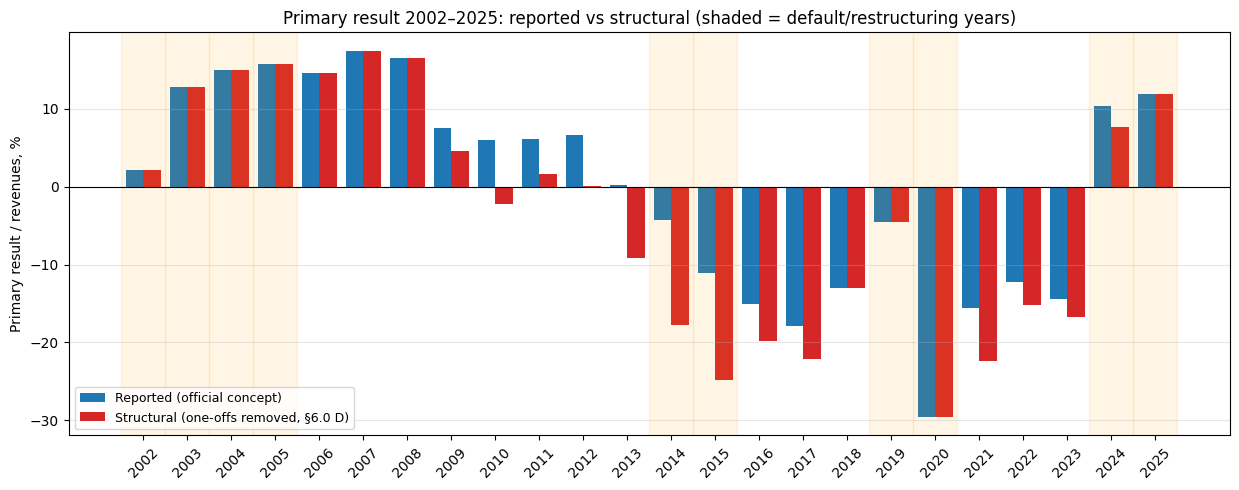

In [33]:
# Reported vs structural primary result (% of revenues), 2002-2025, with default years marked.
pr = (fpi_raw.loc[2002:2025, ["Result_Revenue", "Result_Revenue_structural"]] * 100)
fig, ax = plt.subplots(figsize=(12.5, 5))
x = np.arange(len(pr.index))
ax.bar(x - 0.2, pr["Result_Revenue"], 0.4, color="tab:blue", label="Reported (official concept)")
ax.bar(x + 0.2, pr["Result_Revenue_structural"], 0.4, color="tab:red",
       label="Structural (one-offs removed, \u00a76.0 D)")
flags = fpi_raw.loc[2002:2025, "DefaultFlag"].fillna("")
for i, (yr, fl) in enumerate(flags.items()):
    if str(fl).strip():
        ax.axvspan(i - 0.5, i + 0.5, color="orange", alpha=0.10)
ax.set_xticks(x)
ax.set_xticklabels(pr.index, rotation=45)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("Primary result / revenues, %")
ax.set_title("Primary result 2002\u20132025: reported vs structural (shaded = default/restructuring years)")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

*Figure. Blue bars are each era's official concept (the paper authors' series to 2018, SPN base caja from 2019); red bars remove the one-off and accounting-driven revenues catalogued in §6.0 D. The reported 2010–2013 surpluses flip to structural deficits; Milei's 2024 surplus narrows but stands. Orange shading marks the default/reprofiling/restructuring/capitalizing-interest windows flagged in §6.0 C; in all of them the cash debt-service ratio understates the true burden (in 2024–25 because LECAP/BONCAP interest capitalizes instead of being paid in cash).*

### 6.0 (E) The quasi-fiscal *flow*, and the importer-arrears / BOPREAL symmetry

**Quasi-fiscal interest (documented, deliberately not scored).** §6.0 (B) consolidates the
*stock* of the central bank's remunerated liabilities; their *interest* — the quasi-fiscal
deficit proper — is also estimated in `bcra-quasi-fiscal-2001-2025.csv`
(`BCRA_QuasiFiscal_Interest_GDP`: ~2.8% of GDP nominal at the 2017 *bola de Lebac* peak, ~3–4.5%
in 2019–2022, ~9% nominal in 2023 at triple-digit rates, → 0 after the 2024 migration). Two
reasons keep it out of the scored index. First, the *Result/DebtServ* ratio is non-monotone when
the primary result is negative: enlarging the denominator pulls a deficit ratio toward zero,
which would *improve* the apparent score of exactly the administrations that ran the largest
quasi-fiscal deficits. Second, in high-inflation years the nominal flow is mostly inflation
compensation — the real burden was largely liquefied by the inflation the CMPI already scores —
so adding it would double-count the same distortion. The series is kept as the quantified
evidence behind §3.0 row 12.

**Importer arrears ↔ BOPREAL (paired sensitivity).** Under the 2022–23 import controls the
economy accumulated payment arrears far above the normal trade-credit stock (BCRA import-debt
survey: ~USD 58bn at end-2023 vs a ~USD 30bn historical norm) — an invisible public-sector-adjacent
liability on Alberto Fernández's closing balance. In 2024 those arrears were converted into the
BCRA's BOPREAL bonds (~USD 10bn issued), making them *visible*; counted naively they would look
like debt Milei created. The baseline excludes both sides; variant (f) adds both sides
(`Debt_GDP_arrears`), valued against the same parallel-corrected USD GDP as the §6.0 (A)
correction. Either treatment is internally consistent — what would be dishonest is counting the
BOPREAL without the arrears it paid off, or vice versa.

In [34]:
# Table 6d — paired arrears/BOPREAL variant (section 6.0 E): the 2022-23 invisible import
# arrears and the 2024-25 BOPREAL bonds that settled them are added to Debt/GDP on BOTH sides
# of the 2023/2024 administration change (the baseline excludes both).
fpi_arrears = fpi_data.copy()
fpi_arrears["FPI_Debt_GDP"] = fpi_raw["Debt_GDP_arrears"]

fpi_arrears_sens = pd.DataFrame({
    "Baseline rank":             fpi_rank_variant(fpi_data),
    "(f) Arrears/BOPREAL added": fpi_rank_variant(fpi_arrears),
})
_focus_arrears = ["Fernandez", "Milei", "C.Kirchner II", "Macri", "N.Kirchner",
                  "Duhalde", "Obligado"]
fpi_arrears_sens.loc[[t for t in _focus_arrears if t in fpi_arrears_sens.index]]

,Baseline rank,(f) Arrears/BOPREAL added
Fernandez,40,40
Milei,2,2
C.Kirchner II,37,37
Macri,28,28
N.Kirchner,4,4
Duhalde,39,39
Obligado,1,1


*Table 6d. FPI ranks under the paired importer-arrears / BOPREAL add-back of §6.0 (E). The 2022–23 arrears penalise the administration that accumulated them invisibly; the 2024–25 BOPREAL stock is counted symmetrically against the administration that made them visible. Estimate-based sensitivity (BCRA import-debt survey; BOPREAL issuance reports).*

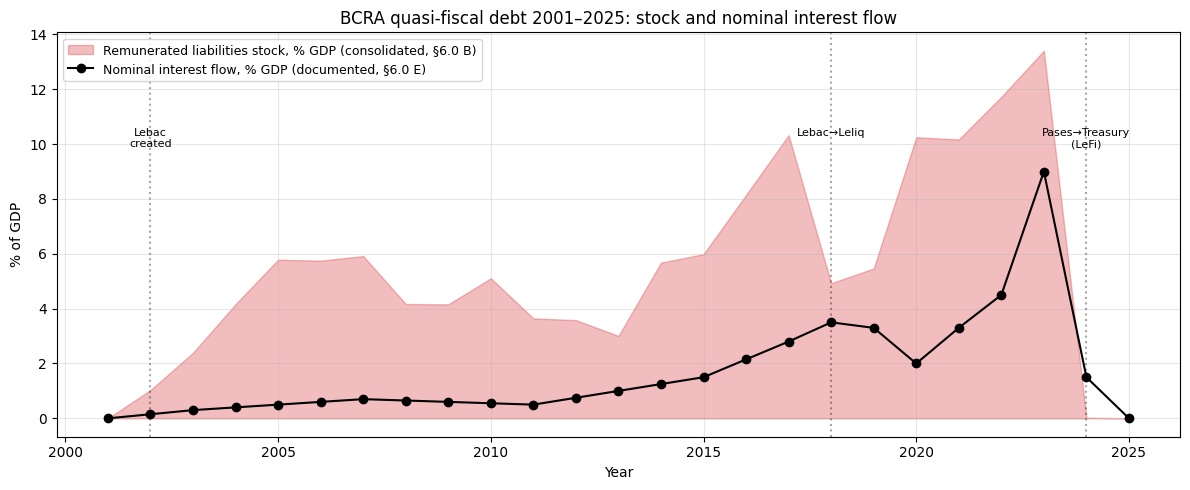

In [35]:
# The central bank's hidden debt: remunerated-liability stock (consolidated into the FPI
# baseline) and its nominal interest flow (documented, not scored - see section 6.0 E).
qf = pd.read_csv(BCRA_QF_PATH).set_index("Year")
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(qf.index, qf["BCRA_QuasiFiscal_GDP"] * 100, color="tab:red", alpha=0.30,
                label="Remunerated liabilities stock, % GDP (consolidated, \u00a76.0 B)")
ax.plot(qf.index, qf["BCRA_QuasiFiscal_Interest_GDP"] * 100, "o-", color="black",
        label="Nominal interest flow, % GDP (documented, \u00a76.0 E)")
for yr, txt in [(2002, "Lebac\ncreated"), (2018, "Lebac\u2192Leliq"),
                (2024, "Pases\u2192Treasury\n(LeFi)")]:
    ax.axvline(yr, color="k", ls=":", alpha=0.35)
    ax.annotate(txt, (yr, 10.6), fontsize=8, ha="center", va="top")
ax.set_ylabel("% of GDP")
ax.set_xlabel("Year")
ax.set_title("BCRA quasi-fiscal debt 2001\u20132025: stock and nominal interest flow")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

*Figure. The stock (shaded) is hidden public debt the FPI baseline consolidates; December year-end stocks are measured from the BCRA statistical API (series 1258/1260/1262, plus 1259 through 2017); `generate_fiscal_bcra-quasi-fiscal.py` keeps the curated anchors as cross-checks (grade B in Figure 0). The interest line is the quasi-fiscal deficit in nominal terms — at triple-digit inflation (2023) it is mostly inflation compensation, which is why it is documented rather than scored (§6.0 E).*

### 6.0 (F) Contingent and litigated liabilities: claims in no debt stock

Two liabilities sat (or sit) outside every official debt series used here (§3.0 row 21):

- **The YPF expropriation judgment.** The 2012 expropriation (CFK II) created a litigated
  claim that crystallized as a **USD 16.1bn** SDNY judgment in September 2023
  (*Petersen/Eton Park v. Argentina*) — ≈5% of (parallel-corrected) GDP — unpaid, under
  appeal, and in no official stock. Counted from the judgment year, it lands on Alberto
  Fernández's closing balance and persists through 2024–25.
- **Paris Club arrears beyond the recognized stock.** Between the 2001 default and the
  May-2014 settlement, arrears and punitive charges accrued past what the official series
  carried; the settlement recognized **~USD 9.7bn**, of which roughly USD 3.6bn exceeded
  the previously booked stock. The add-back accrues that excess linearly over 2002–2013
  (ESTIMATE rows), so the 2014 stock jump reads as *recognition*, not new borrowing.

Variant (h) adds both to Debt/GDP, valued against the same (parallel-corrected) USD GDP
as every other §6.0 add-back. Sensitivity-only: contingency and litigation risk are
judgment calls, so the headline FPI keeps the official-stock convention.


In [36]:
# Table 6e — contingent-liability variant (section 6.0 F): litigated claims in no
# official stock (YPF judgment 2023-2025; Paris Club arrears beyond the recognized
# stock 2002-2013), from data/provided/contingent-liabilities.csv via the generator.
fpi_contingent = fpi_data.copy()
fpi_contingent["FPI_Debt_GDP"] = fpi_raw["Debt_GDP_contingent"]

fpi_contingent_sens = pd.DataFrame({
    "Baseline rank":        fpi_rank_variant(fpi_data),
    "(h) Contingent added": fpi_rank_variant(fpi_contingent),
})
_focus_cont = ["C.Kirchner II", "Fernandez", "Milei", "N.Kirchner", "C.Kirchner",
               "Macri", "Duhalde", "Obligado"]
fpi_contingent_sens.loc[[t for t in _focus_cont if t in fpi_contingent_sens.index]]

,Baseline rank,(h) Contingent added
C.Kirchner II,37,37
Fernandez,40,40
Milei,2,2
N.Kirchner,4,4
C.Kirchner,19,19
Macri,28,28
Duhalde,39,39
Obligado,1,1


*Table 6e. FPI ranks with contingent/litigated liabilities added to Debt/GDP (§6.0 F).
The YPF judgment penalises the closing stocks of the administrations that created and
carried the claim invisibly; the Paris Club accrual shifts part of the 2014 debt print
back to the years the arrears actually built up. Estimate-based sensitivity
(`contingent-liabilities.csv`, per-row sources); the headline FPI keeps the official
stock convention.*

### 6.0 (G) Historical quasi-fiscal debt, 1977–1990: bounding the row-13 asymmetry

The §6.0 (B) consolidation starts in 2003, which *flatters* the administrations whose
central bank carried remunerated liabilities **before** Lebac existed: the 1977-reform
remunerated reserve requirements and the Cuenta de Regulación Monetaria (whose
quasi-fiscal deficit reached several points of GDP under Alfonsín), plus the 1981–83
*seguro de cambio* losses under the junta (§3.0 row 13). Curatable year-end balance-sheet
anchors for that era are far weaker than for the Lebac/Leliq cycle, so the baseline
remains Treasury-only before 2003 — but variant (i) consolidates an **ESTIMATE-flagged**
1977–90 stock (`bcra-quasi-fiscal-historical.csv`: ~1% of GDP in 1977 rising to ~9% by
1988, liquefied by the 1989 hyperinflation, converted to BONEX — Treasury debt — in
January 1990), so the reader can see how far the asymmetry could move the ranking.


In [37]:
# Table 6f — historical quasi-fiscal consolidation (section 6.0 G): ESTIMATE-flagged
# remunerated-liability stock 1977-1990 (CRM / seguro-de-cambio era) added to Debt/GDP,
# bounding the fairness asymmetry of section 3.0 row 13.
hist_qf = pd.read_csv("data/provided/bcra-quasi-fiscal-historical.csv").set_index("Year")["Stock_GDP"]
fpi_hist_qf = fpi_data.copy()
fpi_hist_qf["FPI_Debt_GDP"] = fpi_data["FPI_Debt_GDP"].add(
    hist_qf.reindex(fpi_data.index).fillna(0.0))

fpi_hist_qf_sens = pd.DataFrame({
    "Baseline rank":               fpi_rank_variant(fpi_data),
    "(i) 1977-90 QF consolidated": fpi_rank_variant(fpi_hist_qf),
})
_focus_qf = ["Videla/Viola/Galtieri/Bignone", "Alfonsin", "Menem", "Peron III",
             "Milei", "Fernandez", "Obligado"]
fpi_hist_qf_sens.loc[[t for t in _focus_qf if t in fpi_hist_qf_sens.index]]

,Baseline rank,(i) 1977-90 QF consolidated
Videla/Viola/Galtieri/Bignone,12,12
Alfonsin,27,27
Menem,5,5
Peron III,30,30
Milei,2,2
Fernandez,40,40
Obligado,1,1


*Table 6f. FPI ranks with the 1977–1990 central-bank remunerated stock consolidated into
Debt/GDP (§6.0 G). The build-up penalises the junta (1976–83) and Alfonsín (1984–89) the
same way the Lebac/Leliq/Pases cycle penalises the 2003+ terms; the 1989 liquefaction and
the January-1990 BONEX conversion are credited to the years they occurred. All values are
order-of-magnitude estimates (per-row sources in the CSV) — sensitivity-only.*

### 6.1 FPI coherence with the paper's Table 3.4

The historical FPI components (1853–2018) come from the paper authors' own dataset, so the
restricted 1853–1999 pool should reproduce the paper's published FPI ranking very closely.

In [38]:
# Coherence: compare our FPI ranking (restricted 1853-1999 pool) with the paper's Table 3.4 FPI column.
PAPER_FPI_RANKS = {
    "Alsina": 33, "Obligado": 1, "Alsina II": 32, "Mitre": 6, "Sarmiento": 11,
    "Avellaneda": 5, "Roca": 26, "Juárez Celman": 31, "Pellegrini": 20,
    "Sáenz Peña L./Uriburu JE": 16, "Roca II": 2, "Quintana/Figueroa": 15,
    "Sáenz Peña R./de la Plaza": 24, "Yrigoyen": 7, "De Alvear": 18, "Yrigoyen II": 30,
    "Uriburu JF": 8, "Justo": 22, "Ortiz/Castillo": 28, "Ramírez/Farrell": 29,
    "Perón I": 4, "Perón II": 23, "Aramburu": 17, "Frondizi": 14, "Guido": 27,
    "Illia": 13, "Ongania": 9, "Levingston/Lanusse": 19, "Peron III": 25,
    "Videla/Viola/Galtieri/Bignone": 10, "Alfonsin": 21, "Menem": 3, "Menem II": 12,
}

fpi_ranking_1999 = fpi_scores_from_innovations(fpi_innovations, presidency_terms, pool_end=1999)
fpi_ranking_1999["Rank_1999"] = list(range(1, len(fpi_ranking_1999) + 1))

fpi_coherence = pd.DataFrame({
    "Paper FPI rank (of 33)": pd.Series(PAPER_FPI_RANKS),
    "Notebook FPI rank (pool 1853-1999, of 33)": fpi_ranking_1999["Rank_1999"],
}).dropna().astype(int)
fpi_coherence["Δ"] = (
    fpi_coherence["Notebook FPI rank (pool 1853-1999, of 33)"]
    - fpi_coherence["Paper FPI rank (of 33)"]
)
rho_fpi = (
    fpi_coherence["Paper FPI rank (of 33)"].rank().corr(
        fpi_coherence["Notebook FPI rank (pool 1853-1999, of 33)"].rank()
    )
)
print(f"Spearman ρ (FPI restricted 1853-1999 pool vs paper Table 3.4 FPI column): {rho_fpi:.3f}")
print()
print(fpi_coherence.sort_values("Paper FPI rank (of 33)").to_string())

Spearman ρ (FPI restricted 1853-1999 pool vs paper Table 3.4 FPI column): 0.997

                               Paper FPI rank (of 33)  Notebook FPI rank (pool 1853-1999, of 33)  Δ
Obligado                                            1                                          1  0
Roca II                                             2                                          2  0
Menem                                               3                                          3  0
Perón I                                             4                                          4  0
Avellaneda                                          5                                          5  0
Mitre                                               6                                          6  0
Yrigoyen                                            7                                          7  0
Uriburu JF                                          8                                          8  0
Ongania            

## 7. Overall Index: CMPI and FPI Combined

Following the paper (Table 3.4, "Overall index"), the Overall Index ranks administrations by
the simple average of their CMPI and FPI scores, then re-ranks. It captures both
contemporaneous macroeconomic performance and fiscal sustainability in a single number — the
paper's "compromise" economic scoreboard.

In [39]:
# Overall Index = simple average of CMPI and FPI scores, then re-ranked (paper Table 3.4).
cmpi_scores_df = cmpi_scores_from_innovations(innovations, presidency_terms, pool_end=DATA_END_YEAR)
fpi_scores_df  = fpi_scores_from_innovations(fpi_innovations, presidency_terms, pool_end=DATA_END_YEAR)

combined = pd.DataFrame({
    "CMPI": cmpi_scores_df["CMPI"],
    "FPI":  fpi_scores_df["FPI"],
}).dropna()
combined["Overall"]      = combined[["CMPI", "FPI"]].mean(axis=1)
combined["CMPI Rank"]    = combined["CMPI"].rank(ascending=False, method="min").astype(int)
combined["FPI Rank"]     = combined["FPI"].rank(ascending=False, method="min").astype(int)
# Rank-average (Borda) alternative: ordinal positions instead of cardinal scores. The
# headline keeps the paper's score-average convention; this column shows how sensitive the
# podium is to that choice (ties broken by the score average).
combined["Borda Rank"] = (
    ((combined["CMPI Rank"] + combined["FPI Rank"]) / 2 - combined["Overall"] * 1e-9)
    .rank(ascending=True, method="min").astype(int)
)
combined = combined.sort_values("Overall", ascending=False)
combined.insert(0, "Overall Rank", list(range(1, len(combined) + 1)))
combined["Term"]      = [f"{meta[n][0]}–{meta[n][1]}" for n in combined.index]
combined["Regime"]    = ["Historical" if meta[n][1] <= 1963 else "Modern" for n in combined.index]
combined["President"] = [meta[n][2] for n in combined.index]

overall_cols = ["Overall Rank", "Term", "Regime", "CMPI Rank", "FPI Rank",
                "CMPI", "FPI", "Overall", "Borda Rank", "President"]
HTML(
    combined[overall_cols].round(3).to_html(
        escape=False, formatters={"President": president_img}
    )
)

,Overall Rank,Term,Regime,CMPI Rank,FPI Rank,CMPI,FPI,Overall,Borda Rank,President
Menem,1,1990–1995,Modern,1,5,0.906,0.721,0.814,3,
Obligado,2,1854–1856,Historical,3,1,0.750,0.845,0.797,1,
Milei,3,2024–2025,Modern,2,2,0.754,0.816,0.785,2,
N.Kirchner,4,2004–2007,Modern,17,4,0.531,0.753,0.642,7,
Mitre,5,1860–1868,Historical,9,8,0.575,0.656,0.616,4,
Menem II,6,1996–1999,Modern,4,15,0.730,0.497,0.613,5,
Avellaneda,7,1875–1880,Historical,15,7,0.540,0.667,0.604,8,
Roca II,8,1899–1904,Historical,25,3,0.422,0.776,0.599,11,
Yrigoyen,9,1917–1922,Historical,13,9,0.546,0.648,0.597,9,
Sarmiento,10,1869–1874,Historical,7,13,0.644,0.523,0.583,6,


*Table 7. Overall Index ranking, 1853–2025. CMPI Rank and FPI Rank show each term's
position in the individual indices; Overall is the average of the two scores; Overall Rank
is the final combined ranking. The Borda Rank column re-ranks by the average of the two rank
*positions* instead of the average of the two *scores*: ordinal aggregation discards the
score margins, so the podium order can differ (see the reading note below the table) — the
headline keeps the paper's score-average convention (fn. 29).*

**Reading the combined ranking.** The Overall Index rewards administrations that improved
*both* the macroeconomic situation and the fiscal legacy simultaneously, and penalizes those
that achieved short-run stability at the cost of fiscal deterioration. Menem's first term
(1990–95) leads the Overall Index — first on the CMPI and fifth on the FPI: Convertibility
delivered disinflation while debt ratios fell on the back of privatization revenues and renewed
access to credit. Obligado (1854–56) scores highly on both dimensions; Roca II (1899–04) is
carried by the strongest fiscal consolidation of the gold-standard era (FPI #3 vs CMPI #24) —
in the paper, too, Roca II ranks 2nd on the FPI but only 21st on the CMPI. The classic Argentine *passing-the-buck* pattern appears as a large
gap between a high CMPI rank and a low FPI rank: a government that tamed inflation while letting
debt balloon hands a fiscal hot potato to its successor. Conversely, N.Kirchner (2004–07) ranks
far higher on FPI than CMPI — the post-default debt restructuring and commodity-boom surpluses
repaired the fiscal accounts even as inflation crept back. Milei (2024–25) is the rare modern
term that scores in the top tier on both, combining the disinflation shock with the first
primary surplus in this dataset since 2013. **Milei's term is partial (2024–25) with provisional 2025 inputs.**

## 8. Coherence Verification

The CMPI methodology follows the same innovation-percentile approach used for the modern period; the only differences are the wider
pool (173 years instead of 62) and the historical data regime. This section validates the
implementation against three benchmarks: the paper's published 33-term ranking (§8.1–8.2),
the companion modern notebook (§8.3), and a year-by-year decomposition of the Milei term (§8.4).

### 8.1 Full-pool comparison (1853–2025) vs the paper's Table 3.4


In [40]:
# Paper's published CMPI ranks (Table 3.4, della Paolera et al. 2003) — 33 historical terms.
PAPER_CMPI_RANKS = {
    "Alsina":                    33,
    "Obligado":                   2,
    "Alsina II":                 23,
    "Mitre":                      9,
    "Sarmiento":                  5,
    "Avellaneda":                14,
    "Roca":                      11,
    "Juárez Celman":             22,
    "Pellegrini":                10,
    "Sáenz Peña L./Uriburu JE": 29,
    "Roca II":                   21,
    "Quintana/Figueroa":         20,
    "Sáenz Peña R./de la Plaza": 15,
    "Yrigoyen":                  17,
    "De Alvear":                 30,
    "Yrigoyen II":               27,
    "Uriburu JF":                25,
    "Justo":                      4,
    "Ortiz/Castillo":            16,
    "Ramírez/Farrell":           12,
    "Perón I":                   18,
    "Perón II":                   6,
    "Aramburu":                  19,
    "Frondizi":                  28,
    "Guido":                     32,
    "Illia":                     24,
    "Ongania":                    7,
    "Levingston/Lanusse":        31,
    "Peron III":                 13,
    "Videla/Viola/Galtieri/Bignone": 8,
    "Alfonsin":                  26,
    "Menem":                      1,
    "Menem II":                   3,
}

# Our full-pool ranks for those same 33 terms
notebook_ranks_full_pool = ranking.loc[
    ranking.index.isin(PAPER_CMPI_RANKS.keys()), "Rank"
]

coherence = pd.DataFrame({
    "Paper CMPI rank (of 33)": pd.Series(PAPER_CMPI_RANKS),
    "This notebook rank (of 41)": notebook_ranks_full_pool,
}).dropna()

# Spearman ρ = Pearson correlation of the ranks (no scipy dependency)
rho = coherence["Paper CMPI rank (of 33)"].rank().corr(
    coherence["This notebook rank (of 41)"].rank()
)
print(f"Spearman ρ between paper Table 3.4 and full-pool notebook ranks: {rho:.3f}")
print(f"N = {len(coherence)} matched administrations")
print()
coherence["Rank shift"] = (
    coherence["This notebook rank (of 41)"] - coherence["Paper CMPI rank (of 33)"]
).astype(int)
print(coherence.sort_values("Paper CMPI rank (of 33)").to_string())

Spearman ρ between paper Table 3.4 and full-pool notebook ranks: 0.966
N = 33 matched administrations

                               Paper CMPI rank (of 33)  This notebook rank (of 41)  Rank shift
Menem                                                1                           1           0
Obligado                                             2                           3           1
Menem II                                             3                           4           1
Justo                                                4                           6           2
Sarmiento                                            5                           7           2
Perón II                                             6                           5          -1
Ongania                                              7                          11           4
Videla/Viola/Galtieri/Bignone                        8                          16           8
Mitre                                     

**What explains the remaining rank shifts vs the paper's Table 3.4:**

1. **Expanded pool (2000–2025 administrations)** — adding 8 modern terms changes all historical
   percentiles. Hyperinflationary-era innovations (1989, 2002, 2023) move into the worst tail,
   making moderate historical negative innovations look relatively better. This factor affects
   the full-pool comparison only; §8.2 removes it.

2. **Flat interest-rate term averages (1852–1997) and the 1998–99 EMBIG** — the paper authors'
   Excel contains no annual interest data, so within-term interest variation is compressed to
   term averages, and 1998–99 use the actual EMBIG spread instead of the paper's flat 9.75%.

3. **Modern-source data differences for 1964–1999 inflation and growth** — the notebook scores
   WDI/INDEC inflation (deflator, CPI/IPIM) and WDI per-capita growth, where the paper used
   Techint/DATAFIEL CPI–WPI blends and its own activity series.

Devaluation (December quotations, 1853–1999) and the term boundaries match the paper's data and
intervals exactly — the §3.2 diagnostic reproduces the published Table 3.2 devaluation
innovations for Illia, Onganía, Perón III and Videla to the decimal. The largest remaining
residuals in the restricted pool (§8.2: Onganía +8, Videla +8, Frondizi −5, Yrigoyen −5) involve
either post-1963 terms scored on WDI inflation/growth (Onganía, Videla) or terms whose middling
percentile positions are sensitive to the flat interest averages (Frondizi, Yrigoyen); the mean
absolute shift across all 33 terms is 2.0 ranks.

### 8.2 Restricted sub-pool (1853–1999): isolating the methodology effect

Restricting the percentile pool to 1853–1999 removes the 2000–2025 pool-expansion effect, so any
remaining deviation from the paper's Table 3.4 reflects the two known data differences: flat
interest-rate term averages (plus the 1998–99 EMBIG values) and WDI-sourced inflation/growth for
1964–1999. Devaluation data and term intervals are identical to the paper's.

In [41]:
# CMPI with pool restricted to 1853-1999 (paper's original span)
ranking_1999 = cmpi_scores_from_innovations(innovations, presidency_terms, pool_end=1999)
ranking_1999.insert(0, "Rank_1999", list(range(1, len(ranking_1999) + 1)))

# Compare with paper's Table 3.4
comparison_1999 = pd.DataFrame({
    "Paper CMPI rank (of 33)": pd.Series(PAPER_CMPI_RANKS),
    "Notebook rank (pool 1853-1999, of 33)": ranking_1999["Rank_1999"],
}).dropna().astype(int)
comparison_1999["Δ"] = (
    comparison_1999["Notebook rank (pool 1853-1999, of 33)"]
    - comparison_1999["Paper CMPI rank (of 33)"]
)

# Spearman ρ = Pearson of ranks
rho_1999 = (
    comparison_1999["Paper CMPI rank (of 33)"].rank().corr(
        comparison_1999["Notebook rank (pool 1853-1999, of 33)"].rank()
    )
)
print(f"Spearman ρ (restricted 1853-1999 pool vs paper Table 3.4): {rho_1999:.3f}")
print()
print(comparison_1999.sort_values("Paper CMPI rank (of 33)").to_string())

Spearman ρ (restricted 1853-1999 pool vs paper Table 3.4): 0.952

                               Paper CMPI rank (of 33)  Notebook rank (pool 1853-1999, of 33)  Δ
Menem                                                1                                      1  0
Obligado                                             2                                      2  0
Menem II                                             3                                      3  0
Justo                                                4                                      4  0
Sarmiento                                            5                                      6  1
Perón II                                             6                                      5 -1
Ongania                                              7                                     15  8
Videla/Viola/Galtieri/Bignone                        8                                     16  8
Mitre                                                9       

### 8.3 Cross-notebook consistency (1964–1999 overlap)

The prior modern-only analysis (16 terms, 62-year pool) shares five identically-defined terms
with this notebook: Illia, Videla/…, Alfonsín, Menem and Menem II. (Its Onganía,
Levingston/Lanusse and Perón III used different year boundaries and are not comparable; see
§4.0.) Two systematic differences are expected. First, absolute ranks shift because the pool
grows from 62 to 173 years. Second, **Illia drops sharply by design**: the prior analysis scored
it against the WDI annual-average 1963 devaluation baseline (+17.7 log-%), whereas this notebook
inherits the paper's December-1963 quotation (−4.6 log-%) — the mid-year-devaluation correction
of §3.2 applied to the inherited year itself. The remaining four terms preserve their relative
order. The `MODERN_NB_RANKS` values below are a frozen consistency reference (2025-06 snapshot).

In [42]:
# Frozen reference ranks from the prior 16-term modern-period analysis (after the
# December-quotation devaluation fix; 2025-06 snapshot). Only the five terms whose boundaries
# are identical in both analyses are compared: the prior analysis used Ongania 1967-70 /
# Levingston-Lanusse 1971-73 / Peron III 1974-75, whereas this notebook follows the paper's
# 1967-69 / 1970-72 / 1973-75, so those three terms are not comparable across the two runs.
MODERN_NB_RANKS = {
    "Illia": 4, "Videla/Viola/Galtieri/Bignone": 6, "Alfonsin": 15, "Menem": 1, "Menem II": 3,
}

# Ranks for those 8 terms in this notebook (full 173-year pool)
overlap_here = ranking.loc[
    ranking.index.isin(MODERN_NB_RANKS.keys()), "Rank"
].rename("This notebook rank (of 41)")

overlap = pd.DataFrame({
    "Modern notebook rank (of 16)": pd.Series(MODERN_NB_RANKS),
    "This notebook rank (of 41)": overlap_here,
}).dropna()

# Spearman ρ = Pearson of ranks
rho_overlap = (
    overlap["Modern notebook rank (of 16)"].rank().corr(
        overlap["This notebook rank (of 41)"].rank()
    )
)
print(f"Spearman ρ (overlap 1964-1999 terms, modern nb vs this nb): {rho_overlap:.3f}")
print()
print(overlap.sort_values("Modern notebook rank (of 16)").to_string())

Spearman ρ (overlap 1964-1999 terms, modern nb vs this nb): 0.900

                               Modern notebook rank (of 16)  This notebook rank (of 41)
Menem                                                     1                           1
Menem II                                                  3                           4
Illia                                                     4                          29
Videla/Viola/Galtieri/Bignone                             6                          16
Alfonsin                                                 15                          36


### 8.4 Milei (2024–2025): year-by-year decomposition and ranking interpretation

Milei's 2-year term ranks **2nd of 41 on the CMPI** (behind Menem's Convertibility) and
**3rd on the Overall Index** (behind Menem and Obligado). This section decomposes the two individual years to show the
corrective-shock structure and compare it with the first two years of the Menem stabilization.

In [43]:
# Year-by-year CMPI component percentiles for Milei (2024-2025) and Menem first 2 years (1990-1991).
# `pool` was returned by cmpi_scores_from_innovations(return_pool=True) in §4.2; it holds per-year percentile ranks.

def year_breakdown(years_list, label):
    rows = {}
    for year in years_list:
        if year in pool.index:
            row = {col: pool.loc[year, col + "Pos"] for col in VARIABLES}
            row["CMPI"] = sum(row.values()) / len(VARIABLES)
            rows[year] = row
    df = pd.DataFrame(rows).T
    df.index.name = "Year"
    df["Admin"] = label
    return df

milei_detail = year_breakdown([2024, 2025], "Milei")
menem_first2 = year_breakdown([1990, 1991], "Menem (first 2 yrs)")

detail = pd.concat([milei_detail, menem_first2])
detail[["Admin"] + VARIABLES + ["CMPI"]].round(3)

,Admin,Inflation,Devaluation,Interest,Growth,CMPI
Year,,,,,,
2024,Milei,0.081,0.931,0.971,0.503,0.621
2025,Milei,0.948,0.925,0.977,0.694,0.886
1990,Menem (first 2 yrs),0.936,0.965,0.867,0.665,0.858
1991,Menem (first 2 yrs),0.971,0.971,0.873,0.913,0.932


In [44]:
# Narrative rendered from the live pipeline — no hand-typed numbers, so the prose cannot
# drift from the data (the previous revision's static text had gone stale against the
# December-quotation devaluation series; see data/REVISIONS.md).
from IPython.display import Markdown

_infl = {y: float(arg_inflation["InflationAvg"].get(y, float("nan"))) for y in (2023, 2024, 2025)}
_dev  = {y: (np.exp(float(unified_devaluation.get(y))) - 1) * 100 for y in (2023, 2024, 2025)}
_emb  = {y: float(arg_interest["Interest"].get(y, float("nan"))) for y in (2023, 2024, 2025)}
_grw  = {y: float(unified_growth.get(y)) * 100 for y in (2023, 2024, 2025)}
_m    = {y: {v: float(milei_detail.loc[y, v]) for v in VARIABLES + ["CMPI"]} for y in (2024, 2025)}
_menem91 = float(menem_first2.loc[1991, "CMPI"])
_avg2 = (_m[2024]["CMPI"] + _m[2025]["CMPI"]) / 2

display(Markdown(f"""
**Reading the table.** Each value is the year's percentile rank (0 = worst, 1 = best) across
all 173 pool years; the CMPI column averages the four components. Every figure below is
rendered from the live series (blended CPI/IPIM annual-average inflation, December-quotation
devaluation, EMBIG annual averages, WDI/INDEC per-capita growth).

**Structure of the stabilization — two-year corrective shock.** Milei inherited Fernández's
crisis year (2023): blended inflation ≈{_infl[2023]:.0f}%, December-CCL devaluation
≈{_dev[2023]:.0f}%, EMBIG country risk ≈{_emb[2023]:.1f}%, per-capita growth
{_grw[2023]:+.1f}%. Against that baseline:

- **2024** (CMPI ≈ {_m[2024]['CMPI']:.2f}, mixed year): Interest scores
  {_m[2024]['Interest']:.2f} (EMBIG fell from ≈{_emb[2023]:.1f}% to ≈{_emb[2024]:.1f}%),
  Devaluation scores {_m[2024]['Devaluation']:.2f} (the December CCL rose ≈{_dev[2024]:.0f}%
  against an inherited ≈{_dev[2023]:.0f}% — a large improvement), Growth is mid-pool at
  {_m[2024]['Growth']:.2f} (austerity recession: {_grw[2024]:+.1f}% per capita), and
  Inflation drags at {_m[2024]['Inflation']:.2f} (the blended annual-average rate
  accelerated to ≈{_infl[2024]:.0f}% during the initial corrective shock — near the bottom
  of the pool).
- **2025** (CMPI ≈ {_m[2025]['CMPI']:.2f}, exceptional year): blended inflation fell to
  ≈{_infl[2025]:.0f}% (score {_m[2025]['Inflation']:.2f}), December-quotation devaluation to
  ≈{_dev[2025]:.0f}% (score {_m[2025]['Devaluation']:.2f}), EMBIG to ≈{_emb[2025]:.1f}%
  (score {_m[2025]['Interest']:.2f}), and per-capita growth rebounded to {_grw[2025]:+.1f}%
  (score {_m[2025]['Growth']:.2f}). The single-year CMPI of {_m[2025]['CMPI']:.2f} is
  comparable to Menem's 1991 ({_menem91:.2f}), the year Convertibility collapsed inflation
  and devaluation.

**Why 2nd on the CMPI rather than 1st:** the 2-year average (≈ {_avg2:.2f}) is pulled down
by 2024's inflation score ({_m[2024]['Inflation']:.2f}). Menem ranks first because four
additional years (1992–95) of near-zero inflation and devaluation follow his shock years;
Table 10 (§9) re-scores every administration on its first two years to put the partial term
on an equal footing. **The Milei term is partial (2024–25) and its 2025 inputs are
provisional (Figure 0).**
"""))


**Reading the table.** Each value is the year's percentile rank (0 = worst, 1 = best) across
all 173 pool years; the CMPI column averages the four components. Every figure below is
rendered from the live series (blended CPI/IPIM annual-average inflation, December-quotation
devaluation, EMBIG annual averages, WDI/INDEC per-capita growth).

**Structure of the stabilization — two-year corrective shock.** Milei inherited Fernández's
crisis year (2023): blended inflation ≈137%, December-CCL devaluation
≈188%, EMBIG country risk ≈22.3%, per-capita growth
-2.1%. Against that baseline:

- **2024** (CMPI ≈ 0.62, mixed year): Interest scores
  0.97 (EMBIG fell from ≈22.3% to ≈13.7%),
  Devaluation scores 0.93 (the December CCL rose ≈17%
  against an inherited ≈188% — a large improvement), Growth is mid-pool at
  0.50 (austerity recession: -1.7% per capita), and
  Inflation drags at 0.08 (the blended annual-average rate
  accelerated to ≈218% during the initial corrective shock — near the bottom
  of the pool).
- **2025** (CMPI ≈ 0.89, exceptional year): blended inflation fell to
  ≈34% (score 0.95), December-quotation devaluation to
  ≈35% (score 0.92), EMBIG to ≈7.5%
  (score 0.98), and per-capita growth rebounded to +4.2%
  (score 0.69). The single-year CMPI of 0.89 is
  comparable to Menem's 1991 (0.93), the year Convertibility collapsed inflation
  and devaluation.

**Why 2nd on the CMPI rather than 1st:** the 2-year average (≈ 0.75) is pulled down
by 2024's inflation score (0.08). Menem ranks first because four
additional years (1992–95) of near-zero inflation and devaluation follow his shock years;
Table 10 (§9) re-scores every administration on its first two years to put the partial term
on an equal footing. **The Milei term is partial (2024–25) and its 2025 inputs are
provisional (Figure 0).**


## 9. Robustness

CMPI variants, all via the core scoring functions: baseline; drop-interest; drop-inflation
(bounds the pre-1866 proxy double-weighting, §3.5); pools restricted to 1999 and 2023;
exclusion of the major crisis/outlier years; exclusion of the COVID pair (2020–21); a
tie-handling variant (average ranks instead of sort order); and bootstrap rank-stability
analyses (300 resamples of the pool years) for the CMPI, FPI and Overall Index. Inflation-
source variants (Table 8), the devaluation-convention variant (Table 9), the historical
parallel-premium overlay (Table 9b) and the interest-seam variant (Table 9c) follow. The
FPI-side sensitivity to the §6.0 assumptions is in Tables 6a–6f.


In [45]:
# === Robustness: specification variants + bootstrap rank stability ===

baseline      = cmpi_scores_from_innovations(innovations, presidency_terms, pool_end=DATA_END_YEAR)["CMPI"]
no_interest   = cmpi_scores_from_innovations(innovations, presidency_terms, pool_end=DATA_END_YEAR, variables=["Inflation", "Devaluation", "Growth"])["CMPI"]
through_1999  = cmpi_scores_from_innovations(innovations, presidency_terms, pool_end=1999)["CMPI"]
through_2023  = cmpi_scores_from_innovations(innovations, presidency_terms, pool_end=2023)["CMPI"]

# New variant: exclude major crisis/outlier years (hyper/deval spikes that dominate tails)
crisis_years = {1989, 1990, 2001, 2002, 2018, 2023}  # rough set of extreme innovation years
innov_no_crisis = innovations[~innovations.index.isin(crisis_years)].copy()
no_crisis = cmpi_scores_from_innovations(innov_no_crisis, presidency_terms, pool_end=DATA_END_YEAR)["CMPI"]

# COVID variant: drop 2020-21 — the −10.3%/+10.2% per-capita collapse/rebound pair is scored
# against the same inherited 2019 baseline, so the rebound is fully rewarded (see §10).
innov_no_covid = innovations[~innovations.index.isin({2020, 2021})].copy()
no_covid = cmpi_scores_from_innovations(innov_no_covid, presidency_terms, pool_end=DATA_END_YEAR)["CMPI"]

# No-inflation variant: bounds the pre-1866 proxy double-weighting (inflation = devaluation
# in the paper's 1853-65 sources — §3.5) by dropping the inflation dimension entirely.
no_inflation = cmpi_scores_from_innovations(innovations, presidency_terms, pool_end=DATA_END_YEAR,
                                            variables=["Devaluation", "Interest", "Growth"])["CMPI"]

robustness = pd.DataFrame({
    "Baseline rank":      baseline.rank(ascending=False, method="min"),
    "No-interest rank":   no_interest.rank(ascending=False, method="min"),
    "Through-1999 rank":  through_1999.rank(ascending=False, method="min"),
    "Through-2023 rank":  through_2023.rank(ascending=False, method="min"),
    "No-crisis-years rank": no_crisis.rank(ascending=False, method="min"),
    "No-COVID rank":      no_covid.rank(ascending=False, method="min"),
    "No-inflation rank":  no_inflation.rank(ascending=False, method="min"),
}).astype("Int64").sort_values("Baseline rank")
robustness

# --- Simple bootstrap rank stability (resample pool years with replacement) ---
# Design: each draw resamples the 173 pool years; percentiles are re-assigned on the resampled
# pool (duplicated years share the average of their drawn percentile slots), and term scores are
# averaged over the term years present in the draw. reset_index() keeps row labels unique so
# duplicated years cannot overwrite each other's percentile positions.
np.random.seed(42)
n_boot = 300
key_terms = ["Menem", "Milei", "Obligado", "N.Kirchner", "Mitre"]
rank_dist = {t: [] for t in key_terms}

base_innov = innovations.loc[innovations.index <= DATA_END_YEAR, VARIABLES].copy()
term_years = {name: [y for y in range(fy, ly + 1) if y in base_innov.index]
              for name, fy, ly, *_ in presidency_terms}

for _ in range(n_boot):
    sample_idx = np.random.choice(base_innov.index, size=len(base_innov), replace=True)
    boot = base_innov.loc[sample_idx].reset_index(names="Year")
    n = len(boot)
    for col in VARIABLES:
        order = boot[col].rank(method="first", ascending=SORT_ASCENDING[col])
        boot[col + "Pos"] = (order - 1) / n
    pos_by_year = boot.groupby("Year")[[c + "Pos" for c in VARIABLES]].mean()
    boot_scores = {}
    for name, yrs in term_years.items():
        present = [y for y in yrs if y in pos_by_year.index]
        if present:
            boot_scores[name] = float(pos_by_year.loc[present].to_numpy().mean())
    ranks = pd.Series(boot_scores).rank(ascending=False, method="min")
    for t in key_terms:
        if t in ranks.index:
            rank_dist[t].append(int(ranks[t]))

# Summarize stability
print("\nBootstrap rank stability (n_boot=%d, years resampled with replacement):" % n_boot)
for t in key_terms:
    if rank_dist[t]:
        arr = np.array(rank_dist[t])
        print(f"  {t:12s}: median rank {np.median(arr):.0f}, 10-90pct [{np.percentile(arr,10):.0f}-{np.percentile(arr,90):.0f}], % top-5 = {(arr<=5).mean()*100:.1f}%")

# Key rank-stability findings
menem_base = int(robustness.loc['Menem', 'Baseline rank'])
menem_noint = int(robustness.loc['Menem', 'No-interest rank'])
milei_base = int(robustness.loc['Milei', 'Baseline rank']) if 'Milei' in robustness.index else None
print(f"\nMenem: #{menem_base} baseline, #{menem_noint} no-interest — top rank is robust to interest dimension")
if milei_base:
    milei_noint = int(robustness.loc['Milei', 'No-interest rank'])
    print(f"Milei: #{milei_base} baseline, #{milei_noint} no-interest — interest dimension helps Milei's ranking")
print("No-crisis variant and bootstrap provide additional sensitivity views on tail events.")
# --- Rank stability across specifications (summary table for the paper) ---
print("\n=== Rank stability across specifications (summary) ===")
spec_cols = ["Baseline rank", "No-interest rank", "Through-1999 rank", "Through-2023 rank",
             "No-crisis-years rank", "No-COVID rank", "No-inflation rank"]
stability_rows = {}
for term in ["Menem", "Milei", "Obligado", "N.Kirchner", "Mitre", "Roca II"]:
    if term in robustness.index:
        row = {}
        for col in spec_cols:
            if col not in robustness.columns:
                continue
            val = robustness.loc[term, col]
            if pd.notna(val):
                row[col] = int(val)
        if row:
            stability_rows[term] = row
if stability_rows:
    stab_df = pd.DataFrame(stability_rows).T
    print(stab_df.to_string())
    print("\nInterpretation: Low variance across columns = high rank stability for that administration.")



Bootstrap rank stability (n_boot=300, years resampled with replacement):
  Menem       : median rank 1, 10-90pct [1-1], % top-5 = 100.0%
  Milei       : median rank 3, 10-90pct [2-9], % top-5 = 70.4%
  Obligado    : median rank 3, 10-90pct [2-4], % top-5 = 99.6%
  N.Kirchner  : median rank 15, 10-90pct [12-18], % top-5 = 0.0%
  Mitre       : median rank 11, 10-90pct [8-15], % top-5 = 0.7%

Menem: #1 baseline, #1 no-interest — top rank is robust to interest dimension
Milei: #2 baseline, #5 no-interest — interest dimension helps Milei's ranking
No-crisis variant and bootstrap provide additional sensitivity views on tail events.

=== Rank stability across specifications (summary) ===
            Baseline rank  No-interest rank  Through-1999 rank  Through-2023 rank  No-crisis-years rank  No-COVID rank  No-inflation rank
Menem                 1.0               1.0                1.0                1.0                   1.0            1.0                1.0
Milei                 2.0        

**FPI and Overall bootstrap; tie handling.** The same year-resampling bootstrap applied
to the fiscal index and the combined index (the identical resample drives both, so the
Overall band is internally consistent), and a tie-handling variant: the paper's
percentile formula breaks exact ties by sort order, which matters in principle for the
flat historical interest term-averages — the variant assigns average ranks to ties
instead.


In [46]:
# === FPI + Overall bootstrap rank stability (mirrors the CMPI bootstrap above) ===
np.random.seed(43)
fpi_base_innov = fpi_innovations.loc[fpi_innovations.index <= DATA_END_YEAR, FPI_VARIABLES].copy()
cmpi_base_innov = innovations.loc[innovations.index <= DATA_END_YEAR, VARIABLES].copy()
key_terms_f = ["Obligado", "Milei", "Roca II", "N.Kirchner", "Menem", "Fernandez"]
fpi_rank_dist = {t: [] for t in key_terms_f}
overall_rank_dist = {t: [] for t in key_terms_f}


def _boot_scores(frame, cols, sort_map, sample_idx):
    boot = frame.loc[sample_idx].reset_index(names="Year")
    n = len(boot)
    for col in cols:
        order = boot[col].rank(method="first", ascending=sort_map[col])
        boot[col + "Pos"] = (order - 1) / n
    pos = boot.groupby("Year")[[c + "Pos" for c in cols]].mean()
    out = {}
    for name, yrs in term_years.items():
        present = [y for y in yrs if y in pos.index]
        if present:
            out[name] = float(pos.loc[present].to_numpy().mean())
    return pd.Series(out)


for _ in range(300):
    sample_idx = np.random.choice(fpi_base_innov.index, size=len(fpi_base_innov), replace=True)
    f_scores = _boot_scores(fpi_base_innov, FPI_VARIABLES, FPI_SORT, sample_idx)
    c_scores = _boot_scores(cmpi_base_innov, VARIABLES, SORT_ASCENDING, sample_idx)
    f_ranks = f_scores.rank(ascending=False, method="min")
    o_ranks = ((f_scores + c_scores) / 2).dropna().rank(ascending=False, method="min")
    for t in key_terms_f:
        if t in f_ranks.index:
            fpi_rank_dist[t].append(int(f_ranks[t]))
        if t in o_ranks.index:
            overall_rank_dist[t].append(int(o_ranks[t]))

print("FPI / Overall bootstrap (n=300; the same resampled years drive both indices):")
for t in key_terms_f:
    if fpi_rank_dist[t]:
        a = np.array(fpi_rank_dist[t])
        o = np.array(overall_rank_dist[t])
        print(f"  {t:12s}: FPI median {np.median(a):.0f} [10-90%: {np.percentile(a, 10):.0f}-{np.percentile(a, 90):.0f}]"
              f" | Overall median {np.median(o):.0f} [{np.percentile(o, 10):.0f}-{np.percentile(o, 90):.0f}]")


FPI / Overall bootstrap (n=300; the same resampled years drive both indices):
  Obligado    : FPI median 1 [10-90%: 1-2] | Overall median 2 [1-3]
  Milei       : FPI median 2 [10-90%: 1-3] | Overall median 3 [1-3]
  Roca II     : FPI median 3 [10-90%: 2-4] | Overall median 8 [4-12]
  N.Kirchner  : FPI median 4 [10-90%: 2-5] | Overall median 5 [4-6]
  Menem       : FPI median 5 [10-90%: 4-6] | Overall median 1 [1-2]
  Fernandez   : FPI median 37 [10-90%: 35-39] | Overall median 34 [30-37]


In [47]:
# Tie-handling variant: average ranks for exact ties instead of the paper's sort-order
# convention (relevant in principle for the flat historical interest term-averages).
def cmpi_rank_avg_ties(innov, terms, pool_end):
    pool_at = innov[innov.index <= pool_end].copy()
    n = len(pool_at)
    for col in VARIABLES:
        r = pool_at[col].rank(method="average", ascending=SORT_ASCENDING[col])
        pool_at[col + "Pos"] = (r - 1) / n
    rows = {}
    for name, fy, ly, *_ in terms:
        yrs = [y for y in range(fy, ly + 1) if y in pool_at.index]
        if yrs:
            comp = {c: pool_at.loc[yrs, c + "Pos"].mean() for c in VARIABLES}
            rows[name] = sum(comp.values()) / len(VARIABLES)
    return pd.Series(rows).rank(ascending=False, method="min").astype(int)


tie_cmp = pd.DataFrame({
    "Baseline rank":    baseline.rank(ascending=False, method="min").astype(int),
    "Average-tie rank": cmpi_rank_avg_ties(innovations, presidency_terms, DATA_END_YEAR),
}).sort_values("Baseline rank")
print("Tie-method variant: max |rank shift| =",
      int((tie_cmp["Baseline rank"] - tie_cmp["Average-tie rank"]).abs().max()))
tie_cmp.head(10)

Tie-method variant: max |rank shift| = 2


,Baseline rank,Average-tie rank
Menem,1,1
Milei,2,2
Obligado,3,3
Menem II,4,4
Perón II,5,5
Justo,6,6
Sarmiento,7,7
Roca,8,8
Mitre,9,9
Ramírez/Farrell,10,10


In [48]:
# Inflation-source uncertainty variants, re-ranked end-to-end (see §3.1):
#   AltMin / AltMax  — the 2007-2015 correction scored at the lowest / highest credible
#                      alternative index instead of the cross-source average.
#   CABA 2024        — 2024 inflation scored at the Buenos Aires City index (136.7%, newer
#                      basket with higher services weights) instead of INDEC national (117.8%).
def cmpi_rank_with_inflation(infl_log: pd.Series) -> pd.Series:
    def yv(year: int) -> pd.Series:
        return pd.Series({
            "Inflation":   infl_log.get(year, np.nan),
            "Devaluation": unified_devaluation.get(year, np.nan),
            "Interest":    unified_interest.get(year, np.nan),
            "Growth":      unified_growth.get(year, np.nan),
        })
    iv = compute_innovations(presidency_terms, yv)
    scores = cmpi_scores_from_innovations(iv, presidency_terms, pool_end=DATA_END_YEAR)
    return scores["CMPI"].rank(ascending=False, method="min").astype(int)

def inflation_variant(overrides: dict) -> pd.Series:
    """Unified inflation log-series with selected annual percentage values replaced."""
    infl = arg_inflation["InflationAvg"].copy()
    for year, pct in overrides.items():
        infl.loc[year] = pct
    infl_log = np.log(1 + infl / 100)
    baseline_1852 = pd.Series({1852: hist_cmpi.loc[1852, "Inflation"] / 100})
    hist = pd.concat([baseline_1852, excel_hist["InflationLog"]])
    return _splice(hist, infl_log)

infl_sens = pd.DataFrame({
    "Baseline":  cmpi_rank_with_inflation(unified_inflation),
    "AltMin":    cmpi_rank_with_inflation(inflation_variant(alt_detail["AltMin"].to_dict())),
    "AltMax":    cmpi_rank_with_inflation(inflation_variant(alt_detail["AltMax"].to_dict())),
    "CABA 2024": cmpi_rank_with_inflation(inflation_variant({2024: 136.7})),
})
_focus_infl = ["N.Kirchner", "C.Kirchner", "C.Kirchner II", "Macri", "Fernandez", "Milei",
               "Menem", "Duhalde", "Illia"]
infl_sens.loc[[t for t in _focus_infl if t in infl_sens.index]]

,Baseline,AltMin,AltMax,CABA 2024
N.Kirchner,17,17,18,17
C.Kirchner,34,34,34,34
C.Kirchner II,39,38,39,39
Macri,31,31,31,31
Fernandez,22,23,23,22
Milei,2,2,2,2
Menem,1,1,1,1
Duhalde,38,39,38,38
Illia,29,29,29,29


*Table 8. CMPI rank sensitivity to the inflation-source uncertainty: the 2007–2015 alternative-index band (AltMin/AltMax) and the 2024 CPI-basket caveat (CABA variant). Reported whichever administration each variant favours.*

**Reproducible-CPI variant for 1964–2006 (Table 8b).** Outside the 2007–2015
alternative-index override, the baseline's modern inflation is the WDI splice, which falls back
to the GDP deflator for 1964–2006 (§11). Two reproducible sources now cover that span: the
BCRA's monthly historical CPI series (API v4 series 27, continuous from 1943-03 — the IMF IFS
routes investigated earlier are dead; see `data/REVISIONS.md`) and the INDEC SIPM wholesale
index (IPIM nivel general, serie empalmada 1956–1995 plus the 1996+ workbook, both base-1993).
Their December-over-December log-rates are averaged to mirror the original chapter's CPI–WPI
convention (`generate_inflation_bcra-monthly.py`), and the CMPI is re-ranked end-to-end with
1964–2006 inflation swapped to the blend. The baseline series is untouched.

In [49]:
# Table 8b — reproducible-CPI variant: 1964–2006 inflation from the BCRA monthly CPI and the
# INDEC IPIM Dec/Dec blend (the paper's CPI–WPI average convention) instead of the WDI splice
# (deflator fallback). Sensitivity-only: the baseline series is untouched; 2007–2015 keeps the
# alternative-index override (the BCRA series embeds the official INDEC values in those years).
cpi_wpi = pd.read_csv(
    "data/processed/inflation/converted_inflation_cpi-wpi-blend_1944-01_2025-12.csv"
).set_index("Year")

def _swap_inflation(column):
    swapped = unified_inflation.copy()
    years = [y for y in range(1964, 2007) if y in swapped.index and y in cpi_wpi.index]
    swapped.loc[years] = cpi_wpi.loc[years, column].values
    return swapped

ranks = {"Baseline rank": baseline.rank(ascending=False, method="min")}
for label, column in (("CPI-only rank", "CPI_log"), ("CPI-WPI blend rank", "Blend_log")):
    innov_v = compute_innovations(
        presidency_terms,
        make_cmpi_year_value_fn(_swap_inflation(column), unified_devaluation,
                                unified_interest, unified_growth),
    )
    scores = cmpi_scores_from_innovations(innov_v, presidency_terms, pool_end=DATA_END_YEAR)["CMPI"]
    ranks[label] = scores.rank(ascending=False, method="min")

tbl8b = pd.DataFrame(ranks).astype("Int64").sort_values("Baseline rank")

focus = ["Menem", "Milei", "Obligado", "Ongania", "Videla/Viola/Galtieri/Bignone",
         "Illia", "Peron III", "Alfonsin", "Menem II"]
focus = [t for t in focus if t in tbl8b.index]
print("Reproducible-CPI variant (1964-2006 BCRA CPI / INDEC IPIM blend vs WDI/deflator splice):")
print(tbl8b.loc[focus].to_string())
moved = (tbl8b["CPI-WPI blend rank"] - tbl8b["Baseline rank"]).abs()
print(f"\nBlend variant: max |rank move| {int(moved.max())}; moving >2 positions: "
      f"{sorted(tbl8b.index[moved > 2])}")
tbl8b.loc[focus]

Reproducible-CPI variant (1964-2006 BCRA CPI / INDEC IPIM blend vs WDI/deflator splice):
                               Baseline rank  CPI-only rank  CPI-WPI blend rank
Menem                                      1              1                   1
Milei                                      2              2                   2
Obligado                                   3              3                   3
Ongania                                   11             11                  11
Videla/Viola/Galtieri/Bignone             16              9                   9
Illia                                     29             31                  30
Peron III                                 14             13                  13
Alfonsin                                  36             35                  35
Menem II                                   4              4                   4

Blend variant: max |rank move| 7; moving >2 positions: ['Levingston/Lanusse', 'Videla/Viola/Galtieri/Bignone']

,Baseline rank,CPI-only rank,CPI-WPI blend rank
Menem,1,1,1
Milei,2,2,2
Obligado,3,3,3
Ongania,11,11,11
Videla/Viola/Galtieri/Bignone,16,9,9
Illia,29,31,30
Peron III,14,13,13
Alfonsin,36,35,35
Menem II,4,4,4


*Table 8b. CMPI ranks with 1964–2006 inflation rebuilt from reproducible price indices:
the BCRA monthly CPI alone, and the CPI–IPIM blend mirroring the original chapter's CPI–WPI
average — the check that closes the deferred reproducible-CPI item of `data/REVISIONS.md`.
The deflator-vs-CPI gap concentrates in the high-inflation 1964–90 administrations; the
printed summary reports every term moving more than two positions under the blend.*

In [50]:
# Devaluation-convention variant: CMPI re-ranked with the pre-revision annual-average
# series for 2000-2025 (the December convention is the baseline; see §3.2).
def cmpi_rank_with_devaluation(dev_log: pd.Series) -> pd.Series:
    def yv(year: int) -> pd.Series:
        return pd.Series({
            "Inflation":   unified_inflation.get(year, np.nan),
            "Devaluation": dev_log.get(year, np.nan),
            "Interest":    unified_interest.get(year, np.nan),
            "Growth":      unified_growth.get(year, np.nan),
        })
    iv = compute_innovations(presidency_terms, yv)
    scores = cmpi_scores_from_innovations(iv, presidency_terms, pool_end=DATA_END_YEAR)
    return scores["CMPI"].rank(ascending=False, method="min").astype(int)

deval_variant = unified_devaluation.copy()
_ann = annualavg_deval_log.loc[2000:].dropna()
deval_variant.loc[_ann.index] = _ann

deval_sens = pd.DataFrame({
    "Baseline (December)":      cmpi_rank_with_devaluation(unified_devaluation),
    "Annual-average (old)":     cmpi_rank_with_devaluation(deval_variant),
})
_focus_dev = ["Duhalde", "N.Kirchner", "C.Kirchner II", "Macri", "Fernandez", "Milei",
              "Menem", "De la Rua"]
deval_sens.loc[[t for t in _focus_dev if t in deval_sens.index]]

,Baseline (December),Annual-average (old)
Duhalde,38,38
N.Kirchner,17,10
C.Kirchner II,39,39
Macri,31,31
Fernandez,22,29
Milei,2,3
Menem,1,1
De la Rua,24,22


*Table 9. CMPI rank sensitivity to the modern devaluation convention. The baseline December-quotation series is methodologically uniform with the paper's 1853–1999 data; the annual-average variant reproduces the previous revision of this notebook.*

**Historical parallel premia (Table 9b).** Modern cepo terms are scored on free-market
FX, and the paper's 1960–89 quotations are already the *free* dollar (Ruíz 1990) — but
its 1939–59 sources largely reflect administered rates, flattering the exchange-control
era (Perón I/II especially; §3.0 row 5). This variant overlays ESTIMATE-flagged December
*brecha* factors for 1946–59 (`parallel-fx-historical.csv`: the premium emerging in 1946,
peaking near ×2.3 in the 1949 crisis, ×2 through 1951–57, ×2.6 in the 1958 run, and
collapsing to ×1 at the Frondizi unification) on top of the paper's devaluation
log-diffs: `dev*[y] = dev[y] + ln(factor[y]/factor[y−1])`. Entry years register the
premium's growth as devaluation; the 1959 unification is *not* charged as one, mirroring
the modern cepo treatment. 1931–45 remains documented-only.


In [51]:
# Table 9b — historical parallel-premium overlay (section 3.0 row 5): ESTIMATE-flagged
# December brecha factors for 1946-1959 applied on top of the paper's devaluation
# log-diffs: dev*[y] = dev[y] + ln(factor[y]/factor[y-1]).
hist_par = pd.read_csv("data/provided/parallel-fx-historical.csv").set_index("Year")["Brecha_Factor"]
deval_hist_parallel = unified_devaluation.copy()
for y in hist_par.index:
    if y >= 1946 and y in deval_hist_parallel.index:
        prev = float(hist_par.get(y - 1, 1.0))
        deval_hist_parallel.loc[y] = deval_hist_parallel.loc[y] + np.log(float(hist_par.loc[y]) / prev)

hist_fx_sens = pd.DataFrame({
    "Baseline":                 cmpi_rank_with_devaluation(unified_devaluation),
    "Parallel premium 1946-59": cmpi_rank_with_devaluation(deval_hist_parallel),
})
_focus_hist = ["Perón I", "Perón II", "Aramburu", "Frondizi", "Guido", "Obligado",
               "Menem", "Milei"]
hist_fx_sens.loc[[t for t in _focus_hist if t in hist_fx_sens.index]]

,Baseline,Parallel premium 1946-59
Perón I,23,23
Perón II,5,5
Aramburu,21,20
Frondizi,27,22
Guido,40,40
Obligado,3,3
Menem,1,1
Milei,2,2


*Table 9b. CMPI ranks with the 1946–59 parallel-premium overlay. Order-of-magnitude
estimates (per-row sources in the CSV) — sensitivity-only; the headline keeps the paper's
published quotations. The direction is what matters: scoring the control era on
free-market quotations removes the devaluation calm that administered rates simulated,
and stops charging the 1959 unification to the administration that freed the rate.*

**Interest-seam variant (Table 9c).** From 1998 the baseline interest dimension is the
EMBIG *spread*, while the paper's pre-1998 values are real hard-currency *rates* — a
small level break at the 1997/98 seam (§11). This variant rebuilds 1998–2025 as spread +
US 10-year real yield (`us-real-yield-10y.csv`, ESTIMATE-flagged FRED/Treasury annual
averages), restoring a rate-like level.


In [52]:
# Table 9c — interest-seam variant: 1998-2025 rebuilt as EMBIG spread + US 10y real
# yield (ESTIMATE), bounding the spread-vs-rate level break at the 1997/98 seam.
us_real = pd.read_csv("data/provided/us-real-yield-10y.csv").set_index("Year")["USRealYield10Y"]
interest_seam = unified_interest.copy()
for y in us_real.index:
    if y >= 1998 and y in interest_seam.index:
        interest_seam.loc[y] = interest_seam.loc[y] + float(us_real.loc[y]) / 100.0


def cmpi_rank_with_interest(int_series: pd.Series) -> pd.Series:
    def yv(year: int) -> pd.Series:
        return pd.Series({
            "Inflation":   unified_inflation.get(year, np.nan),
            "Devaluation": unified_devaluation.get(year, np.nan),
            "Interest":    int_series.get(year, np.nan),
            "Growth":      unified_growth.get(year, np.nan),
        })
    iv = compute_innovations(presidency_terms, yv)
    scores = cmpi_scores_from_innovations(iv, presidency_terms, pool_end=DATA_END_YEAR)
    return scores["CMPI"].rank(ascending=False, method="min").astype(int)


seam_sens = pd.DataFrame({
    "Baseline (spread)":      cmpi_rank_with_interest(unified_interest),
    "Spread + US real yield": cmpi_rank_with_interest(interest_seam),
})
_focus_seam = ["De la Rua", "Menem II", "Duhalde", "Milei", "Menem", "Fernandez", "Macri"]
seam_sens.loc[[t for t in _focus_seam if t in seam_sens.index]]

,Baseline (spread),Spread + US real yield
De la Rua,24,24
Menem II,4,4
Duhalde,38,38
Milei,2,2
Menem,1,1
Fernandez,22,22
Macri,31,31


*Table 9c. CMPI rank sensitivity to the interest-level concept at the 1997/98 seam.
Because the innovation machinery differences consecutive years inside each regime, only
innovations that cross the seam (e.g. De la Rúa's inherited 1999) can move — the variant
bounds that effect.*

In [53]:
# Partial-term fairness: every administration scored on (at most) its FIRST TWO years, so
# Milei's 2-year record is compared with everyone else's first two years rather than with
# full terms that include later decay or recovery.
first2_terms = [(name, fy, min(ly, fy + 1)) for name, fy, ly, *_ in presidency_terms]
iv_f2 = compute_innovations(first2_terms, year_values)
scores_f2 = cmpi_scores_from_innovations(iv_f2, first2_terms, pool_end=DATA_END_YEAR)
rank_f2 = scores_f2["CMPI"].rank(ascending=False, method="min").astype(int)

first2 = pd.DataFrame({
    "Full-term rank": ranking["CMPI"].rank(ascending=False, method="min").astype(int),
    "First-2-years rank": rank_f2,
}).sort_values("First-2-years rank")
first2.head(12)

,Full-term rank,First-2-years rank
Menem,1,1
Milei,2,2
Obligado,3,3
Menem II,4,4
Justo,6,5
Perón II,5,6
Roca,8,7
Peron III,14,8
Sarmiento,7,9
Ramírez/Farrell,10,10


*Table 10. First-two-years comparison. Stabilizations typically front-load their best macro years, so a 2-year term can look better than 4-to-6-year terms that include later decay. Scoring every administration on its first two years only puts Milei's partial term on an equal footing; the full-term ranking remains the headline because it is what the paper defines.*

## 10. Discussion

The 173-year unified ranking reproduces the main findings of della Paolera et al. (2003) for
the historical period and of the prior modern-period series for 1964–2025, while
placing both on a common scale.

**Consistent with the paper:** stabilizations anchored to hard-currency or convertible regimes
score highest — Menem's Convertibility ranks first in both the paper and here; Obligado's
1854–1856 reforms (ending decades of inflationary finance) rank near the top. Crisis terms
score lowest: Alsina 1853 (post-Confederation instability), Guido 1962–63 (political
turmoil), and Alfonsín's hyperinflation.

**The 2000–2025 additions:** Milei's 2024–25 stabilization, De la Rúa/Duhalde's 2001–02
collapse, and the Kirchner-era variations are now ranked against the full 173-year pool,
where they compete with both the 19th-century gold-standard episodes and the post-war
inflationary spiral. The 2024–25 disinflation scores highly even in this long-run context.

**What the devaluation correction fixes:** using December-quotation series for the full sample
(the paper authors' data for 1853–1999; BCRA TCNPM / free-market December averages for 2000–2025) corrects both the term values and the inherited
baselines of administrations that followed mid-year devaluations — Illia (the Nov-1963 Guido
devaluation), Onganía (Jun-1966 coup devaluation), Perón III (the 1972 inherited baseline), and
Videla (the Jul-1975 Rodrigazo). The §3.2 diagnostic reproduces the paper's published Table 3.2
devaluation innovations for these four terms to the decimal; with WDI annual averages the
innovations carry the wrong sign. The same convention applied to 2000–2025 books the Jan-2002
collapse fully into 2002 (2003 was an appreciation year under the Lavagna stabilization — the
annual-average smearing had flattered N.Kirchner's inherited baseline by ~7 CMPI ranks; Table 9)
and measures the Dec-2015 / Dec-2023 unifications against the free-market rate.

**The fiscal dimension (FPI) and the Overall Index.** Adding the FPI (§6) and the Overall Index
(§7) completes the paper's two-index framework. The FPI ranking reproduces the paper's Table 3.4
fiscal column almost exactly (Spearman ρ = 0.997 on the restricted pool), confirming the
historical fiscal data and the percentile methodology. The Overall Index — the average of CMPI
and FPI — keeps Menem (1990–95) at the top and surfaces the central *passing-the-buck* dynamic:
administrations that achieved macroeconomic calm while accumulating debt (a high CMPI rank
paired with a low FPI rank) handed the bill to their successors. Milei (2024–25) is unusual in
the modern era for ranking in the top tier on **both** dimensions — the disinflation shock
coincided with the first primary surplus in this dataset since 2013 (the widely cited “first
primary surplus in sixteen years” refers to official cash-basis figures, which exclude the
central-bank profit transfers that keep the 2009–2013 ratios positive in the paper authors'
series used here).

**The two debt-stock corrections (§6.0).** Consolidating the BCRA's remunerated ("unconvertible")
liabilities into public debt, and valuing GDP at the free-market rate during cepo years, changes
the fiscal ranking of the 2003–2025 terms materially. Milei (2024–25) rises from the middle of
the FPI table to **second**: his inherited 2023 baseline carries both the peso overvaluation
(cepo ×2.0) and ~13% of GDP in central-bank debt at the December-2023 year-end, against which the 2024–25 consolidation and
primary surplus register as a sharp *reduction* rather than the spurious debt *increase* of the
raw Treasury series. Under the conservative 50%-FX-share lower bound of the cepo correction Milei
ranks third, swapping with Roca II; the measured-FX-share variant (Secretaría de Finanzas
currency composition) sits between the two bounds (Table 6a). Symmetrically, the administrations that built up the central bank's debt —
Alberto Fernández (2020–23, FPI #39) and Cristina Kirchner II (2012–15, #38) — are penalised for
the hidden liabilities they passed on. Néstor Kirchner (2004–07) still ranks high on the FPI (#4)
because the 2005 restructuring slashed the far larger Treasury debt even as quasi-fiscal
sterilisation began — the consolidation captures the build-up without letting it overwhelm a
genuine deleveraging.

**What the index measures (and a modern caveat).** The CMPI rewards *improvement relative to the
inherited year*, averaged over the term — not the state in which an administration leaves the
country. A term that inherits a low bar and improves early can outscore, on a term average, a term
that inherits a catastrophe and pays the cost of stabilizing it up front. The clearest modern case
is the Fernández (2020–23) vs Macri (2016–19) inversion: Macri had *lower* absolute inflation,
devaluation and country risk (Table 1), yet ranks just below Fernández, because Macri inherited the
calm, cepo-pinned 2015 and bequeathed the 2019 crisis against which Fernández is then scored each
year. **COVID amplifies this**: per-capita growth fell −10.3% in 2020 and rebounded +10.2% in 2021,
and because both years are measured against the inherited 2019 the collapse is lightly penalized
while the mechanical rebound is fully rewarded. This is an artifact of the single-year inherited
baseline, not a data correction — it should be read alongside the contemporaneous record in Table 1.

**Why the data corrections are decisive.** Four adjustments determine the credibility of the modern
ranking. The *alternative inflation indices* for 2007–2015 stop the INDEC intervention from
inflating Kirchner-era scores; the *EMBIG country-risk spread* removes a fabricated interest
"improvement" for 2020–23 and exposes the 2024–25 collapse in country risk; the *December-quotation
devaluation series* for 1853–1999 fixes the wrong-sign innovations that WDI annual averages produce
around mid-year devaluations (Illia, Onganía, Perón III, Videla); and, for the fiscal half, the
*cepo correction and BCRA consolidation* (§6.0) keep the debt-stock components from mismeasuring the
2003–2025 terms. Each is documented in §3 and §6.0 and reproducible from the scripts in `scripts/`.

**Implementation notes.** The scoring logic lives in `scripts/cmpi_core.py` (unit-tested in
`tests/`); the notebook builds the data series and delegates scoring to it. The robustness
section includes a bootstrap rank-stability analysis (300 resamples) and a no-crisis-years
variant; the FPI-side sensitivity to the §6.0 assumptions is in Tables 6a–6f. The BCRA quasi-fiscal
series is generated from documented anchors via `scripts/generate_fiscal_bcra-quasi-fiscal.py`.

## 11. Limitations

Inherits the documented limitations of the modern data construction (GDP deflator as CPI proxy
pre-2017 outside the 2007–2015 alternative-index override — a genuine-CPI splice for 1964–2006
was long deferred for lack of a reproducible source; §9 Table 8b now bounds it with the BCRA
monthly historical series (Dec/Dec), the only reproducible CPI covering the span, see
`data/REVISIONS.md`;
2025 INDEC bridge for growth), plus:

- **Historical interest rates (1852–1997) use published term averages** — the paper authors'
  Excel file contains no annual interest data, so all historical administrations have flat
  within-term interest variation. Together with WDI-sourced inflation and growth for 1964–1999,
  this is the main remaining source of coherence gap vs the paper's Table 3.4
  (Spearman ρ = 0.952 on the restricted 1853–1999 pool; §8.2).

- **Data-source seam at 1963/1964** — inflation and growth switch from the paper authors' Excel
  (1853–1963) to WDI/INDEC (1964+). Devaluation has no seam (December-quotation data cover
  1853–1999 continuously). Interest switches from flat term averages (1852–1997) to actual
  EMBIG (1998+).

- **The FPI's (1+r)/(1+g) uses per-capita growth** — the paper defines g as *total* activity
  growth, but the paper authors' dataset only provides per-capita growth annually, and no
  consistent 1853–1963 population series is part of this repo's data lineage. Innovations
  difference out slow-moving population growth almost entirely; Table 6a shows every focus rank
  within one position under WDI total GDP growth (1961+).

- **The cepo Debt/GDP correction assumes a fully FX-linked debt stock** — multiplying the whole
  ratio by the parallel/official factor is exact only if all debt is USD-denominated, so the
  §6.0 factor is an upper bound on the correction; a large share of post-2020 public debt is
  peso-denominated. Table 6a bounds the effect from both sides: the measured-FX-share variant
  (Secretaría de Finanzas currency composition, `cepo-fx-shares.csv`) sits between the
  full-FX baseline and the conservative 50% lower bound, under which Milei's FPI rank moves
  from 2nd to 3rd and the bottom group shifts by at most one place.

- **The BCRA quasi-fiscal consolidation starts in 2003** — earlier quasi-fiscal liabilities are
  *not* consolidated, most notably the 1980s Cuenta de Regulación Monetaria (remunerated
  reserve requirements), whose quasi-fiscal deficit reached several points of GDP under
  Alfonsín. The correction captures the modern Lebac/Leliq/Pases cycle it was designed for,
  but the headline pre-2003 fiscal rankings rest on Treasury-only debt. Table 6f (§6.0 G)
  now bounds the effect with an ESTIMATE-flagged 1977–90 remunerated-liability stock;
  balance-sheet-grade data for that era remain future work.

- **FPI debt-definition seam at 2018/2019** — historical debt ratios (1853–2018) use the paper
  authors' "central government" concept; the 2019–2025 extension uses total **Sector Público
  Nacional** gross debt (Secretaría de Finanzas) over World Bank GDP/exports. The two concepts
  are close but not identical. Both modern debt-stock components additionally carry the §6.0
  cepo and BCRA-consolidation corrections, which the historical 1853–2018 series (no cepo, no
  central-bank remunerated debt) does not require. The 2025 GDP and exports are derived from
  official INDEC balance-of-payments and national-accounts releases (documented in
  `scripts/generate_fiscal_fpi-fiscal.py`) pending final World Bank publication.

- **BCRA quasi-fiscal debt is measured at December year-ends (2002–2024)** — the consolidated
  series uses BCRA statistical-API stocks (Lebac/Nobac ARS + Leliq/Notaliq + pases pasivos; FX
  letters only through 2017, to avoid double-counting the §6.0 E LEDIV/BOPREAL treatment) over
  WDI nominal GDP. The previously documented anchors are retained as printed cross-checks: all
  agree within 2 pp of GDP except 2018–19, where the anchors overstated year-end stocks (the
  mid-2018 Lebac peak had largely unwound by December), and Dec-2023, where the post-devaluation
  nominal stock reached ≈13% of GDP. 2025 remains a documented estimate (zero after the LeFi
  elimination).

- **Cepo FX correction introduces regime seams** — re-valuing GDP at the free-market (CCL/blue)
  rate for control years (2012–2015, 2019–2025) makes the debt ratio step up at the start of a
  cepo and down at its end. This correctly stops penalising the administration that unifies the
  exchange rate, but it means a term's measured debt burden depends partly on the exchange-rate
  regime it inherited, not only on its own borrowing.

- **The modern interest dimension is a spread, not a rate level** — from 1998 the series is the
  EMBIG Argentina country-risk spread, while the paper's pre-1998 term averages are real
  hard-currency interest rates. The spread omits the US risk-free leg, so innovations that cross
  the 1997/1998 seam (e.g. De la Rúa's inherited 1999) embed a small level shift in addition to
  the genuine country-risk signal. The same spread enters the FPI's (1+r)/(1+g) from 1998.

- **The 1852 baseline** for inflation, devaluation, and growth is derived from the paper's
  published averages and innovations (Tables 3.1–3.2); inflation and devaluation are
  continuously-compounded rates and enter directly as log-rates. The FPI 1852 baseline sets the
  four fiscal ratios to zero (no fiscal data exists before 1853) — so the Alsina (1853) FPI
  innovation on those components equals its 1853 level — while the (1+r)/(1+g) baseline is
  computed from the actual 1852 interest and growth values.

- **Pool non-comparability with the paper's 33-term ranking** — adding 8 modern 2000-2025 terms
  changes every historical percentile. The full-pool ranking is an extension, not a reproduction.

- **The §6.0 C–G and §9 adjustment inputs are order-of-magnitude estimates** — holdout
  stocks, default-era accrued interest, 2024–25 capitalizing interest, one-off revenues,
  quasi-fiscal interest, arrears/BOPREAL values, measured FX shares, contingent liabilities
  (YPF judgment, Paris Club), the 1977–90 quasi-fiscal stock, the 1946–59 brecha factors and
  the US real-yield seam adjustment are curated with per-row sources (flagged ESTIMATE where
  applicable) in `data/provided/fiscal-default-adjustments.csv`, `fiscal-one-offs.csv`,
  `cepo-fx-shares.csv`, `contingent-liabilities.csv`, `bcra-quasi-fiscal-historical.csv`,
  `parallel-fx-historical.csv`, `us-real-yield-10y.csv` and the quasi-fiscal CSV. They feed
  the sensitivity tables (6a–6f, 9b–9c) only, never the headline indices, and the accrual
  rescalings are upper bounds on the penalty (the historical debt-service denominator may
  include amortizations).

- **Two 2024–25 measurement caveats work in the current administration's favour** and are
  flagged symmetrically with the Kirchner-era corrections: the cash-basis fiscal results
  exclude capitalizing LECAP/BONCAP interest, and the 2004-05-basket CPI understates the
  services-led 2024–25 relative-price adjustment (§3.0 rows 16–17; the CABA-index CMPI variant
  is in §9 Table 8, and the capitalizing-interest FPI variant is Table 6b variant (g)).

## 12. Conclusion

Applying both indices of della Paolera, Irigoin & Bózzoli (2003) — the CMPI and the FPI — across the
full 1853–2025 span places all 41 national administrations on a single, internally consistent scale.
The method's logic — judging each government by the macroeconomic and fiscal improvement it delivers
over the situation it inherited — puts durable hard-currency and convertible stabilizations at the
top (Menem's Convertibility first overall; Obligado's 1854–56 reforms and the 2024–25 program close
behind) and crises and the terms that bequeath them at the bottom.

The unified ranking reproduces the paper's historical results (FPI Spearman ρ = 0.997 and CMPI ρ = 0.952 on the
restricted 1853–1999 pools) while extending them through 2025 with carefully documented data: alternative
inflation indices for the 2007–2015 INDEC intervention, the EMBIG country-risk spread for the modern
interest series, the free-market exchange rate for the cepo years, the paper authors'
December-quotation devaluation series for 1853–1999, and — for the fiscal dimension — a cepo
exchange-rate correction and the consolidation of the central bank's quasi-fiscal ("unconvertible")
debt (§6.0). The Overall Index confirms the book's central *passing-the-buck* thesis over the long
run: administrations that purchased macroeconomic calm with debt — on the Treasury or hidden in the
central bank — handed the bill to their successors.

This notebook provides the complete unified CMPI + FPI + Overall analysis over 1853–2025.


## Appendix A. Reproducibility

Every input is regenerated from its primary source by the scripts in `scripts/` (full inventory
and refresh order in `data/README.md`):

- `download_*.py` — one script per external source: World Bank API snapshots + WDI bulk export,
  INDEC (IPC, IPIM, PIB, population projections), BCRA com3500 exchange workbook, the BCRA Estadísticas Monetarias v4 API, BCRP EMBIG,
  argentinadatos (CCL/blue quotes), Secretaría de Finanzas debt workbooks, datos.gob.ar budget
  zip, and the paper authors' `data_a_2018.xlsx`.
- `generate_indicators_wdi-argentina.py` — Argentina WDI long-form indicators with INDEC/BCRA
  fallbacks (CPI, IPIM, deflator, per-capita growth incl. the 2025 INDEC bridge, official FX).
- `generate_interest_wb-ids-arg.py` — EMBIG Argentina country risk (BCRP) from 1998, preserving
  the paper's pre-1998 per-term real-rate averages (those legacy rows are primary data, not
  regenerable from any download — do not delete the committed CSV).
- `generate_exchange_parallel-cepo.py` — free-market (CCL/blue) annual averages for the cepo years.
- `generate_exchange_paper-devaluation.py` — the paper authors' December-quotation devaluation
  log-diff series (1853–1999) extracted from `data_a_2018.xlsx`.
- `generate_historical_data-a-2018-excel.py` — pre-WDI annual inflation/devaluation/growth
  (1853–1963) from `data_a_2018.xlsx`.
- `generate_historical_historical-cmpi.py` — the 1852 baseline row and the 1852–1957 interest
  term averages (paper Tables 3.1/3.2).
- `generate_fiscal_bcra-quasi-fiscal.py` — the BCRA quasi-fiscal ("unconvertible") debt series
  from measured BCRA-API December year-end stocks (curated anchors as cross-checks), plus the nominal quasi-fiscal interest flow and the
  importer-arrears/BOPREAL series (§6.0 E).
- `generate_fiscal_fpi-fiscal.py` — assembles the FPI fiscal inputs (Excel 1853–2018; Secretaría
  de Finanzas + datos.gob.ar 2019–2025) and applies the §6.0 cepo and BCRA-consolidation
  corrections, and emits the §6.0 C–E sensitivity memo columns from the curated files
  `data/provided/fiscal-default-adjustments.csv` and `fiscal-one-offs.csv`;
  `generate_fiscal_fpi-debt-adjustments.py` re-applies only the corrections to an
  existing CSV (network-cheap, idempotent).
- `generate_exchange_bcra-dec-dec.py` — December-to-December ARS/USD rates 1989–1995
  (superseded by the paper-devaluation series; kept for reference).
- `generate_exchange_dec-dec-modern.py` — December-quotation devaluation for 2000–2025
  (December TCNPM from the BCRA com3500 raw on free years; December CCL/blue daily averages
  on cepo years; Convertibility 1:1 for 1999–2001), extending the paper's convention to the
  full sample (§3.2).
- `validate_cmpi_inputs.py` — checks that every series and override covers the target year,
  that the committed FPI dataset actually carries the §6.0 corrections (cepo factor > 1 on
  control years, BCRA consolidation > 0 for 2003–2023) and all six sensitivity memo columns
  (holdouts, accrual, structural, arrears, measured FX share, contingent), and
  that `data/provided/data-quality-flags.csv` grades every ranked year of every variable
  (warning when a provisional grade-D cell can be superseded by a published World Bank year).

The historical 1853–1963 series come from the paper authors' `data_a_2018.xlsx`. The
sensitivity variants additionally read seven curated files in `data/provided/` —
`fiscal-default-adjustments.csv`, `fiscal-one-offs.csv`, `cepo-fx-shares.csv`,
`contingent-liabilities.csv`, `bcra-quasi-fiscal-historical.csv`,
`parallel-fx-historical.csv`, `us-real-yield-10y.csv` — plus the display-only
`ipcba-vs-indec.csv` and the `PriceStats` corroboration column in the alt-CPI file. Curated
CSVs in `data/provided/` carry per-row Source provenance; generated CSVs get `.meta.json`
sidecars, and baseline-affecting data revisions are logged in `data/REVISIONS.md`.
`data/README.md` documents the data layout, the script inventory, and the refresh order;
`data/argentina/README.md` retains the methodological lineage and the rationale for each
adjustment. Rendering the paper to PDF: `scripts/render_notebook_paper.py`. A `Makefile` chains the
full refresh (`make reproduce` = downloads → generators → validator → headless notebook
execution), and the CI workflow (`.github/workflows/ci.yml`) runs the offline tests, the
validator and a headless execution on every push, so committed tables can never drift from
the committed data.


## Appendix B. Glossary (Argentine terms used throughout)

| Term | Meaning |
|---|---|
| **cepo** | Exchange controls: administrative rationing of official-rate FX purchases (2011–15, 2019–Apr 2025). |
| **brecha** | The gap between the free-market and official exchange rates, in % of the official rate. |
| **CCL (contado con liquidación)** | Legal free-market dollar obtained by buying securities in pesos and selling them abroad; the benchmark parallel rate. |
| **dólar blue** | The informal cash parallel dollar. |
| **TCNPM** | BCRA's reference wholesale official exchange rate (Tipo de Cambio Nominal Promedio Mensual, com. 3500). |
| **Lebac / Leliq / Pases** | Successive generations of the central bank's own remunerated peso liabilities, issued to sterilize money printing — the quasi-fiscal debt consolidated in §6.0 B. |
| **LeFi** | Treasury letter that absorbed the BCRA Pases in July 2024, moving the quasi-fiscal debt onto the Treasury. |
| **BOPREAL** | BCRA bonds issued in 2024 to settle importers' commercial arrears (§6.0 E). |
| **LECAP / BONCAP** | Treasury peso bills/bonds whose interest capitalizes instead of being paid in cash (§6.0 C variant g). |
| **base caja / devengado** | Cash basis vs accrual basis of fiscal accounting. |
| **SPN** | Sector Público Nacional — the national public sector (broader than central government). |
| **blanqueo** | Tax amnesty for undeclared assets (1-off revenue; §6.0 D). |
| **dólar-soja / dólar-agro** | Temporary preferential exchange rates for agro exporters that pull export-duty revenue forward (§6.0 D). |
| **cupón PBI** | GDP-linked warrant from the 2005/2010 debt exchanges; pays when official growth exceeds a trigger (§3.0 row 3). |
| **AFJP / ANSES / FGS** | Private pension funds nationalized in 2008 / the social-security agency / the fund holding the seized assets (§3.0 row 9). |
| **CER** | Inflation-indexation coefficient for peso debt (under-indexed while the CPI was manipulated; §3.0 row 8). |
| **riesgo país / EMBIG** | The J.P. Morgan EMBI Global Argentina sovereign spread, the interest dimension from 1998. |
| **Cuenta de Regulación Monetaria** | The 1977–89 mechanism remunerating bank reserve requirements at the BCRA — the historical quasi-fiscal deficit (§6.0 G). |
| **seguro de cambio** | 1981–83 exchange-rate insurance that socialized private external debt through BCRA losses (§3.0 row 20). |


## 13. References

1. Gerardo della Paolera, Alejandra Irigoin and Carlos Guillermo Bozzoli. 2003.
   ["Passing the buck: Monetary and fiscal policies."](https://www.researchgate.net/publication/266455336_Passing_the_buck_Monetary_and_fiscal_policies)
   In *A New Economic History of Argentina*, Cambridge University Press.
2. Gerardo della Paolera and Alan M. Taylor. 2003. *A New Economic History of Argentina*.
   Cambridge University Press.
3. Gerardo della Paolera and Alan M. Taylor. 2001. *Straining at the Anchor: The Argentine Currency
   Board and the Search for Macroeconomic Stability, 1880–1935*. Chicago: University of Chicago Press.
4. Gerardo della Paolera. 1994. "Experimentos monetarios y bancarios en Argentina: 1861–1930."
   *Revista de Historia Económica* 12 (3): 539–90.
5. Cortés Conde, Roberto. 1989. *Dinero, deuda y crisis: evolución fiscal y monetaria en la
   Argentina, 1862–1890*. Buenos Aires: Editorial Sudamericana.
6. Amaral, Samuel. 1988. *El descubrimiento de la financiación inflacionaria: Buenos Aires,
   1790–1830*. Investigaciones y Ensayos 37. Buenos Aires: Academia Nacional de Historia.
7. Irigoin, María Alejandra. 2000. *Finance, Politics and Economics in Buenos Aires 1820s–1860s*.
   Ph.D. dissertation, London School of Economics.
8. Eichengreen, Barry, Andrew K. Rose, and Charles Wyplosz. 1996. "Contagious Currency Crises."
   NBER Working Paper 5681.
9. de Fiore, Fiorella. 2000. ["The Optimal Inflation Tax when Taxes are Costly to Collect."](https://www.ecb.europa.eu/pub/pdf/scpwps/ecbwp038.pdf)
   ECB Working Paper 38.
10. Ennis, Huberto M. 2007. ["Avoiding the Inflation Tax."](https://www.richmondfed.org/-/media/richmondfedorg/publications/research/working_papers/2007/pdf/wp07-6.pdf)
    Working Paper 07-06, Federal Reserve Bank of Richmond.
11. Sargent, Thomas J. 1986. *Rational Expectations and Inflation*. New York: Harper & Row.
12. Ruíz, Jorge. 1990. *Dólar libre 1960–1989 día por día*. Unigraphic SRL Editores.
    *(December-quotation devaluation series 1960–1989.)*
13. BCRA. *Memoria Anual* 1989–1990. Buenos Aires. *(December 1989–1990 Austral/USD rates.)*
14. Ley de Convertibilidad 23,928 (April 1, 1991); Decreto 2,128/1991.
    *(1 Peso = 10,000 Australes = 1 USD.)*
15. World Bank. *World Development Indicators*.
16. BCRP (Banco Central de Reserva del Perú) — EMBIG Argentina country-risk spread (J.P. Morgan),
    series `PD04710XD`. Available from 1998.
17. INDEC — IPC Nacional, IPIM, real GDP (PIB) and population projections.
18. International Monetary Fund. 2013. Statement on Argentina — declaration of censure for inaccurate
    CPI and GDP data. [IMF Press Release 13/33](https://www.imf.org/en/News/Articles/2015/09/14/01/49/pr1333).
19. Coremberg, Ariel. 2017. "Argentina Was Not the Productivity and Economic Growth Champion of Latin
    America." *International Productivity Monitor* 33: 77–88.
20. Alternative price indices 2007–2015: IPC Congreso; IPC San Luis (DPEC); IPCBA (DGEYC CABA);
    IPEC Santa Fe. See [`data/provided/alt-cpi-2007-2015.csv`](data/provided/alt-cpi-2007-2015.csv).
21. Secretaría de Finanzas, Ministerio de Economía — *Deuda Pública* annual reports (Sheet A.2.5,
    Serie de Deuda del Sector Público Nacional 1992–2025).
    [argentina.gob.ar/economia/finanzas/datos-trimestrales-de-la-deuda](https://www.argentina.gob.ar/economia/finanzas/datos-trimestrales-de-la-deuda)
22. datos.gob.ar — *Totales de Presupuesto* (annual budget execution: revenues, primary and total
    expenditure, 2007–2025). *(FPI components 3–4 for 2019–2025.)*
23. BCRA balance-sheet reporting and financial press (Infobae, El Cronista, Ámbito) — stock of
    remunerated liabilities (Lebac/Nobac → Leliq → Pases), used for the §6.0 quasi-fiscal series.
24. argentinadatos.com public API — CCL / blue free-market ARS/US$ annual averages for the cepo
    years (§3.2, §6.0).
